In [1]:
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

torch.set_grad_enabled(True)  # 确保梯度开启

[device] cuda


torch.autograd.grad_mode.set_grad_enabled(mode=True)

[device] cuda
[Data] N=100, T=60, D=5
[Data] states: (100, 60, 5), controls: (100, 60, 2), goals: (100, 2)
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Batch] x: torch.Size([64, 5, 60]), cond: torch.Size([64, 5])
[Model] 从头初始化 (随机权重)
[Model] Parameters: 2,904,965
[History] Previous epochs: 0

开始继续训练: 4000 epochs, LR=0.0005

  Epoch 50/4000 | loss=0.378738 | best=0.378738 | step=50
  Epoch 100/4000 | loss=0.329964 | best=0.298930 | step=100
  Epoch 150/4000 | loss=0.301493 | best=0.244978 | step=150
  Epoch 200/4000 | loss=0.276539 | best=0.236468 | step=200
  Epoch 250/4000 | loss=0.226490 | best=0.201369 | step=250
  Epoch 300/4000 | loss=0.202050 | best=0.183997 | step=300
  Epoch 350/4000 | loss=0.214179 | best=0.164045 | step=350
  Epoch 400/4000 | loss=0.167942 | best=0.152252 | step=400
  Epoch 450/4000 | loss=0.185364 | best=0.128874 | step=450
  Epoch 500/4000 | loss=0.202178 | best=0.128874 | step=500
  💾 Saved checkpoint: step=500, best_loss=0.128874
  Epoch 550/4000 | loss=

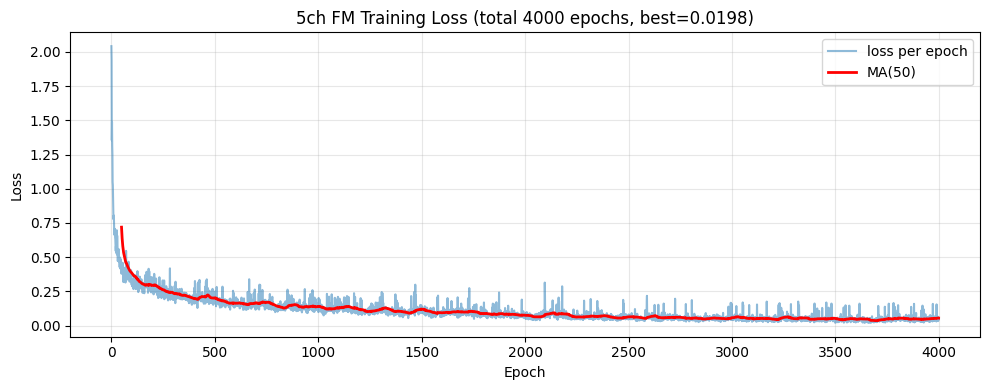

In [8]:
# ===============================================================
# 继续训练 model_5ch (Flow Matching 5-channel)
# ===============================================================
# 必须先运行 Cell 5 加载 model_5ch

import numpy as np
import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

torch.set_grad_enabled(True)  # 确保梯度开启

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']      # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']    # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")
print(f"[Data] states: {states.shape}, controls: {controls.shape}, goals: {goals.shape if goals is not None else None}")

# 构建 5-channel: [x, y, theta, a, delta_rate]
traj_5ch = np.stack([
    states[:, :, 0],       # x
    states[:, :, 1],       # y
    states[:, :, 2], 
    controls[:, :, 0],     # a
    controls[:, :, 1],     # delta_rate
], axis=1)  # (N, 5, T)

# Canonical frame: 每条轨迹以 start->goal 为 x 轴
def canonicalize_batch(trajs, goals_xy=None):
    """trajs: (N,5,T), goals_xy: (N,2) or None"""
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        # Rotate XY
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        # Rotate theta
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        # cond: [dist, v0, cos(th0_can), sin(th0_can), delta0]
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

X1_t = torch.tensor(X1, dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_all, dtype=torch.float32, device=device)

ds = TensorDataset(X1_t, cond_t)
dl = DataLoader(ds, batch_size=64, shuffle=True, drop_last=True)

# 测试 batch
for xb, cb in dl:
    print(f"[Batch] x: {xb.shape}, cond: {cb.shape}")
    break

# ---------------------------------------------------------------
# 2) 从头初始化模型 & optimizer (不加载 checkpoint)
# ---------------------------------------------------------------
# from fmtorch.models.simple1d_unet import SimpleUNet1D

import sys
from pathlib import Path

project_root = Path.cwd().parent.resolve()   # notebooks 的上一级 = dmpc_fm_cbf
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_canonical_r.pt")

# 重新初始化模型 (随机权重)
model_5ch = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_loss   = float('inf')
history     = []

print(f"[Model] 从头初始化 (随机权重)")
print(f"[Model] Parameters: {sum(p.numel() for p in model_5ch.parameters()):,}")

LR = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=1e-5)

print(f"[History] Previous epochs: {len(history)}")

# ---------------------------------------------------------------
# 3) Training loop
# ---------------------------------------------------------------
EPOCHS = 4000
SAVE_EVERY = 500

print(f"\n{'='*60}")
print(f"开始继续训练: {EPOCHS} epochs, LR={LR}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_loss = epoch_loss / max(n_batch, 1)
    history.append(avg_loss)
    global_step += 1

    if avg_loss < best_loss:
        best_loss = avg_loss

    if epoch % 50 == 0:
        print(f"  Epoch {epoch}/{EPOCHS} | loss={avg_loss:.6f} | best={best_loss:.6f} | step={global_step}")

    if epoch % SAVE_EVERY == 0:
        torch.save({
            'model_state_dict': model_5ch.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'global_step': global_step,
            'best_loss': best_loss,
            'history': history,
        }, str(ckpt_path))
        print(f"  💾 Saved checkpoint: step={global_step}, best_loss={best_loss:.6f}")

# Final save
torch.save({
    'model_state_dict': model_5ch.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'global_step': global_step,
    'best_loss': best_loss,
    'history': history,
}, str(ckpt_path))

print(f"\n✅ 训练完成! 总 epochs: {global_step}, best_loss: {best_loss:.6f}")

# ---------------------------------------------------------------
# 4) Plot training curve
# ---------------------------------------------------------------
model_5ch.eval()

plt.figure(figsize=(10, 4))
plt.plot(history, alpha=0.5, label='loss per epoch')
if len(history) > 20:
    window = min(50, len(history) // 5)
    smooth = np.convolve(np.array(history, dtype=np.float64), np.ones(window)/window, mode='valid')
    plt.plot(range(window-1, len(history)), smooth, 'r-', lw=2, label=f'MA({window})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'5ch FM Training Loss (total {global_step} epochs, best={best_loss:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[Data] N=100, T=60, D=5
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Split] Train: 80, Val: 20
[Model] Parameters: 2,904,965

Training: 4000 epochs, LR=0.0005
Train: 80, Val: 20

  Epoch    1 | train=2.369664 | val=1.781698 * (best)
  Epoch   50 | train=0.456482 | val=0.599788 * (best)
  Epoch  100 | train=0.293754 | val=0.420579 * (best)
  Epoch  150 | train=0.270199 | val=0.393799 * (best)
  Epoch  200 | train=0.230915 | val=0.389634 * (best)
  Epoch  250 | train=0.230300 | val=0.476563
  Epoch  300 | train=0.178178 | val=0.437105
  Epoch  350 | train=0.172068 | val=0.409355
  Epoch  400 | train=0.192252 | val=0.725121
  Epoch  450 | train=0.158732 | val=0.502803
  Epoch  500 | train=0.163946 | val=0.395053
  Epoch  550 | train=0.155929 | val=0.357813 * (best)
  Epoch  600 | train=0.125715 | val=0.366060
  Epoch  650 | train=0.146123 | val=0.360205
  Epoch  700 | train=0.115641 | val=0.412500
  Epoch  750 | train=0.117007 | val=0.509194
  Epoch  800 | train=0.133554 | val=0.330864 *

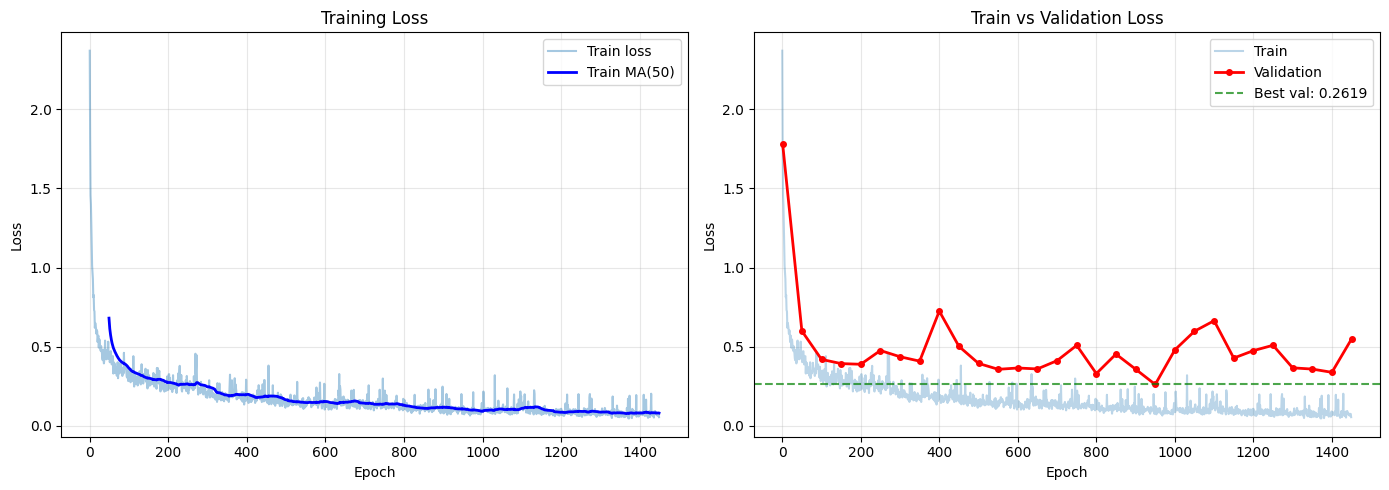


[Overfitting Check]
  Final train loss: 0.055821
  Final val loss:   0.548966
  Gap (val - train): 0.493146


In [ ]:
# ===============================================================
# 训练 model_5ch (Flow Matching 5-channel) - 带 Validation
# ===============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

torch.set_grad_enabled(True)

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

def canonicalize_batch(trajs, goals_xy=None):
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

X1_t = torch.tensor(X1, dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_all, dtype=torch.float32, device=device)

# ---------------------------------------------------------------
# 2) Train/Val Split (80/20)
# ---------------------------------------------------------------
full_ds = TensorDataset(X1_t, cond_t)

train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size], 
                                 generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 3) 模型初始化
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_canonical_val.pt")

model_5ch = SimpleUNet1D(
    time_emb_dim=128,
    hidden_dim=128,
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_val_loss = float('inf')
train_history = []
val_history = []

print(f"[Model] Parameters: {sum(p.numel() for p in model_5ch.parameters()):,}")

LR = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=1e-5)

# ---------------------------------------------------------------
# 4) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total_loss = 0.0
    n_batch = 0
    
    for x_1, cond_b in val_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        
        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)
        
        total_loss += loss.item()
        n_batch += 1
    
    model.train()
    return total_loss / max(n_batch, 1)

# ---------------------------------------------------------------
# 5) Training loop with validation
# ---------------------------------------------------------------
EPOCHS = 4000
SAVE_EVERY = 500
VAL_EVERY = 50
PATIENCE = 500

no_improve_count = 0

print(f"\n{'='*60}")
print(f"Training: {EPOCHS} epochs, LR={LR}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    # ----- Training -----
    model_5ch.train()
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in train_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_train_loss = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train_loss)
    global_step += 1

    # ----- Validation -----
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_5ch, val_dl)
        val_history.append((epoch, val_loss))
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict': model_5ch.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step': global_step,
                'best_val_loss': best_val_loss,
                'train_history': train_history,
                'val_history': val_history,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f} | val={val_loss:.6f} * (best)")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f} | val={val_loss:.6f}")
        
        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] epoch {epoch}, no improvement for {PATIENCE} epochs")
            break
    
    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train_loss:.6f}")

print(f"\nDone! Epochs: {global_step}, Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 6) Plot training curves
# ---------------------------------------------------------------
model_5ch.eval()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_history, alpha=0.4, label='Train loss')
if len(train_history) > 50:
    window = 50
    smooth = np.convolve(np.array(train_history), np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(train_history)), smooth, 'b-', lw=2, label=f'Train MA({window})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
val_epochs = [v[0] for v in val_history]
val_losses = [v[1] for v in val_history]
ax2.plot(train_history, alpha=0.3, label='Train')
ax2.plot(val_epochs, val_losses, 'ro-', lw=2, markersize=4, label='Validation')
ax2.axhline(best_val_loss, color='g', ls='--', alpha=0.7, label=f'Best val: {best_val_loss:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Train vs Validation Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 7) Overfitting check
# ---------------------------------------------------------------
if len(val_history) >= 2:
    final_train = train_history[-1]
    final_val = val_history[-1][1]
    gap = final_val - final_train
    
    print(f"\n[Overfitting Check]")
    print(f"  Final train loss: {final_train:.6f}")
    print(f"  Final val loss:   {final_val:.6f}")
    print(f"  Gap (val - train): {gap:.6f}")
    
    if gap > 0.01:
        print("  Warning: possible overfitting")
    else:
        print("  OK: no obvious overfitting")

[device] cuda
[Data] N=100, T=60, D=5
[Canonical] X1: (100, 5, 60), cond: (100, 5)
[Curvature Aug]
  Curvature bin [0.00, 0.25]: 50 samples → +0
  Curvature bin [0.25, 0.50]: 9 samples → +21
  Curvature bin [0.50, 0.75]: 15 samples → +15
  Curvature bin [0.75, 1.00]: 3 samples → +27
  Curvature bin [1.00, 1.26]: 0 samples → +30
  Curvature bin [1.26, 1.51]: 7 samples → +23
  Curvature bin [1.51, 1.76]: 8 samples → +22
  Curvature bin [1.76, 2.01]: 8 samples → +22
  After curvature aug: 230 samples

[Noise/Mirror Aug]
[Augmented] X1: (3450, 5, 60), cond: (3450, 5)
[Split] Train: 2760, Val: 690
[Model] Parameters: 731,589 (small model)
[Model] Data/Param ratio: 0.0038

Training: 3000 epochs, LR=0.0003, weight_decay=0.0005
Train: 2760, Val: 690
Input noise: 0.02, Patience: 300

  Epoch    1 | train=0.8556 | val=0.5361 | gap=-0.3195 * (best)
  Epoch   50 | train=0.1676 | val=0.1576 | gap=-0.0100 * (best)
  Epoch  100 | train=0.1374 | val=0.1100 | gap=-0.0274 * (best)
  Epoch  150 | train=0

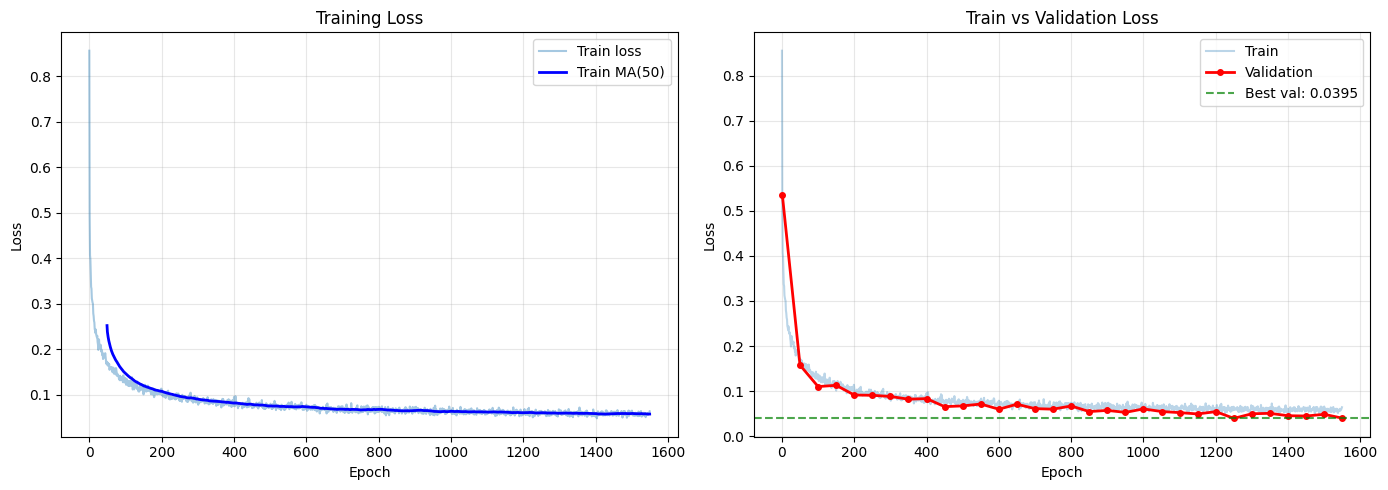


[Overfitting Check]
  Final train loss: 0.064112
  Final val loss:   0.039868
  Gap (val - train): -0.024244
  OK: no obvious overfitting

[Load Best] Loading from cache\model_vel_5ch_small.pt
[Load Best] Done, best_val_loss=0.039486


In [5]:
# ===============================================================
# 训练 model_5ch (Flow Matching 5-channel) - 小模型 + 抗过拟合
# ===============================================================

import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from pathlib import Path

# 确保 fmtorch 包可被导入
repo_root = str(Path(os.getcwd()).parent)  # notebooks/../ = dmpc_fm_cbf/
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

torch.set_grad_enabled(True)

# ---------------------------------------------------------------
# 1) 加载数据 & 规范化
# ---------------------------------------------------------------
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']
controls = raw['controls']
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1)

def canonicalize_batch(trajs, goals_xy=None):
    N2 = trajs.shape[0]
    out = trajs.copy()
    cond_list = []
    for i in range(N2):
        x0, y0 = trajs[i, 0, 0], trajs[i, 1, 0]
        if goals_xy is not None:
            gx, gy = goals_xy[i]
        else:
            gx, gy = trajs[i, 0, -1], trajs[i, 1, -1]
        dx, dy = gx - x0, gy - y0
        dist = float(np.sqrt(dx**2 + dy**2) + 1e-9)
        cos_a, sin_a = dx / dist, dy / dist
        rx = cos_a * (trajs[i, 0] - x0) + sin_a * (trajs[i, 1] - y0)
        ry = -sin_a * (trajs[i, 0] - x0) + cos_a * (trajs[i, 1] - y0)
        out[i, 0] = rx
        out[i, 1] = ry
        angle_off = float(np.arctan2(sin_a, cos_a))
        out[i, 2] = np.array([float((th - angle_off + np.pi) % (2*np.pi) - np.pi) for th in trajs[i, 2]])
        th0_can = float((trajs[i, 2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
        cond_list.append([dist, float(states[i, 0, 3]),
                          float(np.cos(th0_can)), float(np.sin(th0_can)),
                          float(states[i, 0, 4])])
    return out, np.array(cond_list, dtype=np.float32)

X1, cond_all = canonicalize_batch(traj_5ch, goals)
print(f"[Canonical] X1: {X1.shape}, cond: {cond_all.shape}")

# ---------------------------------------------------------------
# 2) 数据增强 (解决数据量不足)
# ---------------------------------------------------------------
def augment_data(X1, cond_all, aug_factor=10):
    N, C, T = X1.shape
    augmented_X = [X1]
    augmented_cond = [cond_all]
    
    np.random.seed(42)
    
    for i in range(aug_factor - 1):
        # 添加小噪声
        noise_X = X1.copy()
        noise_X[:, 0:2, :] += np.random.randn(N, 2, T) * 0.02
        noise_X[:, 2, :] += np.random.randn(N, T) * 0.03
        noise_X[:, 3:5, :] += np.random.randn(N, 2, T) * 0.01
        
        noise_cond = cond_all.copy()
        noise_cond[:, 0] *= (1 + np.random.randn(N) * 0.02)
        noise_cond[:, 1] += np.random.randn(N) * 0.02
        
        augmented_X.append(noise_X)
        augmented_cond.append(noise_cond)
        
        # Y轴镜像 (每隔一次)
        if i % 2 == 0:
            mirror_X = X1.copy()
            mirror_X[:, 1, :] *= -1
            mirror_X[:, 2, :] *= -1
            mirror_X[:, 1, :] += np.random.randn(N, T) * 0.01
            
            mirror_cond = cond_all.copy()
            mirror_cond[:, 3] *= -1
            
            augmented_X.append(mirror_X)
            augmented_cond.append(mirror_cond)
    
    return (np.concatenate(augmented_X, axis=0).astype(np.float32),
            np.concatenate(augmented_cond, axis=0).astype(np.float32))
    
def augment_by_curvature(X1, cond_all, target_per_bin=30, n_bins=8):
    """对高曲率稀疏区间做插值过采样"""
    max_ys = np.max(np.abs(X1[:, 1, :]), axis=1)  # (N,) 每条轨迹的 max|y|
    bins = np.linspace(0, max_ys.max() + 0.01, n_bins + 1)

    aug_X    = [X1]
    aug_cond = [cond_all]
    np.random.seed(99)

    for b in range(n_bins):
        mask    = (max_ys >= bins[b]) & (max_ys < bins[b+1])
        indices = np.where(mask)[0]
        count   = len(indices)
        needed  = max(0, target_per_bin - count)

        print(f"  Curvature bin [{bins[b]:.2f}, {bins[b+1]:.2f}]: "
              f"{count} samples → +{needed}")

        if count == 0 or needed == 0:
            continue

        for _ in range(needed):
            i1, i2 = np.random.choice(indices, 2, replace=(count < 2))
            alpha  = np.random.uniform(0.3, 0.7)

            new_X    = alpha * X1[i1] + (1 - alpha) * X1[i2]
            new_X    += np.random.randn(*new_X.shape).astype(np.float32) * 0.005
            new_cond = alpha * cond_all[i1] + (1 - alpha) * cond_all[i2]

            aug_X.append(new_X[None])       # (1, 5, T)
            aug_cond.append(new_cond[None]) # (1, 5)

    return (np.concatenate(aug_X,    axis=0).astype(np.float32),
            np.concatenate(aug_cond, axis=0).astype(np.float32))

# === 执行顺序：先曲率均衡，再做原有增强 ===
print("[Curvature Aug]")
X1_balanced, cond_balanced = augment_by_curvature(X1, cond_all,
                                                    target_per_bin=30, n_bins=8)
print(f"  After curvature aug: {len(X1_balanced)} samples")

print("\n[Noise/Mirror Aug]")
X1_aug, cond_aug = augment_data(X1_balanced, cond_balanced, aug_factor=10)
print(f"[Augmented] X1: {X1_aug.shape}, cond: {cond_aug.shape}")   


X1_t   = torch.tensor(X1_aug,  dtype=torch.float32, device=device)
cond_t = torch.tensor(cond_aug, dtype=torch.float32, device=device)




# ---------------------------------------------------------------
# 3) Train/Val Split (80/20)
# ---------------------------------------------------------------
full_ds = TensorDataset(X1_t, cond_t)

train_size = int(0.8 * len(full_ds))
val_size = len(full_ds) - train_size

train_ds, val_ds = random_split(full_ds, [train_size, val_size], 
                                 generator=torch.Generator().manual_seed(42))

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

print(f"[Split] Train: {len(train_ds)}, Val: {len(val_ds)}")

# ---------------------------------------------------------------
# 4) 小模型初始化 (防止过拟合)
# ---------------------------------------------------------------
from fmtorch.models.simple1d_unet import SimpleUNet1D

ckpt_path = Path("cache/model_vel_5ch_small.pt")

# 小模型: hidden_dim 128 -> 64
model_5ch = SimpleUNet1D(
    time_emb_dim=64,    # 128 -> 64
    hidden_dim=64,      # 128 -> 64
    cond_dim=5,
    in_channels=5,
    out_channels=5,
).to(device)

model_5ch.train()
global_step = 0
best_val_loss = float('inf')
train_history = []
val_history = []

n_params = sum(p.numel() for p in model_5ch.parameters())
print(f"[Model] Parameters: {n_params:,} (small model)")
print(f"[Model] Data/Param ratio: {len(train_ds) / n_params:.4f}")

# 强正则化
LR = 3e-4
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 1.0
optimizer = torch.optim.AdamW(model_5ch.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# ---------------------------------------------------------------
# 5) Validation 函数
# ---------------------------------------------------------------
@torch.no_grad()
def validate(model, val_dl):
    model.eval()
    total_loss = 0.0
    n_batch = 0
    
    for x_1, cond_b in val_dl:
        B = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)
        
        x_t = (1 - t_exp) * x_0 + t_exp * x_1
        v_target = x_1 - x_0
        v_pred = model(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)
        
        total_loss += loss.item()
        n_batch += 1
    
    model.train()
    return total_loss / max(n_batch, 1)

# ---------------------------------------------------------------
# 6) Training loop
# ---------------------------------------------------------------
EPOCHS = 3000
VAL_EVERY = 50
PATIENCE = 300
INPUT_NOISE = 0.02

no_improve_count = 0

print(f"\n{'='*60}")
print(f"Training: {EPOCHS} epochs, LR={LR}, weight_decay={WEIGHT_DECAY}")
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}")
print(f"Input noise: {INPUT_NOISE}, Patience: {PATIENCE}")
print(f"{'='*60}\n")

for epoch in range(1, EPOCHS + 1):
    model_5ch.train()
    epoch_loss = 0.0
    n_batch = 0

    for x_1, cond_b in train_dl:
        B = x_1.shape[0]
        
        # 训练时添加输入噪声 (额外正则化)
        x_1_noisy = x_1 + torch.randn_like(x_1) * INPUT_NOISE
        
        x_0 = torch.randn_like(x_1)
        t = torch.rand(B, device=device)
        t_exp = t.view(B, 1, 1)

        x_t = (1 - t_exp) * x_0 + t_exp * x_1_noisy
        v_target = x_1_noisy - x_0
        v_pred = model_5ch(x_t, t, cond=cond_b)
        loss = F.mse_loss(v_pred, v_target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_5ch.parameters(), GRAD_CLIP)
        optimizer.step()

        epoch_loss += loss.item()
        n_batch += 1

    avg_train_loss = epoch_loss / max(n_batch, 1)
    train_history.append(avg_train_loss)
    global_step += 1

    # Validation
    if epoch % VAL_EVERY == 0 or epoch == 1:
        val_loss = validate(model_5ch, val_dl)
        val_history.append((epoch, val_loss))
        
        gap = val_loss - avg_train_loss
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            torch.save({
                'model_state_dict': model_5ch.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'global_step': global_step,
                'best_val_loss': best_val_loss,
                'train_history': train_history,
                'val_history': val_history,
            }, str(ckpt_path))
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f} | val={val_loss:.4f} | gap={gap:.4f} * (best)")
        else:
            no_improve_count += VAL_EVERY
            print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f} | val={val_loss:.4f} | gap={gap:.4f}")
        
        if no_improve_count >= PATIENCE:
            print(f"\n[Early Stop] epoch {epoch}, no improvement for {PATIENCE} epochs")
            break
    
    elif epoch % 100 == 0:
        print(f"  Epoch {epoch:4d} | train={avg_train_loss:.4f}")

print(f"\nDone! Epochs: {global_step}, Best val loss: {best_val_loss:.6f}")

# ---------------------------------------------------------------
# 7) Plot training curves
# ---------------------------------------------------------------
model_5ch.eval()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(train_history, alpha=0.4, label='Train loss')
if len(train_history) > 50:
    window = 50
    smooth = np.convolve(np.array(train_history), np.ones(window)/window, mode='valid')
    ax1.plot(range(window-1, len(train_history)), smooth, 'b-', lw=2, label=f'Train MA({window})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
val_epochs = [v[0] for v in val_history]
val_losses = [v[1] for v in val_history]
ax2.plot(train_history, alpha=0.3, label='Train')
ax2.plot(val_epochs, val_losses, 'ro-', lw=2, markersize=4, label='Validation')
ax2.axhline(best_val_loss, color='g', ls='--', alpha=0.7, label=f'Best val: {best_val_loss:.4f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Train vs Validation Loss')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 8) Overfitting check
# ---------------------------------------------------------------
if len(val_history) >= 2:
    final_train = train_history[-1]
    final_val = val_history[-1][1]
    gap = final_val - final_train
    
    print(f"\n[Overfitting Check]")
    print(f"  Final train loss: {final_train:.6f}")
    print(f"  Final val loss:   {final_val:.6f}")
    print(f"  Gap (val - train): {gap:.6f}")
    
    if gap > 0.05:
        print("  Warning: still overfitting, consider more data or smaller model")
    elif gap > 0.02:
        print("  Mild overfitting, but acceptable")
    else:
        print("  OK: no obvious overfitting")

# ---------------------------------------------------------------
# 9) 加载最佳模型用于后续使用
# ---------------------------------------------------------------
print(f"\n[Load Best] Loading from {ckpt_path}")
ckpt = torch.load(str(ckpt_path), map_location=device)
model_5ch.load_state_dict(ckpt['model_state_dict'])
model_5ch.eval()
print(f"[Load Best] Done, best_val_loss={ckpt['best_val_loss']:.6f}")

In [2]:
# ===============================================================
# FINAL CELL (SMOOTH) — GPU-friendly version
# Warm-start DMPC (K=1)
# FM ODE with CBF INSIDE (first-step only)
# + EMA smoothing
# + Goal-pull (soft heading correction)
#
# Key speed fix:
#   ✅ remove CPU<->GPU ping-pong inside ODE rhs
#   ✅ canonicalize/uncanonicalize in TORCH (on device)
#   ✅ pre-create tensors used by CBF (no torch.tensor(...) in rhs)
# ===============================================================

import sys
from pathlib import Path

sys.path.insert(0, "..")

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------------------------------------------------------
# Preconditions
# ---------------------------------------------------------------
# NOTE: this notebook runs in a separate kernel from demo.ipynb.
# If you trained in demo, save/load the checkpoint here.
MODEL_CKPT = "cache/model_vel.pt"  # change if you saved elsewhere

# Try a few common locations
ckpt_candidates = [
    Path(MODEL_CKPT),
    Path("..") / "cache" / "model_vel.pt",
    Path.cwd() / "cache" / "model_vel.pt",
    Path.cwd().parent / "cache" / "model_vel.pt",
]
ckpt_path = next((p for p in ckpt_candidates if p.exists()), None)

if "model_vel" not in globals():
    if "trainer" in globals():
        model_vel = trainer.model
    else:
        if ckpt_path is not None:
            from fmtorch.models.simple1d_unet import SimpleUNet1D
            ckpt = torch.load(str(ckpt_path), map_location=device)
            model_vel = SimpleUNet1D(time_emb_dim=128, hidden_dim=128, cond_dim=5).to(device)
            model_vel.load_state_dict(ckpt["model_state_dict"])
            print("Loaded model checkpoint:", ckpt_path)
        else:
            raise RuntimeError(
                "model_vel not found. Train in this notebook or set MODEL_CKPT to a saved model."
            )
if "cbf_project_velocity_world" not in globals():
    import importlib.util
    cbf_path = Path.cwd().parent / "dmpc_fm_cbf" / "cbf.py"
    if cbf_path.exists():
        spec = importlib.util.spec_from_file_location("dmpc_fm_cbf.cbf", str(cbf_path))
        cbf_mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(cbf_mod)
        cbf_project_velocity_world = cbf_mod.cbf_project_velocity_world
    else:
        raise RuntimeError(f"cbf.py not found at {cbf_path}")

model_vel = model_vel.to(device).eval()

Loaded model checkpoint: cache\model_vel.pt


In [1]:
import sys, importlib.util
from pathlib import Path

def find_file_upwards(filename: str, start: Path, max_up: int = 12):
    """
    Search 'filename' by walking upwards; at each level, also try a few common subpaths.
    Returns Path or None.
    """
    p = start.resolve()

    common_subs = [
        Path("."),  # current
        Path("dmpc_fm_cbf"),
        Path("dmpc_fm_cbf") / "dmpc_fm_cbf",
        Path("src"),
        Path("src") / "dmpc_fm_cbf",
    ]

    for _ in range(max_up):
        # quick checks on common layouts
        for sub in common_subs:
            cand = (p / sub / filename).resolve()
            if cand.exists():
                return cand

        # fallback: shallow recursive search (limited)
        try:
            hits = list(p.rglob(filename))
            if len(hits) > 0:
                # prefer the one inside ".../dmpc_fm_cbf/..." if multiple
                hits_sorted = sorted(hits, key=lambda x: ("dmpc_fm_cbf" not in str(x), len(str(x))))
                return hits_sorted[0].resolve()
        except Exception:
            pass

        p = p.parent

    return None

def load_module_from_abs_path(mod_name: str, abs_path: Path):
    abs_path = abs_path.resolve()
    assert abs_path.exists(), f"Missing file: {abs_path}"
    spec = importlib.util.spec_from_file_location(mod_name, str(abs_path))
    mod = importlib.util.module_from_spec(spec)
    sys.modules[mod_name] = mod
    spec.loader.exec_module(mod)  # type: ignore
    return mod

# ---- locate files robustly ----
here = Path.cwd()
sampler_path = find_file_upwards("sampler_5h.py", here)
cbf_path     = find_file_upwards("cbf_project_velocity_sgfm.py", here)

print("[cwd]", here.resolve())
print("[sampler_path]", sampler_path)
print("[cbf_path    ]", cbf_path)

assert sampler_path is not None, "Cannot find sampler_5h.py from current notebook location."
assert cbf_path is not None, "Cannot find cbf_project_velocity_sgfm.py from current notebook location."

sampler_mod = load_module_from_abs_path("sampler_5h_abs", sampler_path)
cbf_mod     = load_module_from_abs_path("cbf_sgfm_abs",  cbf_path)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf

print("[USING sampler]", sampler_mod.__file__)
print("[USING cbf    ]", cbf_mod.__file__)


[cwd] E:\projects\lab2025\dmpc_fm_cbf\notebooks
[sampler_path] E:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[cbf_path    ] E:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py
[USING sampler] E:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[USING cbf    ] E:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\cbf_project_velocity_sgfm.py


In [2]:
import importlib.util, sys

spec = importlib.util.spec_from_file_location(
    "sampler_5h",
    r"E:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py"
)
sampler_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
print("✅ 直接加载成功:", sampler_mod.__file__)

✅ 直接加载成功: E:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py


In [5]:
# ===============================================================
# 1) Load model_5ch automatically (5-channel FM model)
# ===============================================================

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if "model_5ch" not in globals():

    # ★ 优先加载 small 模型，找不到再 fallback 到其他版本
    preferred = list(Path.cwd().rglob("model_vel_5ch_small.pt"))
    fallback  = [p for p in Path.cwd().rglob("model_vel_5ch*.pt")
                 if "small" not in p.name]

    if preferred:
        ckpt_path  = preferred[0]
        hidden_dim = 64
        time_emb   = 64
    elif fallback:
        ckpt_path  = fallback[0]
        hidden_dim = 128
        time_emb   = 128
    else:
        raise RuntimeError("Cannot find 5ch checkpoint (model_vel_5ch*.pt)")

    print("[Found checkpoint]", ckpt_path)
    print(f"[Model config]  hidden_dim={hidden_dim}, time_emb_dim={time_emb}")

    # ensure repo root in sys.path
    # repo_root = sampler_path.parents[2]
    # if str(repo_root) not in sys.path:
    #     sys.path.insert(0, str(repo_root))
    import sys
    from pathlib import Path

    repo_root = Path.cwd().parent
    if str(repo_root) not in sys.path:

        sys.path.insert(0, str(repo_root))

    from fmtorch.models.simple1d_unet import SimpleUNet1D

    model_5ch = SimpleUNet1D(
        time_emb_dim=time_emb,
        hidden_dim=hidden_dim,
        cond_dim=5,
        in_channels=5,
        out_channels=5,
    ).to(device)

    ckpt = torch.load(str(ckpt_path), map_location=device)

    if "model_state_dict" in ckpt:
        model_5ch.load_state_dict(ckpt["model_state_dict"])
        if "best_val_loss" in ckpt:
            print(f"[Best val loss] {ckpt['best_val_loss']:.6f}")
    else:
        model_5ch.load_state_dict(ckpt)

    model_5ch.eval()
    print(f"[Params] {sum(p.numel() for p in model_5ch.parameters()):,}")
    print("✅ model_5ch loaded successfully.")

[Found checkpoint] e:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\model_vel_5ch_small.pt
[Model config]  hidden_dim=64, time_emb_dim=64
[Best val loss] 0.039486
[Params] 731,589
✅ model_5ch loaded successfully.


[cond] dist=3.000  v0=0.270  cos_th=0.528  sin_th=-0.849  delta0=0.000
[shapes] x1=(200, 5, 60)  x0=(200, 5, 60)  cond=(200, 5)
[Assert] 全部一致 ✓

    t    ‖v‖ mean       std        XY         θ      ctrl    target
-----------------------------------------------------------------
  0.00    1.225585  0.000000    1.2903    1.2529    1.1425    1.2269
  0.05    1.228286  0.000000    1.2910    1.2589    1.1457    1.2269
  0.11    1.230482  0.000000    1.2912    1.2639    1.1486    1.2269
  0.16    1.232096  0.000000    1.2910    1.2677    1.1510    1.2269
  0.21    1.233177  0.000000    1.2906    1.2702    1.1530    1.2269
  0.26    1.233806  0.000000    1.2901    1.2717    1.1545    1.2269
  0.32    1.234110  0.000000    1.2897    1.2721    1.1556    1.2269
  0.37    1.234264  0.000000    1.2896    1.2718    1.1562    1.2269
  0.42    1.234330  0.000000    1.2899    1.2712    1.1564    1.2269
  0.47    1.234304  0.000000    1.2905    1.2702    1.1561    1.2269
  0.53    1.234011  0.000000   

C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 24212 (\N{CJK UNIFIED IDEOGRAPH-5E94}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 35813 (\N{CJK UNIFIED IDEOGRAPH-8BE5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 21333 (\N{CJK UNIFIED IDEOGRAPH-5355}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ROG\AppData\Local\Temp\ipykernel_26112\1370425286.py:131: UserWarning: Glyph 26497 (\N{CJK 

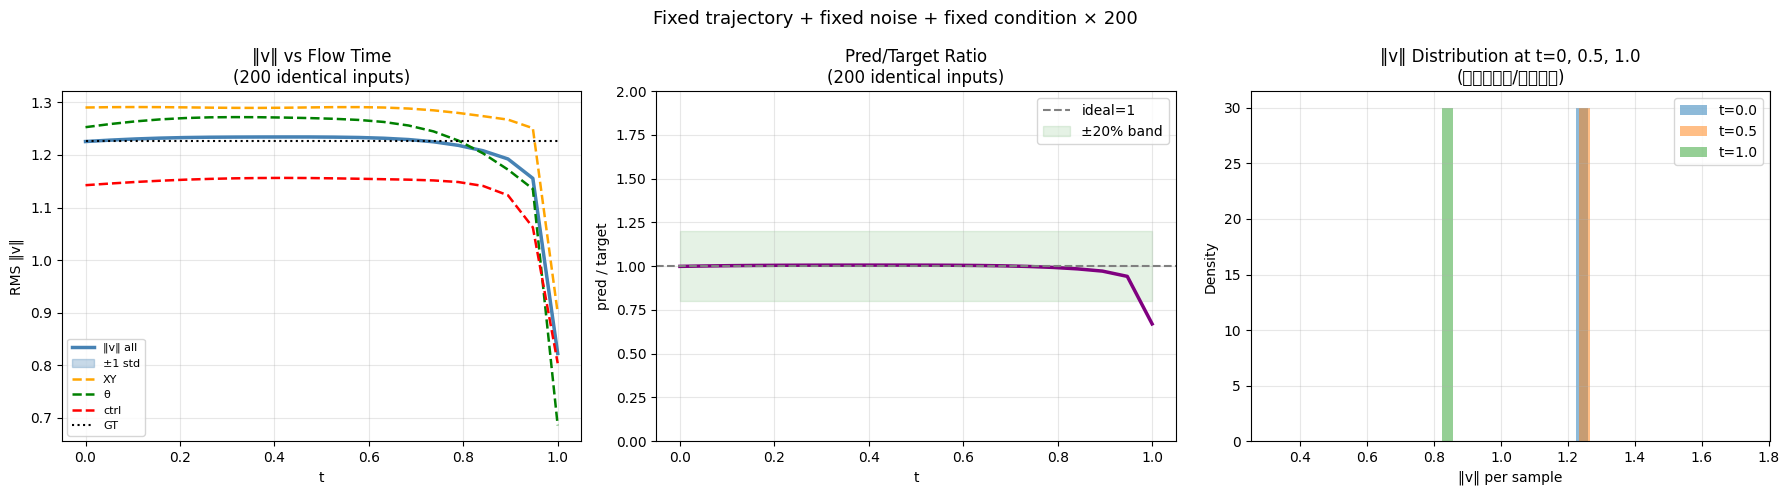

In [41]:
# ===============================================================
# 速度场 v 的模长分析 - 固定轨迹 + 固定noise + 固定condition
# 200条完全一样的输入，验证模型输出是否一致
# ===============================================================

model_5ch.eval()
torch.set_grad_enabled(False)

from torch.utils.data import DataLoader, TensorDataset, random_split

# ---------------------------------------------------------------
# 0) 确保 val_dl 存在
# ---------------------------------------------------------------
if 'val_dl' not in dir():
    print("[Rebuild] rebuilding val_dl ...")
    full_ds    = TensorDataset(X1_t, cond_t)
    train_size = int(0.8 * len(full_ds))
    val_size   = len(full_ds) - train_size
    _, val_ds  = random_split(full_ds, [train_size, val_size],
                               generator=torch.Generator().manual_seed(42))
    val_dl     = DataLoader(val_ds, batch_size=64, shuffle=False, drop_last=False)

# ---------------------------------------------------------------
# 1) 取第一条，三样东西全部复制200份且完全一样
# ---------------------------------------------------------------
N_SAMPLES  = 200
N_T_POINTS = 20
t_grid     = np.linspace(0.0, 1.0, N_T_POINTS)

x1_single, cond_single = next(iter(val_dl))

# 轨迹：复制200份
x1_rep = x1_single[0:1].repeat(N_SAMPLES, 1, 1)   # (200, 5, T)

# noise：固定seed，复制200份
torch.manual_seed(42)
x_0 = torch.randn(1, x1_rep.shape[1], x1_rep.shape[2],
                   device=x1_rep.device).repeat(N_SAMPLES, 1, 1)  # (200, 5, T)

# condition：同一个，复制200份
cond_ref = cond_single[0:1].repeat(N_SAMPLES, 1)   # (200, 5)

print(f"[cond] dist={cond_ref[0,0]:.3f}  v0={cond_ref[0,1]:.3f}  "
      f"cos_th={cond_ref[0,2]:.3f}  sin_th={cond_ref[0,3]:.3f}  delta0={cond_ref[0,4]:.3f}")
print(f"[shapes] x1={tuple(x1_rep.shape)}  x0={tuple(x_0.shape)}  cond={tuple(cond_ref.shape)}")

# 验证三者完全一致
assert torch.all(x1_rep[0] == x1_rep[99]).item(),   "x1_rep 不一致！"
assert torch.all(x_0[0]    == x_0[99]   ).item(),   "x_0 不一致！"
assert torch.all(cond_ref[0] == cond_ref[99]).item(),"cond 不一致！"
print("[Assert] 全部一致 ✓")

# ---------------------------------------------------------------
# 2) 计算每个 t 上的 vnorm
# ---------------------------------------------------------------
all_vnorms = np.zeros((N_SAMPLES, N_T_POINTS))
all_vxy    = np.zeros_like(all_vnorms)
all_vth    = np.zeros_like(all_vnorms)
all_vctrl  = np.zeros_like(all_vnorms)

v_target_np  = (x1_rep - x_0).cpu().numpy()
target_vnorm = np.full(N_T_POINTS, float(np.sqrt(np.mean(v_target_np[0] ** 2))))

for j, t_val in enumerate(t_grid):
    t_tensor = torch.full((N_SAMPLES,), t_val, device=x1_rep.device)
    t_exp    = t_tensor.view(-1, 1, 1)
    x_t      = (1 - t_exp) * x_0 + t_exp * x1_rep

    v_pred          = model_5ch(x_t, t_tensor, cond=cond_ref)
    v_np            = v_pred.cpu().numpy()
    all_vnorms[:, j]= np.sqrt(np.mean(v_np ** 2,             axis=(1, 2)))
    all_vxy[:, j]   = np.sqrt(np.mean(v_np[:, 0:2, :] ** 2, axis=(1, 2)))
    all_vth[:, j]   = np.sqrt(np.mean(v_np[:, 2:3, :] ** 2, axis=(1, 2)))
    all_vctrl[:, j] = np.sqrt(np.mean(v_np[:, 3:5, :] ** 2, axis=(1, 2)))

vnorm_mean = all_vnorms.mean(axis=0)
vnorm_std  = all_vnorms.std(axis=0)

# ---------------------------------------------------------------
# 3) 打印 - 如果模型确定性，std 应该全为 0
# ---------------------------------------------------------------
print(f"\n{'='*65}")
print(f"{'t':>5}  {'‖v‖ mean':>10}  {'std':>8}  {'XY':>8}  {'θ':>8}  {'ctrl':>8}  {'target':>8}")
print(f"{'-'*65}")
for j, t_val in enumerate(t_grid):
    print(f"  {t_val:.2f}  {vnorm_mean[j]:>10.6f}  {vnorm_std[j]:>8.6f}"
          f"  {all_vxy[:,j].mean():>8.4f}  {all_vth[:,j].mean():>8.4f}"
          f"  {all_vctrl[:,j].mean():>8.4f}  {target_vnorm[j]:>8.4f}")
print(f"{'='*65}")
print(f"\n[Summary]")
print(f"  max std across all t : {vnorm_std.max():.8f}")
print(f"  → 如果接近 0，模型是确定性的；如果 > 0，模型有随机性")

# ---------------------------------------------------------------
# 4) 可视化（原始格式：3列）
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 图1：各通道模长随 t
ax = axes[0]
ax.plot(t_grid, vnorm_mean, lw=2.5, label="‖v‖ all", color="steelblue")
ax.fill_between(t_grid, vnorm_mean - vnorm_std, vnorm_mean + vnorm_std,
                alpha=0.3, color="steelblue", label="±1 std")
ax.plot(t_grid, all_vxy.mean(axis=0),   lw=1.8, ls="--", label="XY",   color="orange")
ax.plot(t_grid, all_vth.mean(axis=0),   lw=1.8, ls="--", label="θ",    color="green")
ax.plot(t_grid, all_vctrl.mean(axis=0), lw=1.8, ls="--", label="ctrl", color="red")
ax.plot(t_grid, target_vnorm,           lw=1.5, ls=":",  label="GT",   color="black")
ax.set_xlabel("t"); ax.set_ylabel("RMS ‖v‖")
ax.set_title("‖v‖ vs Flow Time\n(200 identical inputs)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 图2：pred/target ratio
ax2 = axes[1]
ratio = vnorm_mean / (target_vnorm + 1e-9)
ax2.plot(t_grid, ratio, lw=2.5, color="purple")
ax2.axhline(1.0, ls="--", color="gray", label="ideal=1")
ax2.fill_between(t_grid, 0.8, 1.2, alpha=0.1, color="green", label="±20% band")
ax2.set_xlabel("t"); ax2.set_ylabel("pred / target")
ax2.set_title("Pred/Target Ratio\n(200 identical inputs)")
ax2.set_ylim(0, 2.0); ax2.legend(); ax2.grid(alpha=0.3)

# 图3：t=0 / t=0.5 / t=1.0 分布直方图
ax3 = axes[2]
for t_idx, lbl in [(0, "t=0.0"), (N_T_POINTS//2, "t=0.5"), (-1, "t=1.0")]:
    ax3.hist(all_vnorms[:, t_idx], bins=30, alpha=0.5, label=lbl, density=True)
ax3.set_xlabel("‖v‖ per sample"); ax3.set_ylabel("Density")
ax3.set_title("‖v‖ Distribution at t=0, 0.5, 1.0\n(应该是单点/极窄分布)")
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle("Fixed trajectory + fixed noise + fixed condition × 200", fontsize=13)
plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0: 'float' = 0.5, tau1: 'float' = 0.9, prox_k: 'float' = 3.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - Pure Pursuit 修复版（正确到达终点）
goal_tol=0.2  ARRIVAL_DIST=0.15  APPROACH_DIST=0.6
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15
[  2] dA=3.349 dB=3.349 dist=2.336 vA=0.30 vB=0.30
[  3] dA=3.304 dB=

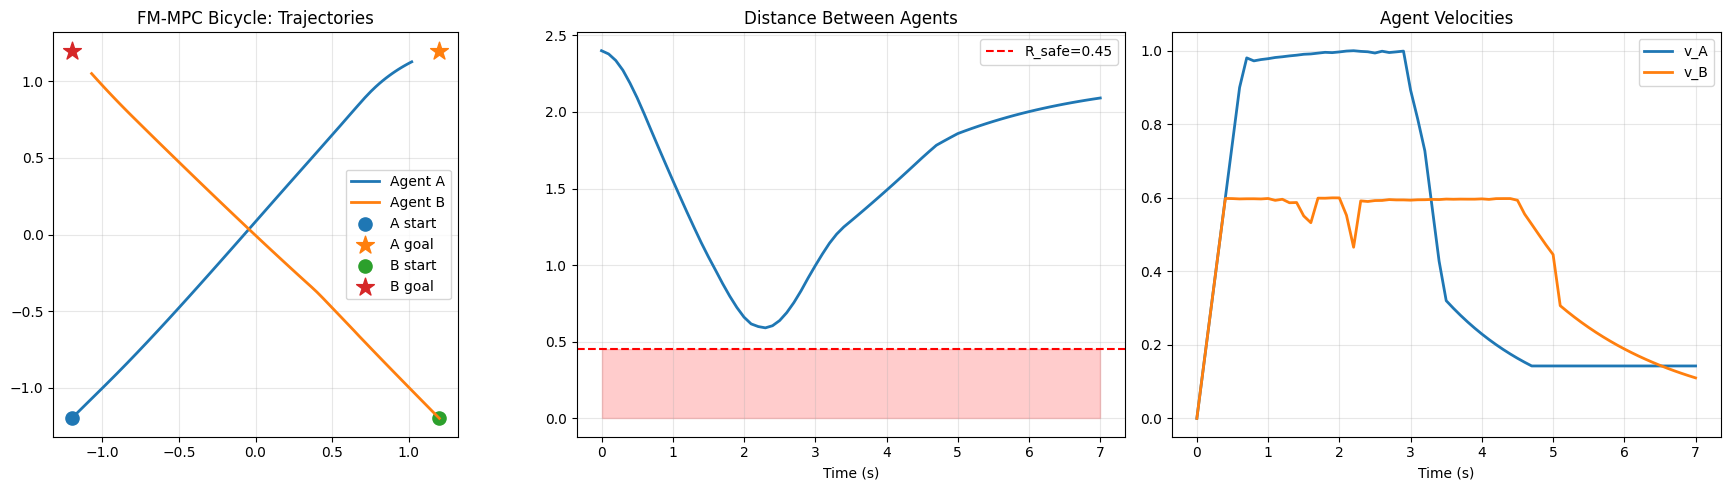

In [ ]:
# ============================================================
# FM-MPC Bicycle - 修复版：Pure Pursuit 正确到达终点
# 修改点：
#   1. Ld = min(Ld, d_goal * 0.85)  → 消除绕圈根源
#   2. d_goal < APPROACH_DIST 时 target 直接指向 goal
#   3. ARRIVAL_DIST 改小，消除停车死锁
#   4. done 判定去掉速度条件
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 5
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping  ★ 全部修改
goal_tol      = 0.20   # 原 0.35
ARRIVAL_DIST  = 0.15   # ★ 新增：真正刹车距离
APPROACH_DIST = 0.60   # ★ 新增：进入直接指向goal模式的距离
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# ===============================================================
# 3) Bicycle dynamics  （不变）
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor # 防止速度过低 给最小起步速度
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    # 初始化st，Hh+1行5列，用于存储状态
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st
    #用bicycle_step函数，根据当前状态s0和控制u，计算下一个状态st[i+1]

# ===============================================================
# 4) Canonical frame  （不变）
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings  （不变）
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction  （不变）
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st
    # 用rollout_bicycle函数，根据other_state和other_u_last，计算other_state的预测轨迹pos和状态st constant control prediction

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    #tf：canonical frame
    #other_pred_pos：other_state的预测轨迹
    #dist_AB：other_state和self_state的距离
    # 用build_time_expanded_ellipses函数，根据tf、other_pred_pos和dist_AB，计算other_pred_pos的预测轨迹的椭圆
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    #idxs：other_pred_pos的预测轨迹的椭圆的索引 减少计算量
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    # 用r_obs_near if dist_AB < 1.2 else r_obs_far计算椭圆的半径
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling  （不变）
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []
    x0_noise = make_x0_noise(T_steps, seed)
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)
    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec, start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.45, goal_guidance_weight=0.90,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None, ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )
    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# 8) Pure Pursuit — ★ 修复版（框架不变，三处关键修改）
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))
    # 找“离我最近的轨迹点索引” 

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    Ld_min  = 0.20
    Ld_max  = 1.10
    k_brake = 5.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        # ★ 修改1：真正很近才停车，消除死锁
        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        # ★ 修改2：接近终点时 target 直接指向 goal（纯 Pure Pursuit，只换目标点）
        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            # 正常 Pure Pursuit
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            # ★ 修改3：Ld 不超过 d_goal * 0.85，防止 lookahead 越过终点绕圈
            Ld = min(Ld, d_goal * 0.85)

            near_idx = _closest_index(path_xy, pos)
            near_idx = max(near_idx, last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)

            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        # 转向（与原版完全相同）
        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))

        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target  # 曲率
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max)) # 期望转向角
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))

        turn_pen = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des   *= turn_pen

        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost  （不变）
# ===============================================================
W_END    = 18.0
W_PATH   = 1.5
W_COLL   = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0]**2 + 0.4*dU[:, 1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan  （不变）
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)
    best      = None
    cbf_count = 0
    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy,
                other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue
        cbf_count += int(used_cbf)
        U        = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J        = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0       = U[0].copy()
        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)
    if best is None:
        return np.zeros(2, np.float32), float("inf"), None, 0
    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup  （不变）
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0]))
thB0 = float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - Pure Pursuit 修复版（正确到达终点）")
print(f"goal_tol={goal_tol}  ARRIVAL_DIST={ARRIVAL_DIST}  APPROACH_DIST={APPROACH_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))

    # ★ done 判定：只看位置，不要求速度
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)
        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)
        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots  （不变）
# ===============================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[依赖检查] ✓
[Data] N=100  T=60  D=5
[Params] T_steps=40  num_segments=5  total_time=1.0  ode_method=euler
[注意] T_steps(40) != 数据T(60)，pred 会插值对齐

验证中... (N=50 samples)
  [10/50]  ADE=0.1993  FDE=0.2708  HDG=6.60°
  [20/50]  ADE=0.1888  FDE=0.2709  HDG=5.73°
  [30/50]  ADE=0.2205  FDE=0.2641  HDG=6.95°
  [40/50]  ADE=0.2386  FDE=0.2509  HDG=7.80°
  [50/50]  ADE=0.2352  FDE=0.2292  HDG=7.49°

  ADE  : 0.2352  ±0.2218
  FDE  : 0.2292  ±0.1838
  HDG  : 7.49°  ±11.73°

判断标准（canonical frame）：
  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题
  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题
  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题


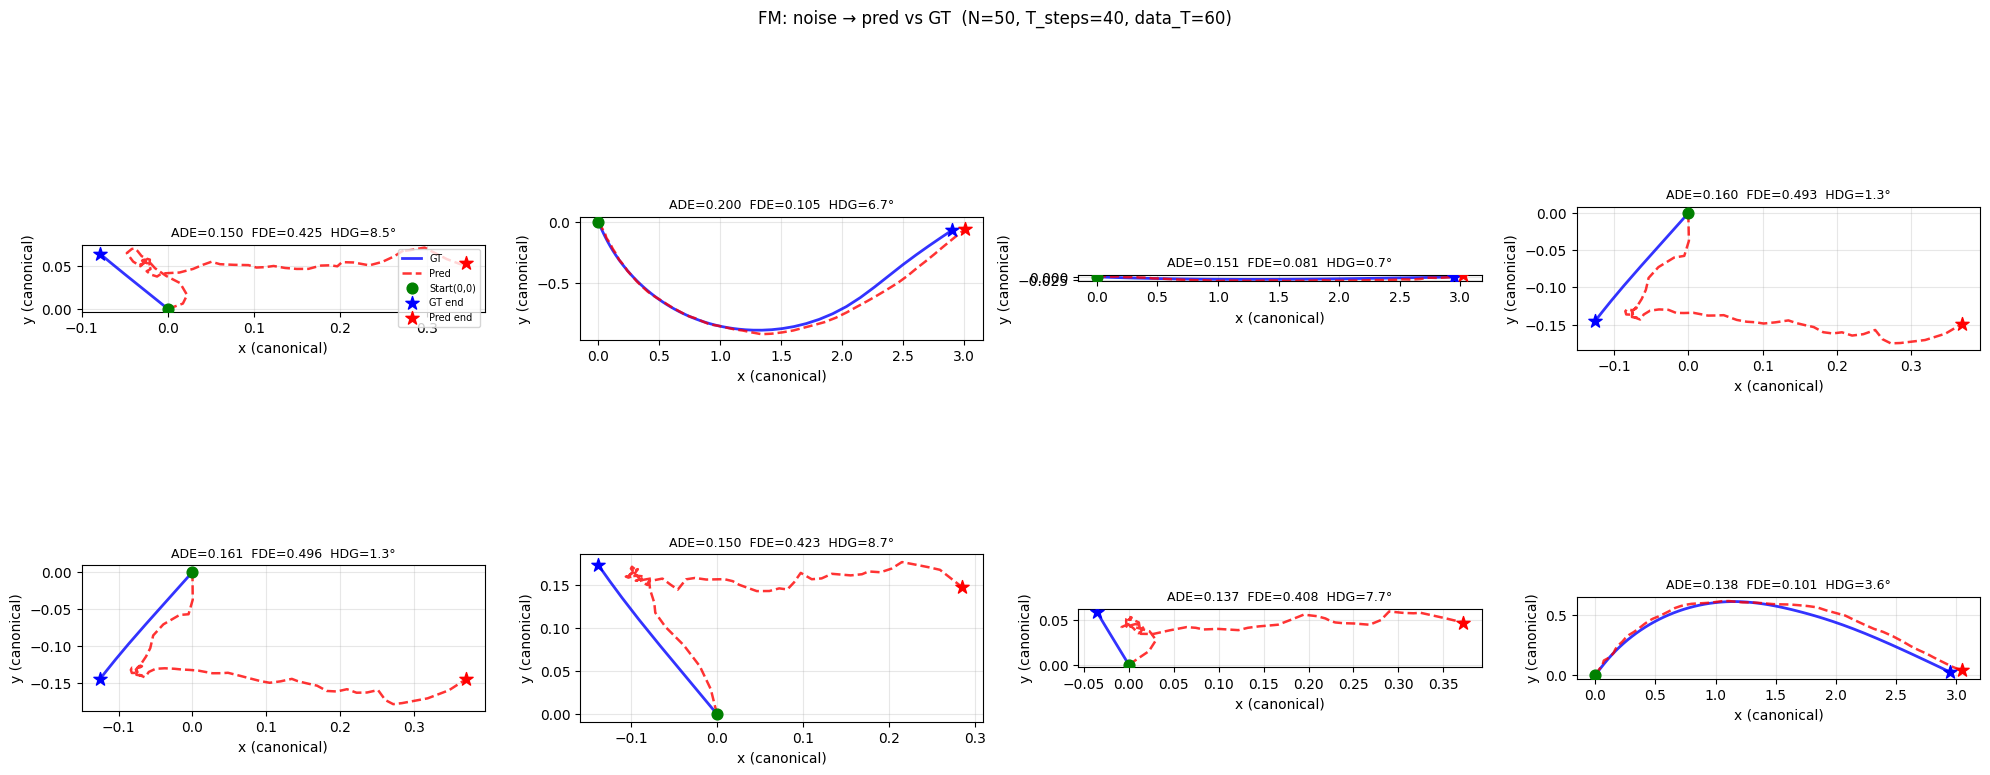

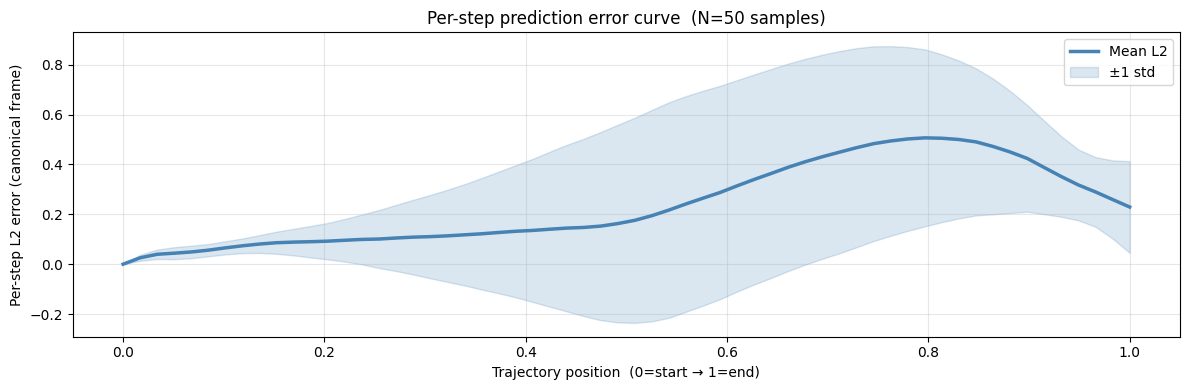

In [ ]:
# ============================================================
# FM Validation — noise → piecewise_sample_fm_5ch_with_cbf → pred vs GT
#
# 数据集里的 canonical ground truth
# 你训练时想拟合的目标分布
#
#FM 生成得像不像训练数据。
#生成模型层 (generative model fidelity)

# pred_can vs traj_can 
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf（来自 sampler_5h.py）
#   - build_canonical_frame（两车实验 Section 4）
#   - make_x0_noise（两车实验 Section 7）
#   - T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
assert 'build_canonical_frame'            in dir(), "请先运行两车实验 cell"
assert 'make_x0_noise'                    in dir(), "请先运行两车实验 cell"
assert 'piecewise_sample_fm_5ch_with_cbf' in dir(), "请先运行两车实验 cell"
assert 'T_steps'                          in dir(), "请先运行两车实验 cell"
print("[依赖检查] ✓")


# ================================================================
# 0) 加载数据
# ================================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(
        r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache"
        r"\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy"
    )

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, 5) = [x, y, theta, v, delta]
controls = raw['controls']  # (N, T, 2) = [a, delta_rate]
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}  T={T}  D={D}")
print(f"[Params] T_steps={T_steps}  num_segments={num_segments}  "
      f"total_time={total_time}  ode_method={ode_method}")
if T_steps != T:
    print(f"[注意] T_steps({T_steps}) != 数据T({T})，pred 会插值对齐")

# 构建 5-channel（channel 定义与训练完全一致）
# ch0=x, ch1=y, ch2=theta, ch3=a, ch4=delta_rate
traj_5ch = np.stack([
    states[:, :, 0],    # x
    states[:, :, 1],    # y
    states[:, :, 2],    # theta
    controls[:, :, 0],  # a
    controls[:, :, 1],  # delta_rate
], axis=1).astype(np.float32)  # (N, 5, T)


# ================================================================
# 1) canonical frame 转换
#
# ★ cond 修复：
#   v0     来自 states[idx, 0, 3]  （速度，不是加速度）
#   delta0 来自 states[idx, 0, 4]  （转向角，不是转向角速度）
#   不能从 traj_5ch[idx, 3, 0] / traj_5ch[idx, 4, 0] 取，
#   因为那两个是 a0 和 delta_rate0
# ================================================================
def canonicalize_single(traj_i, states_i, goal_xy=None):
    """
    traj_i:   (5, T)  [x, y, theta, a, delta_rate]
    states_i: (T, 5)  [x, y, theta, v, delta]  ← 用于取 v0, delta0
    goal_xy:  (2,) or None

    返回:
      traj_can : (5, T)  canonical frame 轨迹
      cond     : (5,)    [dist, v0, cos(th0_can), sin(th0_can), delta0]
      tf       : 变换字典
    """
    x0 = float(traj_i[0, 0]);  y0 = float(traj_i[1, 0])
    gx = float(goal_xy[0]) if goal_xy is not None else float(traj_i[0, -1])
    gy = float(goal_xy[1]) if goal_xy is not None else float(traj_i[1, -1])

    # ★ 直接调用前面已定义的 build_canonical_frame
    tf = build_canonical_frame(
        np.array([x0, y0], np.float32),
        np.array([gx, gy], np.float32)
    )

    out    = traj_i.copy()
    xy_can = tf["w2c"](traj_i[0:2, :].T)  # (T, 2)
    out[0] = xy_can[:, 0]
    out[1] = xy_can[:, 1]
    out[2] = np.array([tf["w2c_angle"](float(th)) for th in traj_i[2]])

    th0_can = tf["w2c_angle"](float(traj_i[2, 0]))

    # ★ 修复：v0 和 delta0 从 states_i 取，而不是从 traj_i[3,0]/traj_i[4,0]
    v0     = float(states_i[0, 3])  # states 第3列 = v（速度）
    delta0 = float(states_i[0, 4])  # states 第4列 = delta（转向角）

    cond = np.array([
        tf["dist"],
        v0,
        float(np.cos(th0_can)),
        float(np.sin(th0_can)),
        delta0,
    ], dtype=np.float32)

    return out, cond, tf


# ================================================================
# 2) FM 预测：直接调用 piecewise_sample_fm_5ch_with_cbf
#    use_cbf=False，参数与两车实验完全一致
# ================================================================
def fm_predict_full(cond, tf, seed=0):
    """
    noise → piecewise_sample_fm_5ch_with_cbf(use_cbf=False) → pred (5, T)
    参数与两车实验 mpc_replan 里的调用完全一致。
    """
    # ★ 直接调用前面已定义的 make_x0_noise
    x0_noise = make_x0_noise(T_steps, seed)

    # ★ 直接调用前面已加载的 piecewise_sample_fm_5ch_with_cbf
    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )  # x_can: (5, T_steps)

    # 插值对齐到数据长度 T
    if x_can.shape[1] != T:
        t_old  = np.linspace(0.0, 1.0, x_can.shape[1])
        t_new  = np.linspace(0.0, 1.0, T)
        x_can  = np.stack([
            interp1d(t_old, x_can[ch], kind='linear')(t_new)
            for ch in range(5)
        ], axis=0).astype(np.float32)

    return x_can  # (5, T)


# ================================================================
# 3) 指标
# ================================================================
def compute_metrics(pred_can, traj_can):
    pred_xy  = pred_can[0:2, :].T          # (T, 2)
    true_xy  = traj_can[0:2, :].T
    per_step = np.linalg.norm(pred_xy - true_xy, axis=1)  # (T,)

    ade = float(per_step.mean())
    fde = float(np.linalg.norm(pred_xy[-1] - true_xy[-1]))

    hdg_diff = (pred_can[2] - traj_can[2] + np.pi) % (2 * np.pi) - np.pi
    hdg      = float(np.mean(np.abs(hdg_diff)))

    return ade, fde, hdg, per_step


# ================================================================
# 4) 主验证循环
# ================================================================
N_SAMPLES = 50
np.random.seed(42)

ades, fdes, hdgs = [], [], []
all_per_step     = []

print(f"\n验证中... (N={N_SAMPLES} samples)")

for i in range(N_SAMPLES):
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]          # (5, T)
    states_i = states[idx]            # (T, 5)  ← 传给 canonicalize_single
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=i)

    ade, fde, hdg, per_step = compute_metrics(pred_can, traj_can)

    ades.append(ade);  fdes.append(fde)
    hdgs.append(hdg);  all_per_step.append(per_step)

    if (i + 1) % 10 == 0:
        print(f"  [{i+1}/{N_SAMPLES}]  "
              f"ADE={np.mean(ades):.4f}  "
              f"FDE={np.mean(fdes):.4f}  "
              f"HDG={np.rad2deg(np.mean(hdgs)):.2f}°")


# ================================================================
# 5) 结果打印
# ================================================================
print(f"\n{'='*50}")
print(f"  ADE  : {np.mean(ades):.4f}  ±{np.std(ades):.4f}")
print(f"  FDE  : {np.mean(fdes):.4f}  ±{np.std(fdes):.4f}")
print(f"  HDG  : {np.rad2deg(np.mean(hdgs)):.2f}°  "
      f"±{np.rad2deg(np.std(hdgs)):.2f}°")
print(f"{'='*50}")
print()
print("判断标准（canonical frame）：")
print("  ADE < 0.05 → 很好 | < 0.15 → 可接受 | > 0.30 → 有问题")
print("  FDE < 0.10 → 很好 | < 0.30 → 可接受 | > 0.60 → 有问题")
print("  HDG < 5°   → 很好 | < 15°  → 可接受 | > 30°  → 有问题")


# ================================================================
# 6) 图1：8 条代表性轨迹对比
# ================================================================
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
np.random.seed(0)

for pi in range(8):
    ax       = axes[pi]
    idx      = np.random.randint(0, N)
    traj     = traj_5ch[idx]
    states_i = states[idx]
    goal     = goals[idx] if goals is not None else None

    traj_can, cond, tf = canonicalize_single(traj, states_i, goal)
    pred_can           = fm_predict_full(cond, tf, seed=pi * 13)
    a, f, h, _         = compute_metrics(pred_can, traj_can)

    ax.plot(traj_can[0], traj_can[1],
            'b-',  lw=2.0, alpha=0.8, label="GT")
    ax.plot(pred_can[0], pred_can[1],
            'r--', lw=1.8, alpha=0.8, label="Pred")
    ax.scatter([0], [0],
               c='green', s=60, zorder=6, label="Start(0,0)")
    ax.scatter([traj_can[0, -1]], [traj_can[1, -1]],
               c='blue', s=100, marker='*', zorder=6, label="GT end")
    ax.scatter([pred_can[0, -1]], [pred_can[1, -1]],
               c='red',  s=100, marker='*', zorder=6, label="Pred end")

    ax.set_title(
        f"ADE={a:.3f}  FDE={f:.3f}  HDG={np.rad2deg(h):.1f}°",
        fontsize=9
    )
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")
    if pi == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    f"FM: noise → pred vs GT  "
    f"(N={N_SAMPLES}, T_steps={T_steps}, data_T={T})",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 7) 图2：逐步误差曲线
# ================================================================
mean_curve = np.mean(all_per_step, axis=0)
std_curve  = np.std(all_per_step,  axis=0)
t_axis     = np.linspace(0.0, 1.0, T)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_axis, mean_curve, lw=2.5, color='steelblue', label="Mean L2")
ax.fill_between(t_axis,
                mean_curve - std_curve,
                mean_curve + std_curve,
                alpha=0.2, color='steelblue', label="±1 std")
ax.set_xlabel("Trajectory position  (0=start → 1=end)")
ax.set_ylabel("Per-step L2 error (canonical frame)")
ax.set_title(f"Per-step prediction error curve  (N={N_SAMPLES} samples)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[依赖检查] ✓
FM Trackability Validation
  每个 seed 独立：fm_path → PP rollout → compare

[Scene] Agent A (diagonal)
  seed=0  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1460  FDE_fm=0.6383
  seed=1  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1474  FDE_fm=0.6373
  seed=2  n_pp= 47  n_fm= 40  ADE=1.0084  FDE_pp=0.1470  FDE_fm=0.6373

[Scene] Agent B (diagonal)
  seed=0  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1461  FDE_fm=0.6381
  seed=1  n_pp= 47  n_fm= 40  ADE=1.0075  FDE_pp=0.1474  FDE_fm=0.6373
  seed=2  n_pp= 47  n_fm= 40  ADE=1.0084  FDE_pp=0.1471  FDE_fm=0.6372

[Scene] Horizontal
  seed=0  n_pp= 43  n_fm= 40  ADE=0.8234  FDE_pp=0.1475  FDE_fm=0.3132
  seed=1  n_pp= 43  n_fm= 40  ADE=0.8229  FDE_pp=0.1486  FDE_fm=0.3127
  seed=2  n_pp= 43  n_fm= 40  ADE=0.8240  FDE_pp=0.1474  FDE_fm=0.3123

[Scene] Angled start
  seed=0  n_pp= 41  n_fm= 40  ADE=0.6944  FDE_pp=0.1413  FDE_fm=0.0381
  seed=1  n_pp= 41  n_fm= 40  ADE=0.6941  FDE_pp=0.1418  FDE_fm=0.0386
  seed=2  n_pp= 41  n_fm= 40  ADE=0.6955 

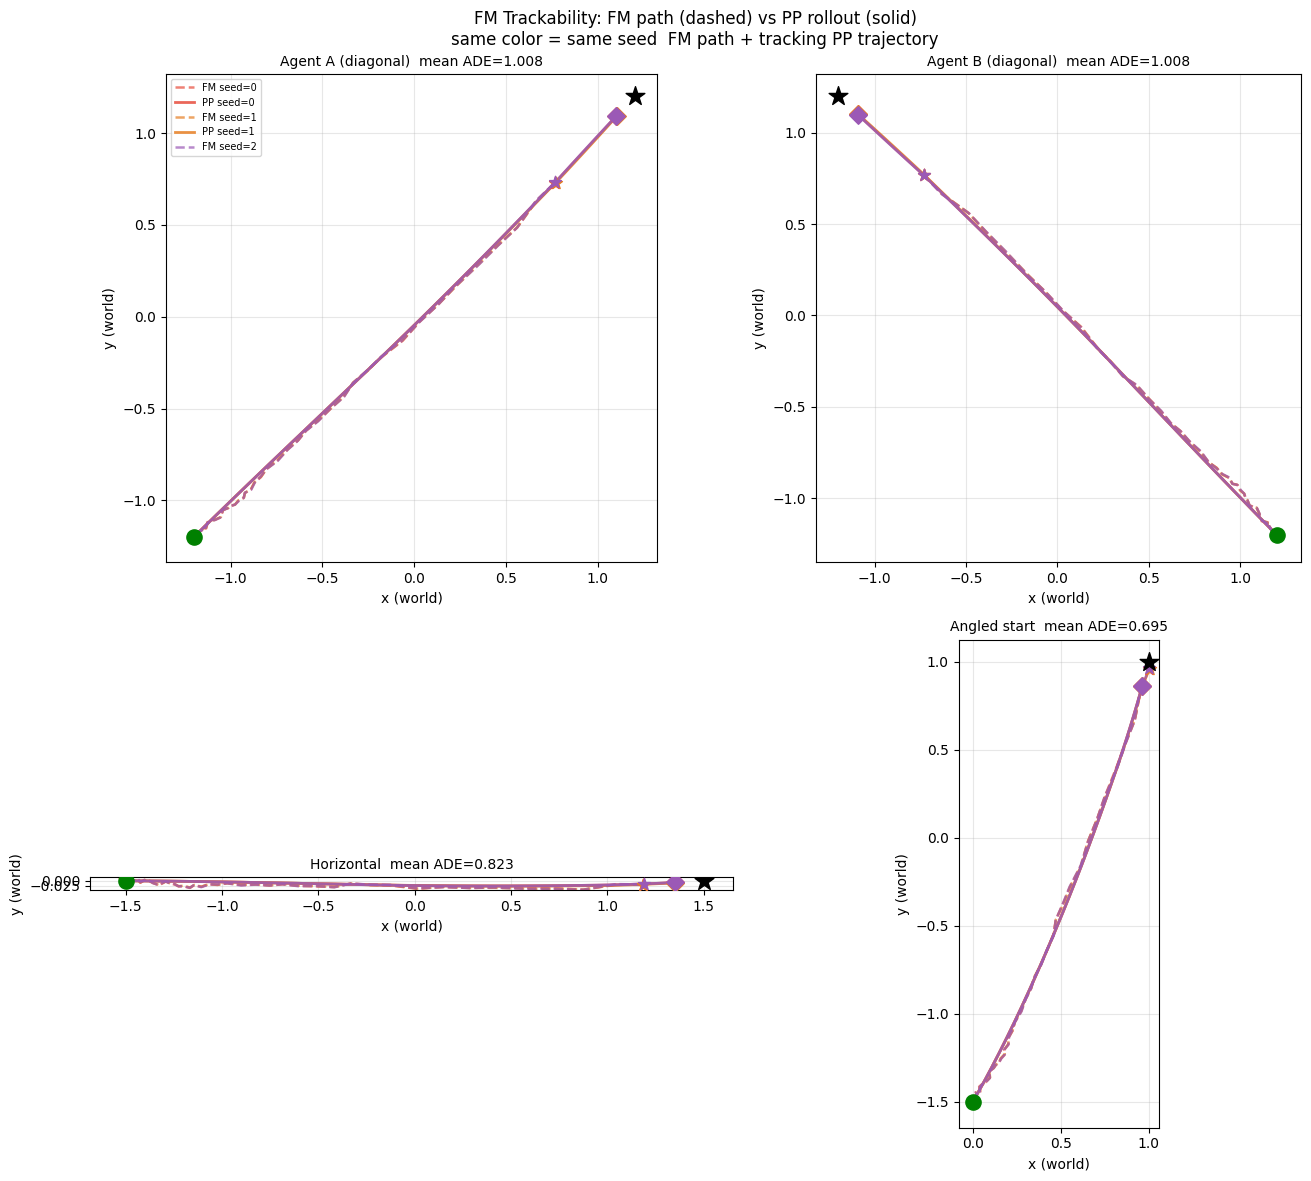

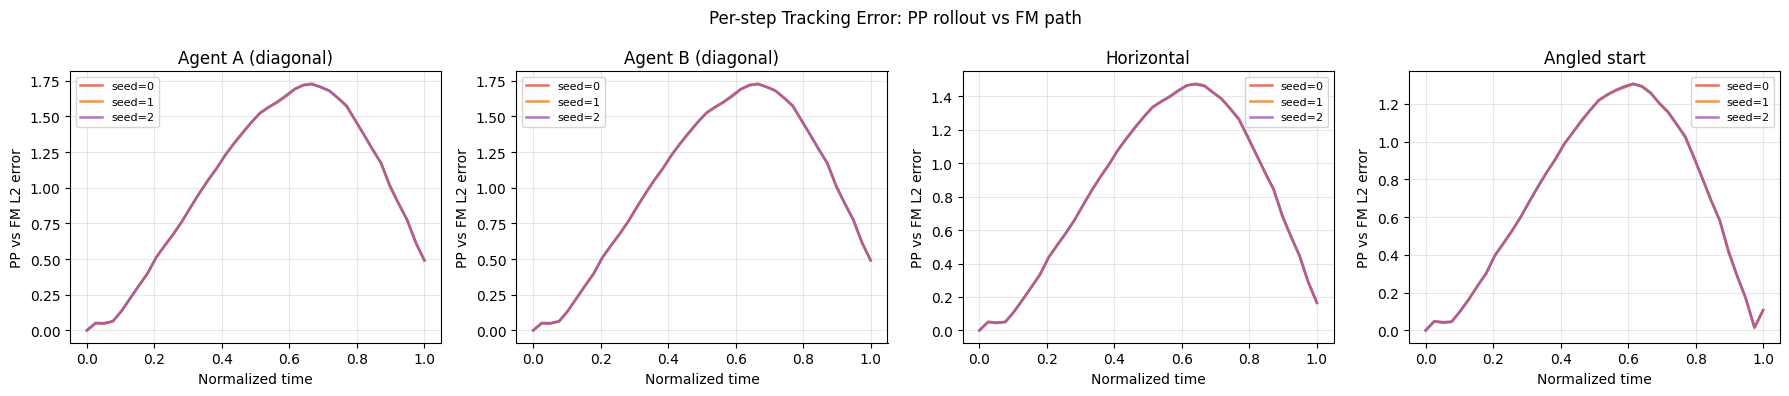

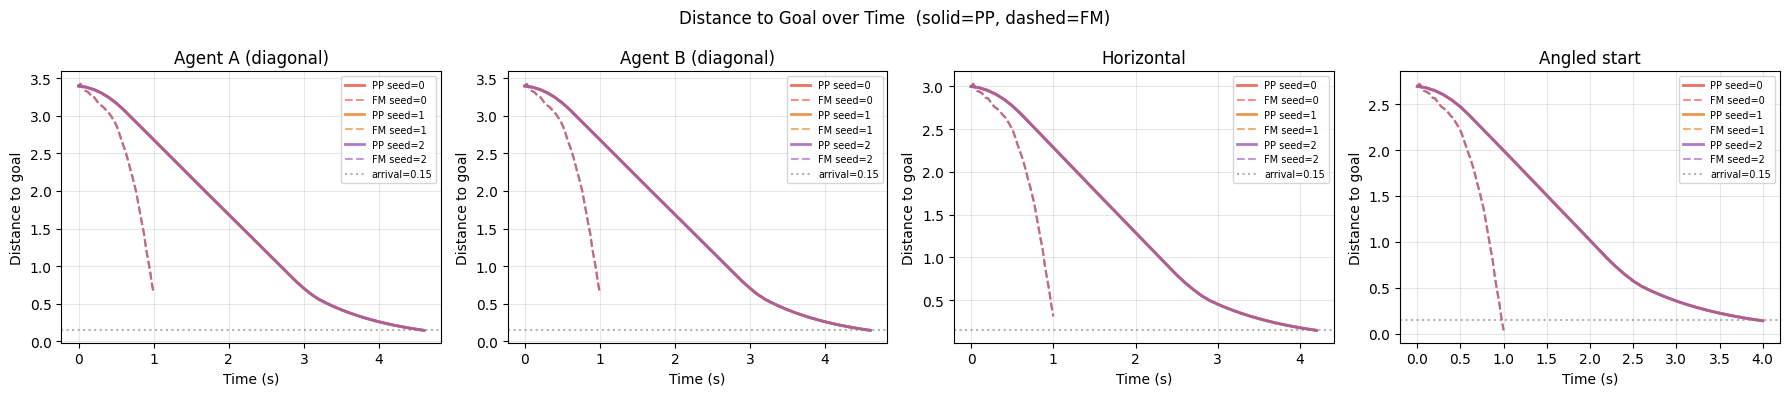

In [24]:
# ============================================================
# FM Validation — Trackability
#
# 验证：FM 生成的路径是否可以被 Pure Pursuit 稳定跟踪
#
# 结构（每个 seed 独立一对）：
#   fm_path  = rollout_fm(start, goal, seed)
#   traj_pp  = rollout_pure_pursuit(start, goal, ref=fm_path)
#   compare(traj_pp, fm_path)
#
# 指标：
#   ADE  小 → FM path 动力学可行，PP 能跟上
#   ADE  大 → FM path 动力学不可行，PP 跟不上
#   FDE_pp  → PP 实际执行后距终点多远
#   FDE_fm  → FM path 终点距目标多远
#
# ★ 前提：必须先运行两车实验 cell，确保以下已定义：
#   - model_5ch, device
#   - piecewise_sample_fm_5ch_with_cbf
#   - build_canonical_frame, make_x0_noise
#   - bicycle_step, pure_pursuit_controls
#   - wrap_pi, T_steps, num_segments, total_time, ode_method, noise_scale
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

torch.set_grad_enabled(False)
model_5ch.eval()

# ── 依赖检查 ──────────────────────────────────────────────────
for _name in ['build_canonical_frame', 'make_x0_noise',
              'piecewise_sample_fm_5ch_with_cbf',
              'bicycle_step', 'pure_pursuit_controls',
              'T_steps', 'noise_scale']:
    assert _name in dir(), f"请先运行两车实验 cell：{_name} 未定义"
print("[依赖检查] ✓")


# ================================================================
# 1) FM path generation
# ================================================================
def rollout_fm(start_state, goal_xy, seed=0):
    """
    noise → piecewise_sample（无CBF）→ FM path（world frame）
    返回:
      path_world: (T_steps, 2)  world frame XY
      x_can:      (5, T_steps)  canonical frame 完整轨迹
      tf:         canonical frame 变换字典
    """
    tf = build_canonical_frame(start_state[:2], goal_xy)

    v0     = float(start_state[3])
    delta0 = float(start_state[4])
    th_can = tf["w2c_angle"](float(start_state[2]))
    cond   = np.array([
        tf["dist"],
        v0,
        float(np.cos(th_can)),
        float(np.sin(th_can)),
        delta0,
    ], dtype=np.float32)

    x0_noise = make_x0_noise(T_steps, seed)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch             = model_5ch,
        T_steps               = T_steps,
        device                = str(device),
        total_time            = total_time,
        num_segments          = num_segments,
        ode_method            = ode_method,
        atol                  = 1e-4,
        rtol                  = 1e-4,
        noise_scale           = noise_scale,
        x0_noise              = x0_noise,
        cond                  = cond,
        start_xy_norm         = tf["start_can"],
        goal_xy_norm          = tf["goal_can"],
        start_guidance_weight = 0.55,
        goal_guidance_weight  = 0.95,
        goal_guidance_mode    = "tail",
        lock_start            = True,
        use_cbf               = False,   # ★ 无CBF
        scaler                = None,
        ellipses              = [],
        cbf_kwargs            = None,
    )

    path_world = tf["c2w"](x_can[0:2, :].T)  # (T_steps, 2)
    return path_world, x_can, tf


# ================================================================
# 2) Pure Pursuit rollout
#    ★ ref_path 就是对应 seed 的 FM path，一对一
# ================================================================
def rollout_pure_pursuit(start_state, goal_xy, ref_path_xy,
                         *, max_steps=300, dt=0.1, v_max=1.0):
    """
    start_state:  (5,) [x, y, theta, v, delta]
    goal_xy:      (2,)
    ref_path_xy:  (T, 2) world frame，来自同一个 seed 的 FM path
    返回:
      traj: (steps+1, 5)
    """
    s    = start_state.copy()
    traj = [s.copy()]
    goal = np.asarray(goal_xy, np.float32)

    for _ in range(max_steps):
        if float(np.linalg.norm(s[:2] - goal)) < 0.15:
            break
        U = pure_pursuit_controls(s, ref_path_xy, goal,
                                  H=1, dt=dt, v_max=v_max)
        s = bicycle_step(s, U[0], dt=dt, v_max=v_max)
        traj.append(s.copy())

    return np.array(traj, dtype=np.float32)  # (steps+1, 5)


# ================================================================
# 3) 指标
# ================================================================
def align_xy(arr, target_len):
    """(M, 2) → (target_len, 2) 线性插值"""
    M = len(arr)
    if M == target_len:
        return arr
    t_old = np.linspace(0.0, 1.0, M)
    t_new = np.linspace(0.0, 1.0, target_len)
    return np.stack([
        interp1d(t_old, arr[:, d])(t_new) for d in range(2)
    ], axis=1).astype(np.float32)


def compute_metrics(traj_pp, fm_path, goal_xy):
    """
    traj_pp:  (N, 5)  PP 执行轨迹
    fm_path:  (M, 2)  FM 生成路径
    goal_xy:  (2,)
    """
    pp_xy = traj_pp[:, 0:2]
    fm_xy = fm_path
    goal  = np.asarray(goal_xy, np.float32)

    n    = min(len(pp_xy), len(fm_xy))
    pp_a = align_xy(pp_xy, n)
    fm_a = align_xy(fm_xy, n)

    per_step = np.linalg.norm(pp_a - fm_a, axis=1)  # (n,)

    return {
        "ADE":    float(per_step.mean()),
        "FDE_pp": float(np.linalg.norm(pp_xy[-1] - goal)),
        "FDE_fm": float(np.linalg.norm(fm_xy[-1] - goal)),
        "per_step": per_step,
        "n_pp":   len(pp_xy),
        "n_fm":   len(fm_xy),
    }


# ================================================================
# 4) 场景定义
# ================================================================
SCENARIOS = [
    {"name": "Agent A (diagonal)",
     "start": np.array([-1.2, -1.2, float(np.arctan2(2.4, 2.4)), 0., 0.], np.float32),
     "goal":  np.array([1.2, 1.2], np.float32)},

    {"name": "Agent B (diagonal)",
     "start": np.array([1.2, -1.2, float(np.arctan2(2.4, -2.4)), 0., 0.], np.float32),
     "goal":  np.array([-1.2, 1.2], np.float32)},

    {"name": "Horizontal",
     "start": np.array([-1.5, 0., 0., 0., 0.], np.float32),
     "goal":  np.array([1.5, 0.], np.float32)},

    {"name": "Angled start",
     "start": np.array([0., -1.5, float(np.deg2rad(60)), 0., 0.], np.float32),
     "goal":  np.array([1.0, 1.0], np.float32)},
]

N_SEEDS  = 3
DT       = 0.1
V_MAX    = 1.0

# ================================================================
# 5) 主循环：每个 seed 独立一对 (fm_path, traj_pp)
# ================================================================
print("=" * 60)
print("FM Trackability Validation")
print("  每个 seed 独立：fm_path → PP rollout → compare")
print("=" * 60)

all_results = []   # list of dict

for sc in SCENARIOS:
    sc_metrics = []
    print(f"\n[Scene] {sc['name']}")

    for seed in range(N_SEEDS):
        # ★ 核心：每个 seed 各自生成 fm_path，再用该 path 作 PP 参考
        fm_path, x_can, tf = rollout_fm(sc["start"], sc["goal"], seed=seed)
        traj_pp             = rollout_pure_pursuit(
            sc["start"], sc["goal"], fm_path,
            max_steps=300, dt=DT, v_max=V_MAX
        )
        m = compute_metrics(traj_pp, fm_path, sc["goal"])
        sc_metrics.append({
            "seed":    seed,
            "fm_path": fm_path,
            "traj_pp": traj_pp,
            **m,
        })
        print(f"  seed={seed}  n_pp={m['n_pp']:3d}  n_fm={m['n_fm']:3d}  "
              f"ADE={m['ADE']:.4f}  FDE_pp={m['FDE_pp']:.4f}  "
              f"FDE_fm={m['FDE_fm']:.4f}")

    all_results.append({"scene": sc, "metrics": sc_metrics})

# ================================================================
# 6) 汇总
# ================================================================
flat = [m for r in all_results for m in r["metrics"]]
print(f"\n{'='*60}")
print(f"汇总（{len(flat)} 对）：")
print(f"  Mean ADE         : {np.mean([m['ADE']    for m in flat]):.4f}"
      f"  ← PP 跟踪 FM path 的平均偏差")
print(f"  Mean FDE_pp→goal : {np.mean([m['FDE_pp'] for m in flat]):.4f}"
      f"  ← PP 执行后距终点距离")
print(f"  Mean FDE_fm→goal : {np.mean([m['FDE_fm'] for m in flat]):.4f}"
      f"  ← FM path 终点距目标距离")
print(f"{'='*60}")
print()
print("解读：")
print("  ADE 小 → FM path 动力学可行，PP 能稳定跟踪")
print("  ADE 大 → FM path 动力学不可行，PP 跟不上")
print("  FDE_fm 小 → FM 能正确生成朝向目标的路径")


# ================================================================
# 7) 图1：XY 轨迹对比（4 场景 × 3 seed）
# ================================================================
colors_seed = ['#e74c3c', '#e67e22', '#9b59b6']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for sc_i, res in enumerate(all_results):
    ax   = axes[sc_i]
    sc   = res["scene"]
    goal = sc["goal"]

    for m in res["metrics"]:
        seed    = m["seed"]
        fm_path = m["fm_path"]
        traj_pp = m["traj_pp"]
        c       = colors_seed[seed]

        # FM path
        ax.plot(fm_path[:, 0], fm_path[:, 1],
                '--', lw=1.8, alpha=0.7, color=c,
                label=f"FM seed={seed}")
        # PP rollout（跟踪同一条 FM path）
        ax.plot(traj_pp[:, 0], traj_pp[:, 1],
                '-', lw=2.0, alpha=0.85, color=c,
                label=f"PP seed={seed}")
        # PP 终点
        ax.scatter(traj_pp[-1, 0], traj_pp[-1, 1],
                   c=c, s=80, marker='D', zorder=6)
        # FM 终点
        ax.scatter(fm_path[-1, 0], fm_path[-1, 1],
                   c=c, s=80, marker='*', zorder=6)

    # 起点 / 目标
    ax.scatter(*sc["start"][:2], c='green', s=120,
               marker='o', zorder=7, label="Start")
    ax.scatter(*goal, c='black', s=200,
               marker='*', zorder=7, label="Goal")

    mean_ade = np.mean([m['ADE'] for m in res["metrics"]])
    ax.set_title(f"{sc['name']}  mean ADE={mean_ade:.3f}", fontsize=10)
    ax.set_aspect("equal"); ax.grid(alpha=0.3)
    ax.set_xlabel("x (world)"); ax.set_ylabel("y (world)")
    if sc_i == 0:
        # 简化图例：只显示一组
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:5], labels[:5], fontsize=7)

plt.suptitle(
    "FM Trackability: FM path (dashed) vs PP rollout (solid)\n"
    "same color = same seed  FM path + tracking PP trajectory",
    fontsize=12
)
plt.tight_layout()
plt.show()


# ================================================================
# 8) 图2：每步跟踪误差曲线
# ================================================================
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(18, 4))

for sc_i, res in enumerate(all_results):
    ax = axes[sc_i]
    for m in res["metrics"]:
        t = np.linspace(0.0, 1.0, len(m["per_step"]))
        ax.plot(t, m["per_step"], lw=1.8, alpha=0.8,
                color=colors_seed[m["seed"]],
                label=f"seed={m['seed']}")
    ax.set_title(res["scene"]["name"])
    ax.set_xlabel("Normalized time")
    ax.set_ylabel("PP vs FM L2 error")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Per-step Tracking Error: PP rollout vs FM path", fontsize=12)
plt.tight_layout()
plt.show()


# ================================================================
# 9) 图3：距终点距离曲线
# ================================================================
fig, axes = plt.subplots(1, len(SCENARIOS), figsize=(18, 4))

for sc_i, res in enumerate(all_results):
    ax   = axes[sc_i]
    goal = res["scene"]["goal"]

    for m in res["metrics"]:
        c       = colors_seed[m["seed"]]
        traj_pp = m["traj_pp"]
        fm_path = m["fm_path"]

        # PP 距终点
        pp_dist = np.linalg.norm(traj_pp[:, 0:2] - goal, axis=1)
        t_pp    = np.arange(len(pp_dist)) * DT
        ax.plot(t_pp, pp_dist, '-', lw=2.0, alpha=0.8, color=c,
                label=f"PP seed={m['seed']}")

        # FM 距终点
        fm_dist = np.linalg.norm(fm_path - goal, axis=1)
        t_fm    = np.linspace(0, total_time, len(fm_dist))
        ax.plot(t_fm, fm_dist, '--', lw=1.5, alpha=0.6, color=c,
                label=f"FM seed={m['seed']}")

    ax.axhline(0.15, ls=':', color='gray', alpha=0.6, label="arrival=0.15")
    ax.set_title(res["scene"]["name"])
    ax.set_xlabel("Time (s)"); ax.set_ylabel("Distance to goal")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle("Distance to Goal over Time  (solid=PP, dashed=FM)", fontsize=12)
plt.tight_layout()
plt.show()

[Data] N=100, T=60, D=5

(1) 单步/短时间预测一致性 (local rollout)
  Samples=20, rollout=3 steps
  Mean pos L2    : 0.0359
  Mean heading err: 2.39 deg
  Mean cross-track: 0.0261

(2) 随机中间点长 rollout (20%, 50%, 80%)
  Start at 20% | pos_L2=0.5295 | hdg=45.94deg | cte=0.2558
  Start at 50% | pos_L2=0.4278 | hdg=27.77deg | cte=0.2895
  Start at 80% | pos_L2=0.1715 | hdg=8.23deg | cte=0.1356

(3) 双向一致性 (noise → mid → end)
  Samples=10, mid_frac=0.5
  Mid-point pos err (pred vs true) : 0.7332
  End-point pos err (2-seg vs true) : 1.4837
  Loop consistency (2-seg vs direct): 0.2510  ← 越小越好


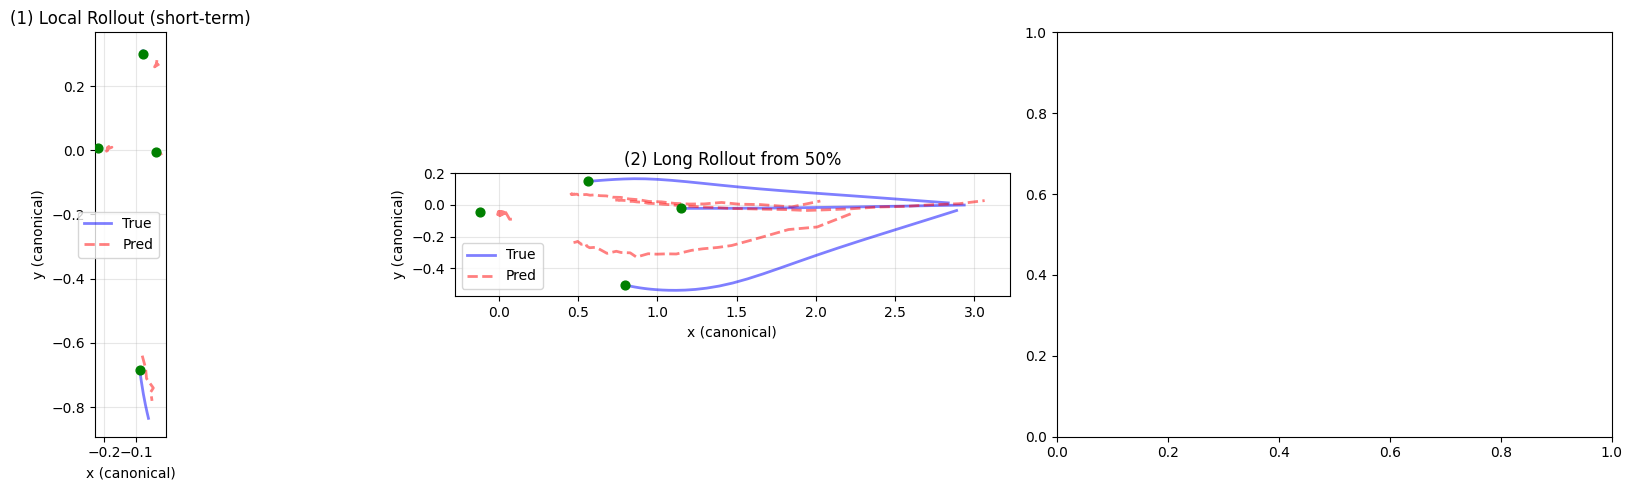


Summary
(1) Local rollout    | pos_L2=0.0359 | hdg=2.39° | cte=0.0261
(2) Long rollout 20%  | pos_L2=0.5295
(2) Long rollout 50%  | pos_L2=0.4278
(2) Long rollout 80%  | pos_L2=0.1715

判断标准（canonical frame，单位与训练数据一致）：
  pos_L2  < 0.05  → 很好 | < 0.15 → 可接受 | > 0.3 → 有问题
  hdg_err < 5°    → 很好 | < 15°  → 可接受 | > 30° → 有问题
  loop_err< 0.05  → flow 一致性好


In [35]:
# ============================================================
# FM Flow Matching - 三种一致性验证 Cell
# (1) 单步/短时间预测一致性 (local rollout)
# (2) 随机中间点长 rollout
# (3) 双向一致性 (noise→mid→end vs 真实)
# ============================================================

import numpy as np
import torch
import torchdiffeq
import matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
model_5ch.eval()

# ===============================================================
# 0) 加载验证数据（复用训练数据，取 val split 或全部）
# ===============================================================
data_path = Path("cache/car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")
if not data_path.exists():
    data_path = Path(r"D:\projects\lab2025\dmpc_fm_cbf\notebooks\cache\car_ring_track_oc_dataset_v1_v0rand_with_vel.npy")

raw      = np.load(str(data_path), allow_pickle=True).item()
states   = raw['states']    # (N, T, D)
controls = raw['controls']  # (N, T, 2)
goals    = raw.get('goals', None)

N, T, D = states.shape
print(f"[Data] N={N}, T={T}, D={D}")

# 构建 5-channel traj (复用训练时的 canonicalize)
traj_5ch = np.stack([
    states[:, :, 0],
    states[:, :, 1],
    states[:, :, 2],
    controls[:, :, 0],
    controls[:, :, 1],
], axis=1).astype(np.float32)  # (N, 5, T)

def canonicalize_single(traj_i, goal_xy=None):
    """将单条轨迹转换到 canonical frame，返回 (5,T) 和 cond (5,)"""
    x0, y0 = traj_i[0, 0], traj_i[1, 0]
    gx = goal_xy[0] if goal_xy is not None else traj_i[0, -1]
    gy = goal_xy[1] if goal_xy is not None else traj_i[1, -1]
    dx, dy   = gx - x0, gy - y0
    dist     = float(np.sqrt(dx**2 + dy**2) + 1e-9)
    cos_a, sin_a = dx / dist, dy / dist
    angle_off = float(np.arctan2(sin_a, cos_a))

    out = traj_i.copy()
    out[0] =  cos_a * (traj_i[0] - x0) + sin_a * (traj_i[1] - y0)
    out[1] = -sin_a * (traj_i[0] - x0) + cos_a * (traj_i[1] - y0)
    out[2] = np.array([(float(th) - angle_off + np.pi) % (2*np.pi) - np.pi
                        for th in traj_i[2]])

    th0_can = float((traj_i[2, 0] - angle_off + np.pi) % (2*np.pi) - np.pi)
    v0      = float(states[0, 0, 3]) if D > 3 else 0.0
    cond    = np.array([dist, float(traj_i[3, 0]),
                        np.cos(th0_can), np.sin(th0_can),
                        float(traj_i[4, 0])], dtype=np.float32)
    return out, cond

# ===============================================================
# 辅助：用 model 做 ODE rollout，从 x_init 积分 t_start → t_end
# ===============================================================
def fm_ode_rollout(x_init_5T, cond_vec, t_start, t_end, n_out_steps=None, method="euler"):
    """
    x_init_5T : (5, T) numpy，作为 ODE 初值
    cond_vec  : (5,)  numpy
    t_start, t_end : float in [0,1]
    n_out_steps: 输出的中间时刻数量（None=只要终点）
    返回: (n_out_steps+1, 5, T) numpy，包含起点
    """
    dev  = next(model_5ch.parameters()).device
    x0_t = torch.tensor(x_init_5T, device=dev).unsqueeze(0)  # (1,5,T)
    c_t  = torch.tensor(cond_vec,   device=dev).unsqueeze(0)  # (1,5)

    if n_out_steps is None:
        t_span = torch.tensor([t_start, t_end], device=dev)
    else:
        t_span = torch.linspace(t_start, t_end, n_out_steps + 1, device=dev)

    def rhs(t, x_flat):
        xn = x_flat.view(1, 5, T)
        tt = torch.tensor([float(t)], device=dev)
        return model_5ch(xn, tt, cond=c_t).reshape(-1)

    sol = torchdiffeq.odeint(rhs, x0_t.reshape(-1), t_span,
                              method=method, atol=1e-4, rtol=1e-4)
    # sol: (n_steps, 5*T)
    return sol.reshape(-1, 5, T).cpu().numpy()  # (n_steps, 5, T)

# ===============================================================
# 指标函数
# ===============================================================
def pos_l2(pred_xy, true_xy):
    """pred_xy, true_xy: (T, 2)"""
    return float(np.mean(np.linalg.norm(pred_xy - true_xy, axis=1)))

def heading_err(pred_th, true_th):
    """角度误差（弧度），(T,)"""
    diff = (pred_th - true_th + np.pi) % (2*np.pi) - np.pi
    return float(np.mean(np.abs(diff)))

def cross_track_err(pred_xy, true_xy):
    """逐点到真实路径的垂直距离均值"""
    errs = []
    for i in range(len(pred_xy)):
        idx = np.argmin(np.linalg.norm(true_xy - pred_xy[i], axis=1))
        errs.append(float(np.linalg.norm(pred_xy[i] - true_xy[idx])))
    return float(np.mean(errs))

# ===============================================================
# (1) 单步 / 短时间预测一致性
# ===============================================================
print("\n" + "="*60)
print("(1) 单步/短时间预测一致性 (local rollout)")
print("="*60)

N_SAMPLES   = 20    # 验证样本数
M_STEPS     = 3     # 往前积分 m 步（时间步）
dt_norm     = 1.0 / (T - 1)  # 归一化时间步长

np.random.seed(0)
results_1 = []

for _ in range(N_SAMPLES):
    idx  = np.random.randint(0, N)
    traj = traj_5ch[idx]  # (5, T)
    goal = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj, goal)

    # 随机选中间帧作为起点（避开首尾）
    k = np.random.randint(T // 4, T // 2)
    t_k   = k * dt_norm
    t_km  = min((k + M_STEPS) * dt_norm, 1.0)

    x_init = traj_can[:, k]   # (5,) 某一帧
    # 扩展成 (5, T)：用真实 xk 填满（模型需要全序列，取当前帧复制）
    x_init_5T = np.tile(x_init.reshape(5, 1), (1, T)).astype(np.float32)
    # 实际上模型操作整条轨迹，所以用真实的 traj_can[:, k:] 拼起来更合理
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]  # 起点之前用 xk 填充（相当于从 xk 开始）

    sol = fm_ode_rollout(x_init_5T, cond, t_k, t_km, n_out_steps=M_STEPS)
    # sol[-1]: (5, T) 预测结果

    pred_xy  = sol[-1][0:2, k:k+M_STEPS+1].T   # (M+1, 2)
    true_xy  = traj_can[0:2, k:k+M_STEPS+1].T  # (M+1, 2)
    pred_th  = sol[-1][2, k:k+M_STEPS+1]
    true_th  = traj_can[2, k:k+M_STEPS+1]

    results_1.append({
        "pos_l2":  pos_l2(pred_xy, true_xy),
        "hdg_err": heading_err(pred_th, true_th),
        "cte":     cross_track_err(pred_xy, true_xy),
    })

r1_pos = np.mean([r["pos_l2"]  for r in results_1])
r1_hdg = np.mean([r["hdg_err"] for r in results_1])
r1_cte = np.mean([r["cte"]     for r in results_1])
print(f"  Samples={N_SAMPLES}, rollout={M_STEPS} steps")
print(f"  Mean pos L2    : {r1_pos:.4f}")
print(f"  Mean heading err: {np.rad2deg(r1_hdg):.2f} deg")
print(f"  Mean cross-track: {r1_cte:.4f}")

# ===============================================================
# (2) 随机中间点长 rollout
# ===============================================================
print("\n" + "="*60)
print("(2) 随机中间点长 rollout (20%, 50%, 80%)")
print("="*60)

START_FRACS = [0.2, 0.5, 0.8]
N_SAMPLES_2 = 10
results_2   = {f: [] for f in START_FRACS}

for frac in START_FRACS:
    for _ in range(N_SAMPLES_2):
        idx  = np.random.randint(0, N)
        traj = traj_5ch[idx]
        goal = goals[idx] if goals is not None else None
        traj_can, cond = canonicalize_single(traj, goal)

        k     = int(frac * (T - 1))
        t_k   = k * dt_norm

        # 从 xk 出发积分到末尾
        x_init_5T        = traj_can.copy()
        x_init_5T[:, :k] = traj_can[:, k:k+1]

        n_remain = T - k
        sol = fm_ode_rollout(x_init_5T, cond, t_k, 1.0,
                             n_out_steps=n_remain, method="euler")
        # sol: (n_remain+1, 5, T)
        pred_end = sol[-1]  # (5, T)

        pred_xy = pred_end[0:2, k:].T   # (T-k, 2)
        true_xy = traj_can[0:2, k:].T
        pred_th = pred_end[2, k:]
        true_th = traj_can[2, k:]

        results_2[frac].append({
            "pos_l2":  pos_l2(pred_xy, true_xy),
            "hdg_err": heading_err(pred_th, true_th),
            "cte":     cross_track_err(pred_xy, true_xy),
        })

    m_pos = np.mean([r["pos_l2"]  for r in results_2[frac]])
    m_hdg = np.mean([r["hdg_err"] for r in results_2[frac]])
    m_cte = np.mean([r["cte"]     for r in results_2[frac]])
    print(f"  Start at {int(frac*100)}% | pos_L2={m_pos:.4f} | "
          f"hdg={np.rad2deg(m_hdg):.2f}deg | cte={m_cte:.4f}")

# ===============================================================
# (3) 双向一致性（noise → xk → xT，再对比真实 xk 附近分布）
# ===============================================================
print("\n" + "="*60)
print("(3) 双向一致性 (noise → mid → end)")
print("="*60)

N_SAMPLES_3 = 10
MID_FRAC    = 0.5   # 用 50% 处作为"中间点"
results_3   = []

for _ in range(N_SAMPLES_3):
    idx  = np.random.randint(0, N)
    traj = traj_5ch[idx]
    goal = goals[idx] if goals is not None else None
    traj_can, cond = canonicalize_single(traj, goal)

    k_mid = int(MID_FRAC * (T - 1))
    t_mid = k_mid * dt_norm

    # Step A: noise → x_mid（积分 0→t_mid）
    x_noise = np.random.randn(5, T).astype(np.float32) * 0.08
    x_noise[:, 0] = 0.0  # lock start
    sol_a = fm_ode_rollout(x_noise, cond, 0.0, t_mid, n_out_steps=1)
    x_mid_pred = sol_a[-1]  # (5, T)

    # Step B: x_mid_pred → x_end（积分 t_mid→1.0）
    sol_b = fm_ode_rollout(x_mid_pred, cond, t_mid, 1.0, n_out_steps=1)
    x_end_pred = sol_b[-1]  # (5, T)

    # 对比1：x_mid_pred 和真实 x_mid 的差异（中间点一致性）
    mid_pos_err = float(np.mean(np.linalg.norm(
        x_mid_pred[0:2, :].T - traj_can[0:2, :].T, axis=1
    )))

    # 对比2：x_end_pred 和真实轨迹末尾的差异（终点一致性）
    end_pos_err = float(np.linalg.norm(
        x_end_pred[0:2, -1] - traj_can[0:2, -1]
    ))

    # 对比3：完整路径 noise→end 直接积分 vs 两段拼接的终点差异（循环一致性）
    sol_direct = fm_ode_rollout(x_noise, cond, 0.0, 1.0, n_out_steps=1)
    x_end_direct = sol_direct[-1]
    loop_err = float(np.linalg.norm(
        x_end_pred[0:2, -1] - x_end_direct[0:2, -1]
    ))

    results_3.append({
        "mid_pos_err": mid_pos_err,
        "end_pos_err": end_pos_err,
        "loop_err":    loop_err,
    })

r3_mid  = np.mean([r["mid_pos_err"] for r in results_3])
r3_end  = np.mean([r["end_pos_err"] for r in results_3])
r3_loop = np.mean([r["loop_err"]    for r in results_3])
print(f"  Samples={N_SAMPLES_3}, mid_frac={MID_FRAC}")
print(f"  Mid-point pos err (pred vs true) : {r3_mid:.4f}")
print(f"  End-point pos err (2-seg vs true) : {r3_end:.4f}")
print(f"  Loop consistency (2-seg vs direct): {r3_loop:.4f}  ← 越小越好")

# ===============================================================
# 可视化：每种检查各画 3 条代表性轨迹
# ===============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

np.random.seed(42)

# --- Plot (1): local rollout ---
ax = axes[0]
ax.set_title("(1) Local Rollout (short-term)")
for _ in range(4):
    idx  = np.random.randint(0, N)
    traj_can, cond = canonicalize_single(traj_5ch[idx],
                                          goals[idx] if goals is not None else None)
    k = T // 3
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]
    sol = fm_ode_rollout(x_init_5T, cond, k*dt_norm,
                          min((k+5)*dt_norm, 1.0), n_out_steps=5)
    ax.plot(traj_can[0, k:k+6], traj_can[1, k:k+6],
            'b-', alpha=0.5, lw=2, label="True" if _ == 0 else "")
    ax.plot(sol[-1][0, k:k+6], sol[-1][1, k:k+6],
            'r--', alpha=0.5, lw=2, label="Pred" if _ == 0 else "")
    ax.scatter([traj_can[0, k]], [traj_can[1, k]], c='g', s=40, zorder=5)
ax.legend(); ax.grid(alpha=0.3); ax.set_aspect("equal")
ax.set_xlabel("x (canonical)"); ax.set_ylabel("y (canonical)")

# --- Plot (2): long rollout ---
ax2 = axes[1]
ax2.set_title("(2) Long Rollout from 50%")
for _ in range(4):
    idx  = np.random.randint(0, N)
    traj_can, cond = canonicalize_single(traj_5ch[idx],
                                          goals[idx] if goals is not None else None)
    k = T // 2
    x_init_5T = traj_can.copy()
    x_init_5T[:, :k] = traj_can[:, k:k+1]
    sol = fm_ode_rollout(x_init_5T, cond, k*dt_norm, 1.0,
                          n_out_steps=T-k, method="euler")
    ax2.plot(traj_can[0, k:], traj_can[1, k:],
             'b-', alpha=0.5, lw=2, label="True" if _ == 0 else "")
    ax2.plot(sol[-1][0, k:], sol[-1][1, k:],
             'r--', alpha=0.5, lw=2, label="Pred" if _ == 0 else "")
    ax2.scatter([traj_can[0, k]], [traj_can[1, k]], c='g', s=40, zorder=5)
ax2.legend(); ax2.grid(alpha=0.3); ax2.set_aspect("equal")
ax2.set_xlabel("x (canonical)"); ax2.set_ylabel("y (canonical)")

# --- Plot (3): bidirectional ---
# ax3 = axes[2]
# ax3.set_title("(3) Bidirectional: noise→mid→end vs direct")
# for _ in range(4):
#     idx  = np.random.randint(0, N)
#     traj_can, cond = canonicalize_single(traj_5ch[idx],
#                                           goals[idx] if goals is not None else None)
#     k_mid = T // 2
#     x_noise = np.random.randn(5, T).astype(np.float32) * 0.08
#     x_noise[:, 0] = 0.0

#     sol_a      = fm_ode_rollout(x_noise, cond, 0.0, k_mid*dt_norm, n_out_steps=1)
#     sol_b      = fm_ode_rollout(sol_a[-1], cond, k_mid*dt_norm, 1.0, n_out_steps=1)
#     sol_direct = fm_ode_rollout(x_noise, cond, 0.0, 1.0, n_out_steps=1)

#     ax3.plot(traj_can[0], traj_can[1],
#              'b-', alpha=0.3, lw=1.5, label="True" if _ == 0 else "")
#     ax3.plot(sol_b[-1][0], sol_b[-1][1],
#              'r--', alpha=0.5, lw=1.5, label="2-seg" if _ == 0 else "")
#     ax3.plot(sol_direct[-1][0], sol_direct[-1][1],
#              'g:', alpha=0.5, lw=1.5, label="Direct" if _ == 0 else "")

# ax3.legend(); ax3.grid(alpha=0.3); ax3.set_aspect("equal")
# ax3.set_xlabel("x (canonical)"); ax3.set_ylabel("y (canonical)")

plt.tight_layout()
plt.show()

# ===============================================================
# 汇总打印
# ===============================================================
print("\n" + "="*60)
print("Summary")
print("="*60)
print(f"(1) Local rollout    | pos_L2={r1_pos:.4f} | hdg={np.rad2deg(r1_hdg):.2f}° | cte={r1_cte:.4f}")
for frac in START_FRACS:
    m = np.mean([r["pos_l2"] for r in results_2[frac]])
    print(f"(2) Long rollout {int(frac*100)}%  | pos_L2={m:.4f}")
# print(f"(3) Loop consistency | mid={r3_mid:.4f} | end={r3_end:.4f} | loop={r3_loop:.4f}")
print()
print("判断标准（canonical frame，单位与训练数据一致）：")
print("  pos_L2  < 0.05  → 很好 | < 0.15 → 可接受 | > 0.3 → 有问题")
print("  hdg_err < 5°    → 很好 | < 15°  → 可接受 | > 30° → 有问题")
print("  loop_err< 0.05  → flow 一致性好")

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler sig] (*, model_5ch, T_steps: 'int', device: 'str' = 'cuda', total_time: 'float' = 1.0, num_segments: 'int' = 20, ode_method: 'str' = 'dopri5', atol: 'float' = 1e-05, rtol: 'float' = 1e-05, noise_scale: 'float' = 1.0, x0_noise: 'torch.Tensor | None' = None, cond=None, start_xy=None, start_xy_norm=None, start_guidance_weight: 'float' = 0.0, lock_start: 'bool' = False, goal_xy=None, goal_xy_norm=None, goal_guidance_weight: 'float' = 0.0, goal_guidance_mode: 'str' = 'endpoint', use_cbf: 'bool' = True, scaler=None, ellipses=None, tau0_hf: 'float' = 0.7, p_hf: 'float' = 2.0, lf_on: 'float' = 1.0, hf_max: 'float' = 1.0, cbf_kwargs: 'dict | None' = None)
[model] loaded
FM-MPC Bicycle - 验证结果改进版
K=8  PATH_HEADING_TOL=60°  PATH_START_TOL=0.3
goal_tol=0.2  ARRIVAL_DIST=0.15  APPROACH_DIST=0.6
[  0] dA=3.394 dB=3.394 dist=2.400 vA=0.00 vB=0.00
[  1] dA=3.379 dB=3.379 dist=2.379 vA=0.15 vB=0.15
[  2] dA=3.349 

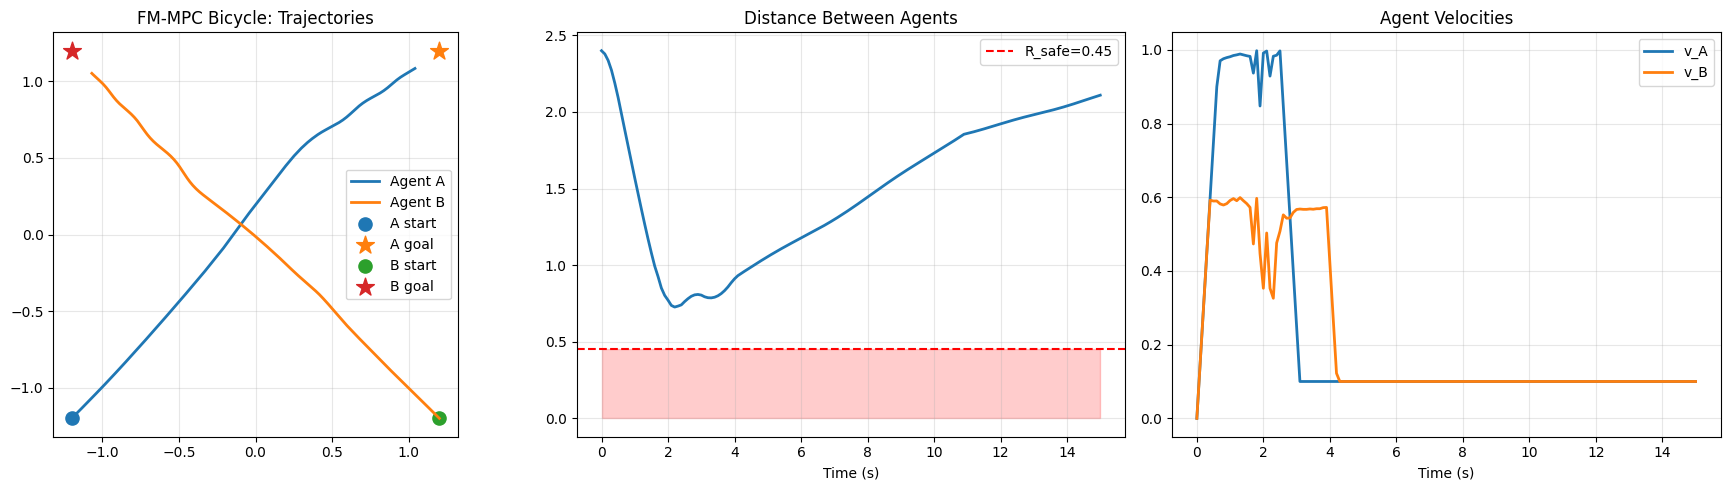

In [16]:
# ============================================================
# FM-MPC Bicycle - 根据验证结果改进版
# 针对问题：模型前半段预测差，Long rollout 误差大
# 改进策略：
#   1. 增加 K（采样数），用更多候选路径对冲模型不稳定性
#   2. 增加路径质量过滤：起始段偏差过大的路径直接丢弃
#   3. goal_guidance_weight 提高，强制路径末端拉向目标
#   4. 增加 replan 频率自适应：路径质量差时强制重采样
#   5. cost 函数增加路径起始段一致性惩罚
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
print("[sampler sig]", sampler_sig)
assert "cond" in sampler_sig.parameters, "Loaded sampler has no cond; wrong sampler file?"

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

# FM
T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

# MPC
H = 12
K = 8           # ★ 原5→8：模型不稳定时多采样对冲，增加找到好路径的概率
REPLAN_EVERY = 1
MAX_STEPS    = 300

# Goal / stopping
goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

# Safety
R_SAFE = 0.45

# ★ 路径质量过滤阈值（根据验证结果设定）
# Local rollout pos_L2=0.0325 说明单步是好的
# 但 Long rollout 20% 处 pos_L2=0.54，说明路径整体可能偏很多
# 用路径起始方向和当前heading的夹角来过滤明显错误的路径
PATH_HEADING_TOL = np.deg2rad(60.0)  # ★ 路径起始方向与当前heading偏差超过60°则丢弃
PATH_START_TOL   = 0.30              # ★ 路径第一个点离当前位置超过这个距离则丢弃（lock_start失效）

# ===============================================================
# 3) Bicycle dynamics（不变）
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame（不变）
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c     = float(d[0] / dist)
    s     = float(d[1] / dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings（不变）
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(dist_AB):
    if dist_AB > SAFE_DIST_FAR:
        return False, None
    elif dist_AB > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction（不变）
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses(tf, other_pred_pos, dist_AB):
    if other_pred_pos is None or len(other_pred_pos) < 2:
        return []
    idxs = [0, 1, 2, 4, 6, 8, 10, len(other_pred_pos)-1]
    idxs = [i for i in idxs if 0 <= i < len(other_pred_pos)]
    idxs = sorted(list(dict.fromkeys(idxs)))
    r = (r_obs_near if dist_AB < 1.2 else r_obs_far)
    ellipses = []
    for i in idxs:
        c_can = tf["w2c"](other_pred_pos[i].reshape(1, 2))[0]
        ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ★ 改动：goal_guidance_weight 0.90→0.95，强制末端更靠近目标
#    补偿模型前半段不准导致末端飘离的问题
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path(*, self_state, goal_xy, other_pred_pos, seed):
    self_xy = self_state[:2]
    tf      = build_canonical_frame(self_xy, goal_xy)
    other_now = self_xy if (other_pred_pos is None or len(other_pred_pos) == 0) else other_pred_pos[0]
    dist_AB   = float(np.linalg.norm(self_xy - other_now))
    use_cbf, cbf_kwargs = get_cbf_config(dist_AB)
    ellipses = build_time_expanded_ellipses(tf, other_pred_pos, dist_AB) if use_cbf else []
    x0_noise = make_x0_noise(T_steps, seed)
    v0     = float(self_state[3])
    th_can = tf["w2c_angle"](float(self_state[2]))
    delta0 = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0], dtype=np.float32)

    x_can, states_norm, controls_norm = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"],
        goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55,   # ★ 0.45→0.55：加强起点锁定，对抗前半段偏差
        goal_guidance_weight=0.95,    # ★ 0.90→0.95：加强终点牵引
        goal_guidance_mode="tail",
        lock_start=True,
        use_cbf=bool(use_cbf), scaler=None, ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )

    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), dist_AB

# ===============================================================
# ★ 新增：路径质量检查
# 验证结果表明模型前半段不稳定，需要过滤明显异常的路径
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    """
    返回 (is_valid, reason)
    过滤两类明显错误：
    1. 路径起点离当前位置太远（lock_start 失效）
    2. 路径前几个点的方向和当前 heading 偏差太大（前半段跑飞）
    """
    pos = self_state[:2]
    th  = float(self_state[2])

    # 检查1：路径起点是否锁定在当前位置
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    # 检查2：路径前段方向是否合理
    # 取路径前 1/4 段，计算整体方向
    n_check = max(3, len(path_xy) // 4)
    seg = path_xy[:n_check]
    seg_dir = seg[-1] - seg[0]
    seg_len = float(np.linalg.norm(seg_dir))

    if seg_len > 0.05:  # 路径前段有足够位移才检查方向
        seg_angle = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    # 检查3：路径终点是否朝向目标（应该比起点更近）
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.2:  # 终点比起点离目标还远 20% 以上
        return False, f"path_goes_away d_end={d_end:.3f}>d_start={d_start:.3f}"

    return True, "ok"

# ===============================================================
# 8) Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    d = np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)
    return int(np.argmin(d))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s       = s0.copy()
    U       = np.zeros((H, 2), dtype=np.float32)
    Ld_min  = 0.20
    Ld_max  = 1.10
    k_brake = 5.0

    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-k_brake * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = np.array([a, dr], dtype=np.float32)
            s = bicycle_step(s, U[i], dt=dt, v_max=v_max)
            continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = float(np.clip(0.55 + 0.65 * v, Ld_min, Ld_max))
            Ld = min(Ld, d_goal * 0.85)
            near_idx = _closest_index(path_xy, pos)
            near_idx = max(near_idx, last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max
            if d_goal < creep_radius:
                v_des = float(np.clip(
                    v_creep + (v_max - v_creep) * (d_goal / creep_radius),
                    v_creep, v_max
                ))

        dx    = float(target[0] - x)
        dy    = float(target[1] - y)
        ang   = float(math.atan2(dy, dx))
        alpha = float(wrap_pi(ang - th))
        dist_to_target = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa     = 2.0 * math.sin(alpha) / dist_to_target
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr        = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        turn_pen  = max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        v_des    *= turn_pen
        a    = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = np.array([a, dr], dtype=np.float32)
        s    = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 9) Cost
# ===============================================================
W_END    = 18.0
W_PATH   = 1.5
W_COLL   = 450.0
W_SMOOTH = 0.25

def compute_cost(pos_self, pos_other_pred, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1, 2), axis=1)))
    M = min(len(pos_self), len(pos_other_pred))
    min_d = float("inf") if M <= 1 else float(np.linalg.norm(pos_self[:M] - pos_other_pred[:M], axis=1).min())
    viol   = max(0.0, R_SAFE - min_d)
    coll   = float(viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:, 0]**2 + 0.4*dU[:, 1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 10) MPC replan
# ★ 改动：加入路径质量过滤，过滤掉模型前半段跑飞的路径
# ===============================================================
def mpc_replan(self_state, goal_xy, other_state, other_u_last, *, v_max_self, v_max_other, seed_base):
    other_pred_pos, _ = predict_other_traj(other_state, other_u_last, H=H, dt=dt_exec, v_max=v_max_other)
    best         = None
    cbf_count    = 0
    reject_count = 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, distAB = sample_fm_path(
                self_state=self_state, goal_xy=goal_xy,
                other_pred_pos=other_pred_pos, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}")
            continue

        # ★ 路径质量过滤
        valid, reason = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1
            continue

        cbf_count += int(used_cbf)
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy, H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost(pos_self, other_pred_pos, goal_xy, U)
        u0          = U[0].copy()

        if best is None or J < best[0]:
            best = (J, u0, path_xy.copy(), used_cbf)

    # ★ 如果所有路径都被过滤掉，降级为直接朝目标走的保底控制
    if best is None:
        if reject_count > 0:
            print(f"  [WARN] all {reject_count} paths rejected, using fallback")
        # 保底：直接朝目标方向以低速行驶
        pos    = self_state[:2]
        th     = float(self_state[2])
        goal_xy_arr = np.asarray(goal_xy, np.float32)
        d_goal = float(np.linalg.norm(pos - goal_xy_arr))
        ang    = float(math.atan2(goal_xy_arr[1]-pos[1], goal_xy_arr[0]-pos[0]))
        alpha  = float(wrap_pi(ang - th))
        kappa  = 2.0 * math.sin(alpha) / max(0.3, d_goal)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr     = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
        a      = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
        u_fallback = np.array([a, dr], dtype=np.float32)
        return u_fallback, float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 11) Scenario setup
# ===============================================================
xA0 = np.array([-1.2, -1.2], dtype=np.float32); gA = np.array([ 1.2,  1.2], dtype=np.float32)
xB0 = np.array([ 1.2, -1.2], dtype=np.float32); gB = np.array([-1.2,  1.2], dtype=np.float32)

thA0 = float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0]))
thB0 = float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0]))

sA = np.array([xA0[0], xA0[1], thA0, 0.0, 0.0], dtype=np.float32)
sB = np.array([xB0[0], xB0[1], thB0, 0.0, 0.0], dtype=np.float32)

trajA = [sA.copy()]
trajB = [sB.copy()]
uA    = np.zeros(2, np.float32)
uB    = np.zeros(2, np.float32)
cbf_total    = 0
replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 验证结果改进版")
print(f"K={K}  PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  PATH_START_TOL={PATH_START_TOL}")
print(f"goal_tol={goal_tol}  ARRIVAL_DIST={ARRIVAL_DIST}  APPROACH_DIST={APPROACH_DIST}")
print("="*60)

# ===============================================================
# 12) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    doneA = (dA < goal_tol)
    doneB = (dB < goal_tol)

    if doneA and doneB:
        print(f"\n[DONE] both reached goals at step {step}  (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1
        if not doneA:
            uA, JA, pathA_cache, cbfA = mpc_replan(
                sA, gA, sB, uB, v_max_self=v_max_A, v_max_other=v_max_B,
                seed_base=1000 + step*31
            )
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, JB, pathB_cache, cbfB = mpc_replan(
                sB, gB, sA, uA, v_max_self=v_max_B, v_max_other=v_max_A,
                seed_base=2000 + step*37
            )
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dist_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            print(f"[{step:3d}] dA={dA:.3f} dB={dB:.3f} dist={dist_AB:.3f} "
                  f"vA={sA[3]:.2f} vB={sB[3]:.2f}")

    if not doneA:
        sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB:
        sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)

    trajA.append(sA.copy())
    trajB.append(sB.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 13) Analysis & plots（不变）
# ===============================================================
dist_AB    = np.linalg.norm(trajA[:, :2] - trajB[:, :2], axis=1)
coll_steps = np.where(dist_AB < R_SAFE)[0]
print(f"[collision] min_dist={float(dist_AB.min()):.4f} | collision_steps={len(coll_steps)}")
print(f"[A final] pos={trajA[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] pos={trajB[-1,:2]} | dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(trajA[:,0], trajA[:,1], lw=2, label="Agent A")
ax.plot(trajB[:,0], trajB[:,1], lw=2, label="Agent B")
ax.scatter(*xA0, s=90,  marker="o", label="A start")
ax.scatter(*gA,  s=180, marker="*", label="A goal")
ax.scatter(*xB0, s=90,  marker="o", label="B start")
ax.scatter(*gB,  s=180, marker="*", label="B goal")
if len(coll_steps) > 0:
    ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
               s=40, marker="x", c="red", label="Collision")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("FM-MPC Bicycle: Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2)
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.2, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Distance Between Agents"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[device] cuda
[sampler] D:\projects\lab2025\dmpc_fm_cbf\dmpc_fm_cbf\sampler_5h.py
[sampler] loaded
[model] loaded
FM-MPC Bicycle - 三车实验（放宽路径过滤版）
PATH_HEADING_TOL=90°  PATH_START_TOL=0.4
A: [-1.2 -1.2]→[1.2 1.2]  B: [ 1.2 -1.2]→[-1.2  1.2]  C: [0.  1.2]→[ 0.  -1.2]
[  0] dA=3.39 dB=3.39 dC=2.40 | d_AB=2.40 d_AC=2.68 d_BC=2.68
[  1] dA=3.38 dB=3.38 dC=2.39 | d_AB=2.38 d_AC=2.66 d_BC=2.66
[  2] dA=3.35 dB=3.35 dC=2.36 | d_AB=2.34 d_AC=2.60 d_BC=2.60
[  3] dA=3.30 dB=3.30 dC=2.31 | d_AB=2.27 d_AC=2.52 d_BC=2.52
[  4] dA=3.24 dB=3.24 dC=2.25 | d_AB=2.19 d_AC=2.41 d_BC=2.41
[  5] dA=3.17 dB=3.18 dC=2.18 | d_AB=2.09 d_AC=2.27 d_BC=2.28
[  6] dA=3.08 dB=3.12 dC=2.10 | d_AB=1.99 d_AC=2.11 d_BC=2.16
[  7] dA=3.00 dB=3.07 dC=2.02 | d_AB=1.89 d_AC=1.97 d_BC=2.03
[  8] dA=2.92 dB=3.01 dC=1.94 | d_AB=1.79 d_AC=1.82 d_BC=1.91
[  9] dA=2.84 dB=2.96 dC=1.86 | d_AB=1.70 d_AC=1.67 d_BC=1.79
[ 30] dA=1.38 dB=2.11 dC=0.80 | d_AB=1.04 d_AC=1.21 d_BC=0.62
[ 60] dA=0.59 dB=1.12 dC=0.50 | d_AB=0.85 d_AC=2.36 d

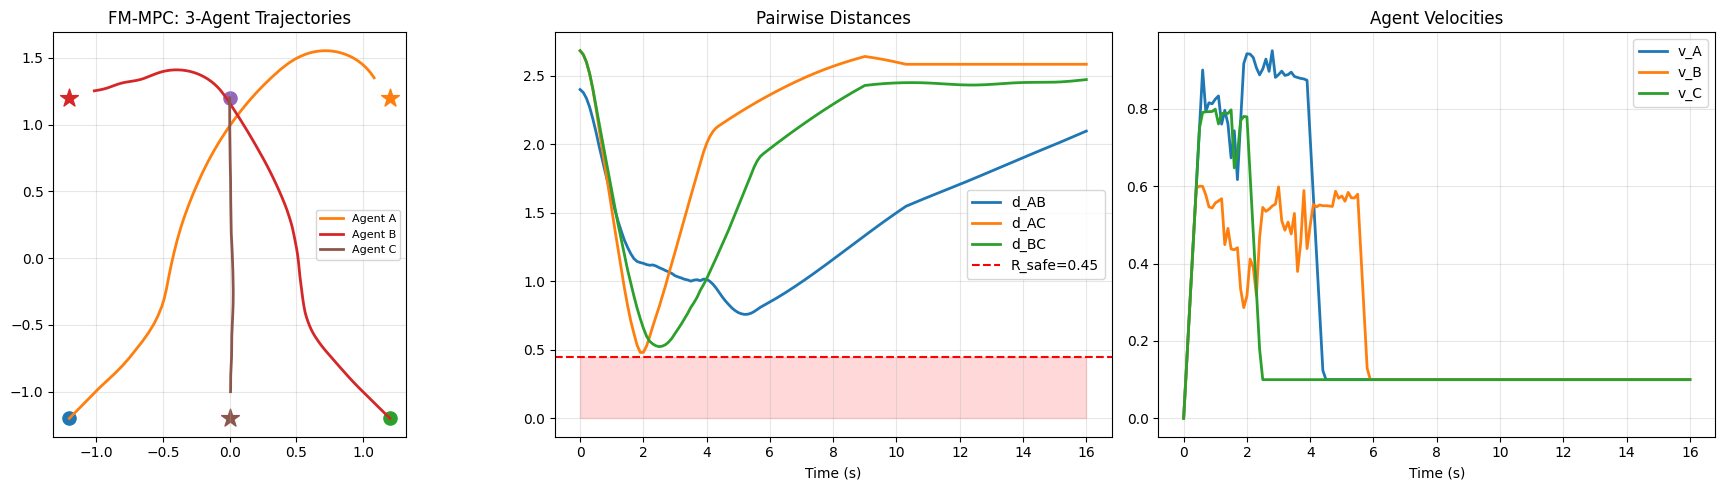

In [33]:
# ============================================================
# FM-MPC Bicycle - 三车实验（修复路径过滤版）
# ============================================================

import numpy as np, torch, math, sys, matplotlib.pyplot as plt
from pathlib import Path

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[device] {device}")

# ===============================================================
# 0) Load sampler_5h
# ===============================================================
repo_sampler = (Path.cwd().parent / "dmpc_fm_cbf" / "sampler_5h.py").resolve()
if repo_sampler.exists():
    sampler_path = repo_sampler
else:
    def find_nearest_file(filename, start, max_up=12):
        start = start.resolve()
        candidates = []
        p = start
        for _ in range(max_up):
            candidates += list(p.rglob(filename))
            p = p.parent
        if not candidates:
            raise FileNotFoundError(f"{filename} not found from {start}")
        return sorted(candidates, key=lambda x: len(str(x)))[0]
    sampler_path = find_nearest_file("sampler_5h.py", Path.cwd())

print(f"[sampler] {sampler_path}")

import importlib.util, inspect
spec = importlib.util.spec_from_file_location("sampler_5h", sampler_path)
sampler_mod = importlib.util.module_from_spec(spec)
sys.modules["sampler_5h"] = sampler_mod
spec.loader.exec_module(sampler_mod)

piecewise_sample_fm_5ch_with_cbf = sampler_mod.piecewise_sample_fm_5ch_with_cbf
sampler_sig = inspect.signature(piecewise_sample_fm_5ch_with_cbf)
assert "cond" in sampler_sig.parameters
print("[sampler] loaded")

# ===============================================================
# 1) Model check
# ===============================================================
if "model_5ch" not in dir():
    try:
        model_5ch = globals()["model_5ch"]
    except KeyError:
        raise RuntimeError("model_5ch must be loaded before running this cell!")

model_5ch = model_5ch.to(device).eval()
print("[model] loaded")

# ===============================================================
# 2) Parameters
# ===============================================================
dt_exec = 0.10

T_steps      = 40
num_segments = 5
total_time   = 1.0
ode_method   = "euler"
noise_scale  = 0.08

H            = 12
K            = 8
REPLAN_EVERY = 1
MAX_STEPS    = 300

goal_tol      = 0.20
ARRIVAL_DIST  = 0.15
APPROACH_DIST = 0.60
creep_radius  = 0.90
v_creep       = 0.10

R_SAFE = 0.45

# ★ 放宽过滤条件，适配三车 CBF 绕行
PATH_HEADING_TOL = np.deg2rad(90.0)  # 原60°→90°
PATH_START_TOL   = 0.40              # 原0.30→0.40

# ===============================================================
# 3) Bicycle dynamics
# ===============================================================
v_max_A        = 1.0
v_max_B        = 0.6
v_max_C        = 0.8
v_min          = 0.0
a_max          = 1.5
L              = 0.30
delta_max      = np.deg2rad(35.0)
delta_rate_max = np.deg2rad(90.0)
v_floor        = 0.05

def wrap_pi(th):
    return (th + np.pi) % (2*np.pi) - np.pi

def bicycle_step(s, u, *, dt, v_max):
    x, y, th, v, delta = s
    a      = float(np.clip(u[0], -a_max, a_max))
    dr     = float(np.clip(u[1], -delta_rate_max, delta_rate_max))
    v2     = float(np.clip(v + dt * a, v_min, v_max))
    if v2 < v_floor and a > 0.02:
        v2 = v_floor
    delta2 = float(np.clip(delta + dt * dr, -delta_max, delta_max))
    th2    = wrap_pi(th + dt * (v2 / L) * math.tan(delta2))
    x2     = x + dt * v2 * math.cos(th2)
    y2     = y + dt * v2 * math.sin(th2)
    return np.array([x2, y2, th2, v2, delta2], dtype=np.float32)

def rollout_bicycle(s0, U, *, dt, v_max):
    Hh = U.shape[0]
    st  = np.zeros((Hh+1, 5), dtype=np.float32)
    st[0] = s0
    for i in range(Hh):
        st[i+1] = bicycle_step(st[i], U[i], dt=dt, v_max=v_max)
    return st[:, :2], st

# ===============================================================
# 4) Canonical frame
# ===============================================================
def build_canonical_frame(start_xy, goal_xy):
    start = np.asarray(start_xy, np.float32).reshape(2)
    goal  = np.asarray(goal_xy,  np.float32).reshape(2)
    d     = goal - start
    dist  = float(np.linalg.norm(d) + 1e-9)
    c, s  = float(d[0]/dist), float(d[1]/dist)
    R_wc  = np.array([[c, s], [-s, c]], dtype=np.float32)
    R_cw  = R_wc.T

    def w2c(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return ((xy - start) @ R_wc.T).astype(np.float32)

    def c2w(xy):
        xy = np.asarray(xy, np.float32).reshape(-1, 2)
        return (xy @ R_cw.T + start).astype(np.float32)

    def w2c_angle(th_w):
        return wrap_pi(th_w - math.atan2(s, c))

    return {
        "w2c": w2c, "c2w": c2w, "w2c_angle": w2c_angle,
        "start_can": np.array([0.0, 0.0], np.float32),
        "goal_can":  np.array([dist, 0.0], np.float32),
        "dist": dist,
    }

# ===============================================================
# 5) CBF settings
# ===============================================================
r_obs_far  = 0.32
r_obs_near = 0.38
SAFE_DIST_FAR  = 2.0
SAFE_DIST_NEAR = 1.0
CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
CBF_STRONG = dict(passes=5, extra_margin=0.3,  alpha=20.0, max_corr_norm=3.0)

def get_cbf_config(min_dist):
    if min_dist > SAFE_DIST_FAR:
        return False, None
    elif min_dist > SAFE_DIST_NEAR:
        return True, CBF_LIGHT
    else:
        return True, CBF_STRONG

# ===============================================================
# 6) Other-agent prediction
# ===============================================================
def predict_other_traj(other_state, other_u_last, *, H, dt, v_max):
    if other_u_last is None:
        other_u_last = np.zeros(2, np.float32)
    U = np.tile(np.asarray(other_u_last, np.float32).reshape(1, 2), (H, 1))
    pos, st = rollout_bicycle(other_state, U, dt=dt, v_max=v_max)
    return pos, st

def build_time_expanded_ellipses_multi(tf, others_pred_list):
    """others_pred_list: [(pred_pos, dist_to_self), ...]"""
    ellipses  = []
    idxs_base = [0, 1, 2, 4, 6, 8, 10]
    for pred_pos, dist_AB in others_pred_list:
        if pred_pos is None or len(pred_pos) < 2:
            continue
        idxs = idxs_base + [len(pred_pos)-1]
        idxs = sorted(list(dict.fromkeys(
            [i for i in idxs if 0 <= i < len(pred_pos)]
        )))
        r = r_obs_near if dist_AB < 1.2 else r_obs_far
        for i in idxs:
            c_can = tf["w2c"](pred_pos[i].reshape(1, 2))[0]
            ellipses.append({"center": c_can.copy(), "radius": float(r)})
    return ellipses

# ===============================================================
# 7) FM sampling
# ===============================================================
def make_x0_noise(T, seed):
    g  = torch.Generator(device=device)
    g.manual_seed(int(seed))
    x0 = torch.randn((1, 5, T), device=device, generator=g) * float(noise_scale)
    x0[:, :, 0] = 0.0
    return x0

def sample_fm_path_multi(*, self_state, goal_xy, others_pred_list, seed):
    self_xy  = self_state[:2]
    tf       = build_canonical_frame(self_xy, goal_xy)
    min_dist = min((d for _, d in others_pred_list), default=float("inf"))

    use_cbf, cbf_kwargs = get_cbf_config(min_dist)
    ellipses = build_time_expanded_ellipses_multi(tf, others_pred_list) if use_cbf else []

    x0_noise = make_x0_noise(T_steps, seed)
    v0       = float(self_state[3])
    th_can   = tf["w2c_angle"](float(self_state[2]))
    delta0   = float(self_state[4])
    cond_vec = np.array([tf["dist"], v0, np.cos(th_can), np.sin(th_can), delta0],
                         dtype=np.float32)

    x_can, _, _ = piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch, T_steps=T_steps, device=str(device),
        total_time=total_time, num_segments=num_segments, ode_method=ode_method,
        atol=1e-4, rtol=1e-4, noise_scale=noise_scale, x0_noise=x0_noise,
        cond=cond_vec,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf), scaler=None,
        ellipses=ellipses, cbf_kwargs=cbf_kwargs,
    )

    xy_can  = x_can[0:2, :].T.astype(np.float32)
    path_xy = tf["c2w"](xy_can).astype(np.float32)
    return path_xy, bool(use_cbf), min_dist

# ===============================================================
# 8) Path quality check — ★ 放宽版，适配三车 CBF 绕行
# ===============================================================
def check_path_quality(path_xy, self_state, goal_xy):
    pos = self_state[:2]
    th  = float(self_state[2])

    # 检查1：起点锁定（放宽到 0.40）
    start_err = float(np.linalg.norm(path_xy[0] - pos))
    if start_err > PATH_START_TOL:
        return False, f"start_err={start_err:.3f}"

    # 检查2：前段方向（放宽到 90°，只过滤完全反向）
    n_check = max(3, len(path_xy) // 4)
    seg_dir = path_xy[n_check-1] - path_xy[0]
    seg_len = float(np.linalg.norm(seg_dir))
    if seg_len > 0.05:
        seg_angle  = float(math.atan2(seg_dir[1], seg_dir[0]))
        angle_diff = abs(float(wrap_pi(seg_angle - th)))
        if angle_diff > PATH_HEADING_TOL:
            return False, f"heading_diff={np.rad2deg(angle_diff):.1f}deg"

    # 检查3：终点不能比起点远超 50%（放宽，允许 CBF 绕行）
    d_start = float(np.linalg.norm(pos - goal_xy))
    d_end   = float(np.linalg.norm(path_xy[-1] - goal_xy))
    if d_end > d_start * 1.5:
        return False, f"path_goes_away d_end={d_end:.2f} d_start={d_start:.2f}"

    return True, "ok"

# ===============================================================
# 9) Pure Pursuit
# ===============================================================
def _closest_index(path_xy, pos_xy):
    return int(np.argmin(np.linalg.norm(path_xy - pos_xy.reshape(1, 2), axis=1)))

def _lookahead_point(path_xy, pos_xy, *, Ld, start_idx=0):
    for i in range(start_idx, len(path_xy)):
        if float(np.linalg.norm(path_xy[i] - pos_xy)) >= Ld:
            return path_xy[i], i
    return path_xy[-1], len(path_xy)-1

def pure_pursuit_controls(s0, path_xy, goal_xy, *, H, dt, v_max):
    s, U  = s0.copy(), np.zeros((H, 2), dtype=np.float32)
    path_xy = np.asarray(path_xy, np.float32)
    goal_xy = np.asarray(goal_xy, np.float32)
    last_path_idx = 0

    for i in range(H):
        x, y, th, v, delta = s
        pos    = s[:2]
        d_goal = float(np.linalg.norm(pos - goal_xy))

        if d_goal <= ARRIVAL_DIST:
            a  = float(np.clip(-5.0 * v, -a_max, 0.0))
            dr = float(np.clip(-delta / dt, -delta_rate_max, delta_rate_max))
            U[i] = [a, dr]; s = bicycle_step(s, U[i], dt=dt, v_max=v_max); continue

        if d_goal < APPROACH_DIST:
            target = goal_xy
            v_des  = v_max * max(0.12, d_goal / APPROACH_DIST) * 0.55
        else:
            Ld = min(float(np.clip(0.55 + 0.65*v, 0.20, 1.10)), d_goal * 0.85)
            near_idx = max(_closest_index(path_xy, pos), last_path_idx)
            target, last_path_idx = _lookahead_point(path_xy, pos, Ld=Ld, start_idx=near_idx)
            v_des = v_max if d_goal >= creep_radius else float(np.clip(
                v_creep + (v_max - v_creep) * (d_goal / creep_radius), v_creep, v_max))

        dx, dy = float(target[0]-x), float(target[1]-y)
        alpha  = float(wrap_pi(math.atan2(dy, dx) - th))
        d2t    = max(1e-3, float(np.linalg.norm(target - pos)))
        kappa  = 2.0 * math.sin(alpha) / d2t
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr = float(np.clip((delta_des - delta) / dt, -delta_rate_max, delta_rate_max))
        v_des *= max(0.35, 1.0 - 0.55 * abs(delta_des) / delta_max)
        a  = float(np.clip((v_des - v) / dt, -a_max, a_max))
        U[i] = [a, dr]; s = bicycle_step(s, U[i], dt=dt, v_max=v_max)

    return U

# ===============================================================
# 10) Cost（多车版）
# ===============================================================
W_END, W_PATH, W_COLL, W_SMOOTH = 18.0, 1.5, 450.0, 0.25

def compute_cost_multi(pos_self, others_pred_pos_list, goal_xy, U):
    goal_xy = np.asarray(goal_xy, np.float32)
    d_end   = float(np.linalg.norm(pos_self[-1] - goal_xy))
    d_path  = float(np.mean(np.linalg.norm(pos_self - goal_xy.reshape(1,2), axis=1)))
    coll = 0.0
    for pos_other in others_pred_pos_list:
        M = min(len(pos_self), len(pos_other))
        if M <= 1: continue
        min_d = float(np.linalg.norm(pos_self[:M] - pos_other[:M], axis=1).min())
        viol  = max(0.0, R_SAFE - min_d)
        coll  = max(coll, viol * viol)
    dU     = np.diff(U, axis=0, prepend=U[0:1])
    smooth = float(np.mean(dU[:,0]**2 + 0.4*dU[:,1]**2))
    return W_END*d_end + W_PATH*d_path + W_COLL*coll + W_SMOOTH*smooth

# ===============================================================
# 11) MPC replan（多车版）
# ===============================================================
def mpc_replan_multi(self_state, goal_xy, others_states, others_u_last, *,
                     v_max_self, v_max_others, seed_base):
    others_pred = []
    for s_o, u_o, vm_o in zip(others_states, others_u_last, v_max_others):
        pred_pos, _ = predict_other_traj(s_o, u_o, H=H, dt=dt_exec, v_max=vm_o)
        dist = float(np.linalg.norm(self_state[:2] - s_o[:2]))
        others_pred.append((pred_pos, dist))

    best, cbf_count, reject_count = None, 0, 0

    for k in range(K):
        seed = int(seed_base + 137*k + 7919)
        try:
            path_xy, used_cbf, min_dist = sample_fm_path_multi(
                self_state=self_state, goal_xy=goal_xy,
                others_pred_list=others_pred, seed=seed
            )
        except Exception as e:
            print(f"  [WARN] FM sample failed: {e}"); continue

        valid, reason = check_path_quality(path_xy, self_state, goal_xy)
        if not valid:
            reject_count += 1; continue

        cbf_count += int(used_cbf)
        U           = pure_pursuit_controls(self_state, path_xy, goal_xy,
                                             H=H, dt=dt_exec, v_max=v_max_self)
        pos_self, _ = rollout_bicycle(self_state, U, dt=dt_exec, v_max=v_max_self)
        J           = compute_cost_multi(pos_self, [p for p,_ in others_pred], goal_xy, U)
        if best is None or J < best[0]:
            best = (J, U[0].copy(), path_xy.copy(), used_cbf)

    if best is None:
        # 保底控制
        g_arr = np.asarray(goal_xy, np.float32)
        pos, th = self_state[:2], float(self_state[2])
        d_goal  = float(np.linalg.norm(pos - g_arr))
        ang     = float(math.atan2(g_arr[1]-pos[1], g_arr[0]-pos[0]))
        alpha   = float(wrap_pi(ang - th))
        kappa   = 2.0 * math.sin(alpha) / max(0.3, d_goal)
        delta_des = float(np.clip(math.atan(L * kappa), -delta_max, delta_max))
        dr  = float(np.clip(delta_des / dt_exec, -delta_rate_max, delta_rate_max))
        a   = float(np.clip((v_creep - self_state[3]) / dt_exec, -a_max, a_max))
        return np.array([a, dr], np.float32), float("inf"), None, 0

    return best[1], best[0], best[2], cbf_count

# ===============================================================
# 12) Scenario setup
# A: 左下→右上，B: 右下→左上，C: 上→下（垂直穿越）
# ===============================================================
xA0 = np.array([-1.2, -1.2], np.float32); gA = np.array([ 1.2,  1.2], np.float32)
xB0 = np.array([ 1.2, -1.2], np.float32); gB = np.array([-1.2,  1.2], np.float32)
xC0 = np.array([ 0.0,  1.2], np.float32); gC = np.array([ 0.0, -1.2], np.float32)

sA = np.array([xA0[0], xA0[1], float(math.atan2(gA[1]-xA0[1], gA[0]-xA0[0])), 0., 0.], np.float32)
sB = np.array([xB0[0], xB0[1], float(math.atan2(gB[1]-xB0[1], gB[0]-xB0[0])), 0., 0.], np.float32)
sC = np.array([xC0[0], xC0[1], float(math.atan2(gC[1]-xC0[1], gC[0]-xC0[0])), 0., 0.], np.float32)

trajA, trajB, trajC = [sA.copy()], [sB.copy()], [sC.copy()]
uA = np.zeros(2, np.float32)
uB = np.zeros(2, np.float32)
uC = np.zeros(2, np.float32)
cbf_total = replan_count = 0

print("="*60)
print("FM-MPC Bicycle - 三车实验（放宽路径过滤版）")
print(f"PATH_HEADING_TOL={np.rad2deg(PATH_HEADING_TOL):.0f}°  PATH_START_TOL={PATH_START_TOL}")
print(f"A: {xA0}→{gA}  B: {xB0}→{gB}  C: {xC0}→{gC}")
print("="*60)

# ===============================================================
# 13) Main loop
# ===============================================================
for step in range(MAX_STEPS):
    dA = float(np.linalg.norm(sA[:2] - gA))
    dB = float(np.linalg.norm(sB[:2] - gB))
    dC = float(np.linalg.norm(sC[:2] - gC))
    doneA, doneB, doneC = dA < goal_tol, dB < goal_tol, dC < goal_tol

    if doneA and doneB and doneC:
        print(f"\n[DONE] all 3 agents reached goals at step {step} (t={step*dt_exec:.1f}s)")
        break

    if step % REPLAN_EVERY == 0:
        replan_count += 1

        if not doneA:
            uA, _, _, cbfA = mpc_replan_multi(
                sA, gA, [sB, sC], [uB, uC],
                v_max_self=v_max_A, v_max_others=[v_max_B, v_max_C],
                seed_base=1000 + step*31)
            cbf_total += cbfA
        else:
            uA = np.zeros(2, np.float32)

        if not doneB:
            uB, _, _, cbfB = mpc_replan_multi(
                sB, gB, [sA, sC], [uA, uC],
                v_max_self=v_max_B, v_max_others=[v_max_A, v_max_C],
                seed_base=2000 + step*37)
            cbf_total += cbfB
        else:
            uB = np.zeros(2, np.float32)

        if not doneC:
            uC, _, _, cbfC = mpc_replan_multi(
                sC, gC, [sA, sB], [uA, uB],
                v_max_self=v_max_C, v_max_others=[v_max_A, v_max_B],
                seed_base=3000 + step*43)
            cbf_total += cbfC
        else:
            uC = np.zeros(2, np.float32)

        if step < 10 or step % 30 == 0:
            dAB = float(np.linalg.norm(sA[:2]-sB[:2]))
            dAC = float(np.linalg.norm(sA[:2]-sC[:2]))
            dBC = float(np.linalg.norm(sB[:2]-sC[:2]))
            print(f"[{step:3d}] dA={dA:.2f} dB={dB:.2f} dC={dC:.2f} | "
                  f"d_AB={dAB:.2f} d_AC={dAC:.2f} d_BC={dBC:.2f}")

    if not doneA: sA = bicycle_step(sA, uA, dt=dt_exec, v_max=v_max_A)
    if not doneB: sB = bicycle_step(sB, uB, dt=dt_exec, v_max=v_max_B)
    if not doneC: sC = bicycle_step(sC, uC, dt=dt_exec, v_max=v_max_C)

    trajA.append(sA.copy())
    trajB.append(sB.copy())
    trajC.append(sC.copy())

trajA = np.asarray(trajA, np.float32)
trajB = np.asarray(trajB, np.float32)
trajC = np.asarray(trajC, np.float32)
print(f"\n[stats] replans={replan_count} | CBF used={cbf_total}")

# ===============================================================
# 14) Analysis & plots
# ===============================================================
dist_AB = np.linalg.norm(trajA[:,:2] - trajB[:,:2], axis=1)
dist_AC = np.linalg.norm(trajA[:,:2] - trajC[:,:2], axis=1)
dist_BC = np.linalg.norm(trajB[:,:2] - trajC[:,:2], axis=1)

coll_AB = np.where(dist_AB < R_SAFE)[0]
coll_AC = np.where(dist_AC < R_SAFE)[0]
coll_BC = np.where(dist_BC < R_SAFE)[0]

print(f"[A final] dist_to_goal={float(np.linalg.norm(trajA[-1,:2]-gA)):.4f}")
print(f"[B final] dist_to_goal={float(np.linalg.norm(trajB[-1,:2]-gB)):.4f}")
print(f"[C final] dist_to_goal={float(np.linalg.norm(trajC[-1,:2]-gC)):.4f}")
print(f"[AB] min_dist={dist_AB.min():.4f} | coll_steps={len(coll_AB)}")
print(f"[AC] min_dist={dist_AC.min():.4f} | coll_steps={len(coll_AC)}")
print(f"[BC] min_dist={dist_BC.min():.4f} | coll_steps={len(coll_BC)}")

t = np.arange(len(trajA)) * dt_exec
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
for traj, x0, g, label in [
    (trajA, xA0, gA, "Agent A"),
    (trajB, xB0, gB, "Agent B"),
    (trajC, xC0, gC, "Agent C"),
]:
    c = ax._get_lines.get_next_color()
    ax.plot(traj[:,0], traj[:,1], lw=2, label=label)
    ax.scatter(*x0, s=90,  marker="o")
    ax.scatter(*g,  s=180, marker="*")
for coll_steps in [coll_AB, coll_AC, coll_BC]:
    if len(coll_steps) > 0:
        ax.scatter(trajA[coll_steps,0], trajA[coll_steps,1],
                   s=40, marker="x", c="red", zorder=5)
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("FM-MPC: 3-Agent Trajectories")

ax2 = axes[1]
ax2.plot(t, dist_AB, lw=2, label="d_AB")
ax2.plot(t, dist_AC, lw=2, label="d_AC")
ax2.plot(t, dist_BC, lw=2, label="d_BC")
ax2.axhline(R_SAFE, ls="--", c="red", label=f"R_safe={R_SAFE}")
ax2.fill_between(t, 0, R_SAFE, alpha=0.15, color="red")
ax2.grid(alpha=0.3); ax2.legend()
ax2.set_title("Pairwise Distances"); ax2.set_xlabel("Time (s)")

ax3 = axes[2]
ax3.plot(t, trajA[:,3], lw=2, label="v_A")
ax3.plot(t, trajB[:,3], lw=2, label="v_B")
ax3.plot(t, trajC[:,3], lw=2, label="v_C")
ax3.grid(alpha=0.3); ax3.legend()
ax3.set_title("Agent Velocities"); ax3.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

[sampler] loaded | device=cuda
Running benchmark...
Methods: ['fm_cbf', 'pure_fm', 'idm', 'pdm']
Scenarios: ['lane_following', 'unprotected_left_turn']
Repeats: 5
  [FM+CBF (Ours)       ] Lane Following            | collision=0%  goal_reached=0%
  [Pure FM             ] Lane Following            | collision=0%  goal_reached=100%
  [IDM                 ] Lane Following            | collision=0%  goal_reached=100%
  [PDM-simple          ] Lane Following            | collision=0%  goal_reached=100%
  [FM+CBF (Ours)       ] Unprotected Left Turn     | collision=0%  goal_reached=100%
  [Pure FM             ] Unprotected Left Turn     | collision=0%  goal_reached=100%
  [IDM                 ] Unprotected Left Turn     | collision=0%  goal_reached=100%
  [PDM-simple          ] Unprotected Left Turn     | collision=0%  goal_reached=100%

[done]

Method                 Scenario                   Collision↓  GoalReach↑  AvgSteps↓  MinDist↑  Smooth↓
-----------------------------------------------

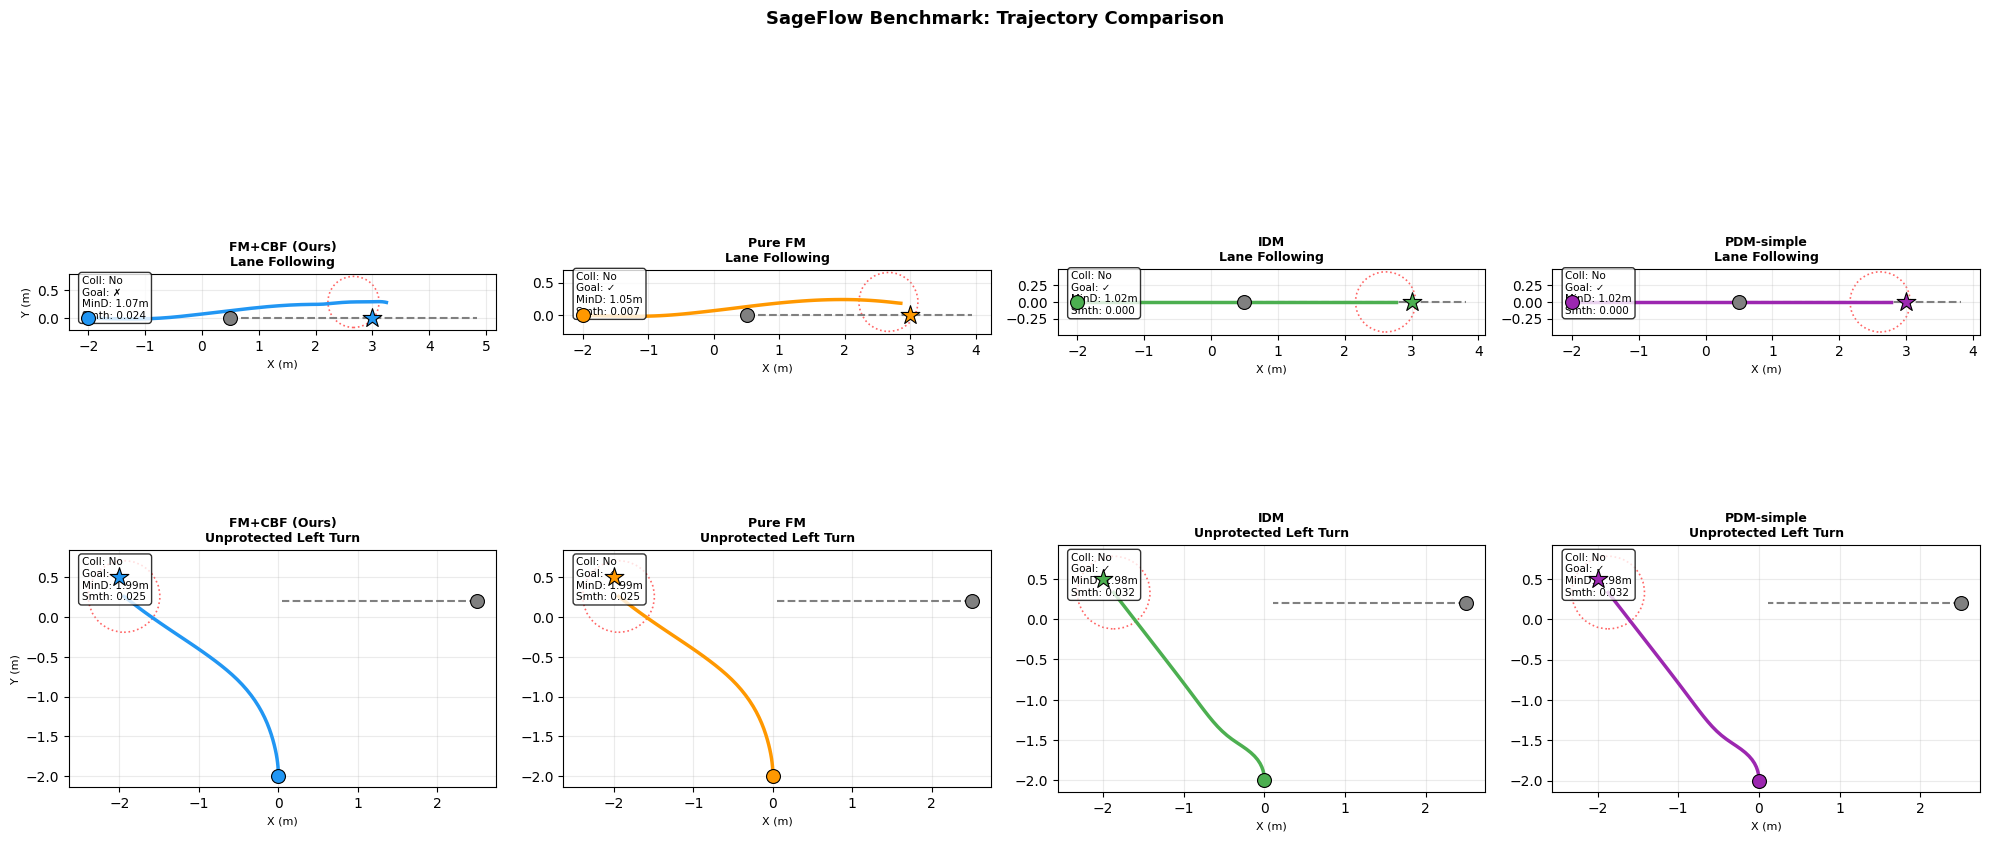

[saved] benchmark_trajectories.png


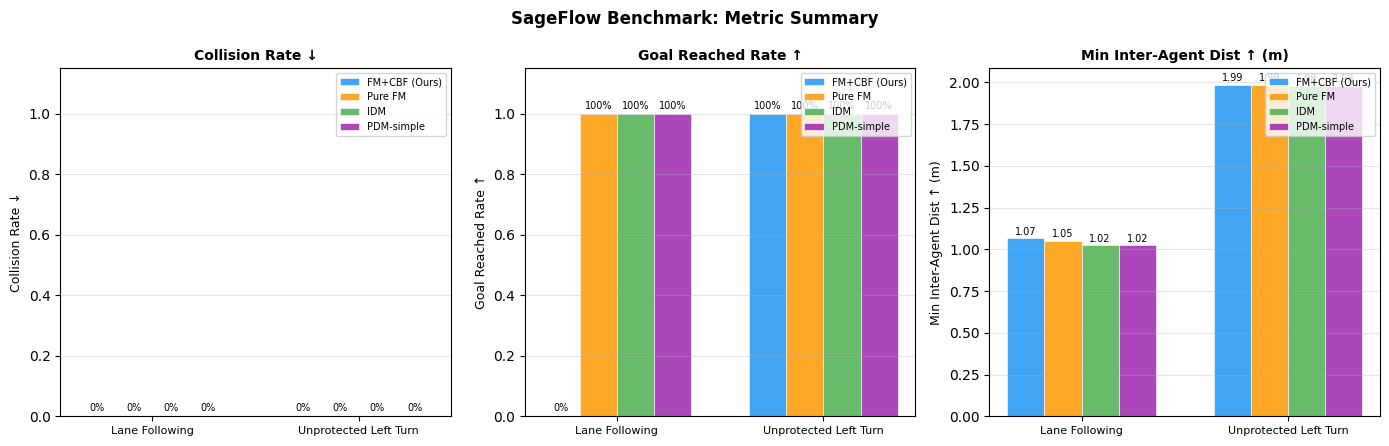

[saved] benchmark_metrics.png


In [24]:
# ============================================================
# SageFlow Benchmark
# 对比：FM+CBF | Pure FM | IDM | PDM-simple
# 场景：Lane Following | Unprotected Left Turn
# Simulator：LQR tracker + kinematic bicycle（与 nuPlan 一致）
# 前提：model_5ch 已在内存中
# ============================================================

import numpy as np
import torch
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
import warnings
warnings.filterwarnings("ignore")

torch.set_grad_enabled(False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── 确认 model_5ch 已加载 ─────────────────────────────────────
assert "model_5ch" in dir() or "model_5ch" in globals(), \
    "model_5ch must be loaded before running this cell!"
model_5ch.to(device).eval()

# ── 加载 sampler ──────────────────────────────────────────────
import importlib.util, sys
from pathlib import Path

def _load_sampler():
    try:
        from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
        return piecewise_sample_fm_5ch_with_cbf
    except ImportError:
        pass
    candidates = sorted(Path.cwd().rglob("sampler_5h.py"), key=lambda x: len(str(x)))
    if not candidates:
        raise FileNotFoundError("sampler_5h.py not found")
    spec = importlib.util.spec_from_file_location("sampler_5h", candidates[0])
    mod  = importlib.util.module_from_spec(spec)
    sys.modules["sampler_5h"] = mod
    spec.loader.exec_module(mod)
    return mod.piecewise_sample_fm_5ch_with_cbf

sample_fn = _load_sampler()
print(f"[sampler] loaded | device={device}")

# ============================================================
# 1. 车辆参数 & 基础工具
# ============================================================
WB       = 0.30          # wheelbase (m)
DT       = 0.10          # simulation timestep (s)  10 Hz，与 nuPlan 一致
V_MAX_A  = 1.0           # ego max speed
V_MAX_B  = 0.6           # other agent max speed
A_MAX    = 1.5
D_MAX    = np.deg2rad(35.0)
DR_MAX   = np.deg2rad(90.0)
R_SAFE   = 0.45          # collision radius

def wrap_pi(th):
    return float((th + math.pi) % (2*math.pi) - math.pi)

def bicycle_step(s, u, dt=DT, v_max=V_MAX_A):
    x, y, th, v, delta = s
    a  = float(np.clip(u[0], -A_MAX, A_MAX))
    dr = float(np.clip(u[1], -DR_MAX, DR_MAX))
    v2 = float(np.clip(v + dt*a, 0.0, v_max))
    d2 = float(np.clip(delta + dt*dr, -D_MAX, D_MAX))
    th2 = wrap_pi(th + dt*(v2/WB)*math.tan(d2))
    x2  = x + dt*v2*math.cos(th2)
    y2  = y + dt*v2*math.sin(th2)
    return np.array([x2, y2, th2, v2, d2], np.float32)

# ============================================================
# 2. LQR Tracker（与 nuPlan 一致的两阶段 pipeline）
# ============================================================
# 状态误差：[lateral_err, heading_err, velocity_err]
# 控制量：  [acceleration, steering_rate]
# Q, R 取 nuPlan 默认参数风格

_Q = np.diag([10.0, 10.0, 1.0]).astype(np.float64)   # 状态代价
_R = np.diag([1.0,  1.0]).astype(np.float64)          # 控制代价

def _solve_dare(A, B, Q, R):
    """离散代数 Riccati 方程迭代求解（有限步近似）。"""
    P = Q.copy()
    for _ in range(200):
        P_new = (A.T @ P @ A
                 - A.T @ P @ B @ np.linalg.inv(R + B.T @ P @ B) @ B.T @ P @ A
                 + Q)
        if np.max(np.abs(P_new - P)) < 1e-8:
            break
        P = P_new
    return P

def _build_lqr_gain(v_ref: float) -> np.ndarray:
    """
    线性化 kinematic bicycle 模型在参考速度 v_ref 处，
    计算 LQR 增益 K (2×3)。
    状态: [e_lat, e_heading, e_v]
    控制: [a, delta_rate]
    """
    v = max(v_ref, 0.1)
    # 连续时间线性化后离散化 (Euler, dt=DT)
    A_c = np.array([
        [0., v,  0.],
        [0., 0., 0.],
        [0., 0., 0.],
    ], np.float64)
    B_c = np.array([
        [0.,   0.],
        [0.,   v/WB],
        [1.,   0.],
    ], np.float64)
    A_d = np.eye(3) + DT * A_c
    B_d = DT * B_c

    P = _solve_dare(A_d, B_d, _Q, _R)
    K = np.linalg.inv(_R + B_d.T @ P @ B_d) @ B_d.T @ P @ A_d
    return K   # (2, 3)

# 预计算几个速度档的增益（避免每步都解 DARE）
_LQR_CACHE = {v: _build_lqr_gain(v) for v in [0.1, 0.3, 0.5, 0.7, 1.0]}

def _get_lqr_gain(v):
    keys = sorted(_LQR_CACHE.keys())
    best = keys[np.argmin([abs(v - k) for k in keys])]
    return _LQR_CACHE[best]

def lqr_control(state: np.ndarray,
                ref_path: np.ndarray,
                goal_xy: np.ndarray,
                v_max: float = V_MAX_A) -> np.ndarray:
    """
    LQR tracker：给定当前状态和参考路径，输出 [a, delta_rate]。

    Parameters
    ----------
    state    : [x, y, theta, v, delta]
    ref_path : (N, 2) world XY reference
    goal_xy  : (2,) goal position
    """
    x, y, th, v, delta = state
    pos = np.array([x, y])

    d_goal = float(np.linalg.norm(pos - goal_xy))

    # ── 找 lookahead 点 ───────────────────────────────────────
    Ld = float(np.clip(0.4 + 0.5*v, 0.2, 1.0))
    Ld = min(Ld, d_goal * 0.9)

    dists = np.linalg.norm(ref_path - pos, axis=1)
    near  = int(np.argmin(dists))
    target = ref_path[-1]
    for i in range(near, len(ref_path)):
        if float(np.linalg.norm(ref_path[i] - pos)) >= Ld:
            target = ref_path[i]
            break

    # ── 参考速度 ──────────────────────────────────────────────
    if d_goal < 0.5:
        v_ref = 0.0
    elif d_goal < 1.0:
        v_ref = v_max * (d_goal / 1.0) * 0.5
    else:
        v_ref = v_max

    # ── 误差计算 ──────────────────────────────────────────────
    dx, dy    = target[0]-x, target[1]-y
    th_ref    = math.atan2(dy, dx)
    e_heading = wrap_pi(th_ref - th)

    # lateral error: signed distance from ego to ref path line
    if len(ref_path) > 1:
        seg   = ref_path[min(near+1, len(ref_path)-1)] - ref_path[near]
        seg_l = float(np.linalg.norm(seg) + 1e-9)
        seg_n = np.array([-seg[1], seg[0]]) / seg_l   # normal
        e_lat = float(np.dot(pos - ref_path[near], seg_n))
    else:
        e_lat = 0.0

    e_v = v_ref - v
    err = np.array([e_lat, e_heading, e_v], np.float64)

    # ── LQR 增益 ─────────────────────────────────────────────
    K = _get_lqr_gain(max(v, 0.1))
    u = K @ err   # [a, delta_rate]

    # ── 参考转向角 → 转向速率 ─────────────────────────────────
    dist_t  = max(1e-3, float(np.linalg.norm(target - pos)))
    kappa   = 2.0 * math.sin(e_heading) / dist_t
    d_ref   = float(np.clip(math.atan(WB * kappa), -D_MAX, D_MAX))
    dr_ref  = float(np.clip((d_ref - delta) / DT, -DR_MAX, DR_MAX))

    # 融合 LQR 输出和参考转向
    a_out  = float(np.clip(u[0], -A_MAX, A_MAX))
    dr_out = float(np.clip(u[1] + 0.5*dr_ref, -DR_MAX, DR_MAX))

    return np.array([a_out, dr_out], np.float32)

# ============================================================
# 3. FM sampler 工具（canonical frame）
# ============================================================
def _canonical_frame(start_xy, goal_xy):
    s = np.asarray(start_xy, np.float32).reshape(2)
    g = np.asarray(goal_xy,  np.float32).reshape(2)
    d = g - s
    dist = float(np.linalg.norm(d) + 1e-9)
    c, sv = d[0]/dist, d[1]/dist
    R_wc  = np.array([[c, sv], [-sv, c]], np.float32)
    R_cw  = R_wc.T
    ga    = math.atan2(float(sv), float(c))
    def w2c(xy):
        return ((np.asarray(xy,np.float32).reshape(-1,2)-s) @ R_wc.T).astype(np.float32)
    def c2w(xy):
        return (np.asarray(xy,np.float32).reshape(-1,2) @ R_cw.T + s).astype(np.float32)
    return {"w2c":w2c, "c2w":c2w,
            "w2c_angle": lambda th_w: wrap_pi(th_w - ga),
            "start_can": np.array([0.,0.],np.float32),
            "goal_can":  np.array([dist,0.],np.float32),
            "dist": dist}

_CBF_LIGHT  = dict(passes=2, extra_margin=0.08, alpha=10.0, max_corr_norm=2.0)
_CBF_STRONG = dict(passes=5, extra_margin=0.30, alpha=20.0, max_corr_norm=3.0)

def _fm_sample_path(self_state, goal_xy, other_xy, *,
                    use_cbf=True, seed=0):
    pos = self_state[:2]
    tf  = _canonical_frame(pos, goal_xy)
    th_can   = tf["w2c_angle"](float(self_state[2]))
    cond_vec = np.array([tf["dist"], float(self_state[3]),
                         math.cos(th_can), math.sin(th_can),
                         float(self_state[4])], np.float32)

    # ellipses
    ellipses = []
    cbf_kw   = {}
    if use_cbf and other_xy is not None:
        d = float(np.linalg.norm(pos - other_xy))
        if d < 2.0:
            r      = 0.38 if d < 1.2 else 0.32
            c_can  = tf["w2c"](other_xy.reshape(1,2))[0]
            ellipses = [{"center": c_can, "radius": r}]
            cbf_kw = _CBF_STRONG if d < 1.0 else _CBF_LIGHT

    torch.manual_seed(seed)
    x0 = torch.randn((1,5,40), device=device) * 0.08
    x0[:,:,0] = 0.

    x_fm, _, _ = sample_fn(
        model_5ch=model_5ch, T_steps=40, device=str(device),
        total_time=1.0, num_segments=5, ode_method="euler",
        atol=1e-4, rtol=1e-4, noise_scale=0.08, x0_noise=x0,
        cond=cond_vec,
        start_xy_norm=tf["start_can"], goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55, goal_guidance_weight=0.95,
        goal_guidance_mode="tail", lock_start=True,
        use_cbf=bool(use_cbf and len(ellipses)>0),
        scaler=None, ellipses=ellipses,
        cbf_kwargs=cbf_kw if ellipses else None,
    )
    xy_can = x_fm[0:2,:].T.astype(np.float32)
    return tf["c2w"](xy_can)   # (40, 2) world XY

def fm_plan(self_state, goal_xy, other_xy, *, use_cbf=True,
            K=6, seed_base=0):
    """K 候选路径，选 cost 最低的。"""
    best_path, best_cost = None, float("inf")
    for k in range(K):
        try:
            path = _fm_sample_path(self_state, goal_xy, other_xy,
                                   use_cbf=use_cbf, seed=seed_base+k*137)
        except Exception:
            continue
        d_end  = float(np.linalg.norm(path[-1] - goal_xy))
        d_mean = float(np.mean(np.linalg.norm(path - goal_xy, axis=1)))
        coll   = 0.0
        if other_xy is not None:
            viol = max(0., R_SAFE - float(
                np.linalg.norm(path - other_xy.reshape(1,2), axis=1).min()))
            coll = viol**2 * 450.
        cost = 18.*d_end + 1.5*d_mean + coll
        if cost < best_cost:
            best_cost = cost
            best_path = path
    return best_path

# ============================================================
# 4. IDM planner（规则based，纵向跟车）
# ============================================================
IDM_V0   = 1.0    # desired speed
IDM_T    = 1.5    # time headway
IDM_A    = 1.0    # max accel
IDM_B    = 1.5    # comfortable decel
IDM_S0   = 0.3    # min gap
IDM_DELTA= 4.0    # accel exponent

def idm_accel(v, v_lead, gap):
    """Standard IDM acceleration."""
    s_star = IDM_S0 + max(0., v*IDM_T
                          + v*(v-v_lead) / (2.*math.sqrt(IDM_A*IDM_B)))
    a = IDM_A * (1. - (v/max(IDM_V0,1e-3))**IDM_DELTA
                 - (s_star/max(gap,1e-3))**2)
    return float(np.clip(a, -IDM_B*2, IDM_A))

def idm_plan(self_state, goal_xy, other_state, *, n_pts=40):
    """
    IDM：沿直线朝 goal 走，纵向速度由 IDM 控制。
    如果前方有 other agent，保持安全车距。
    """
    pos   = self_state[:2]
    th    = float(self_state[2])
    v     = float(self_state[3])
    d_goal= float(np.linalg.norm(pos - goal_xy))
    ang   = float(math.atan2(goal_xy[1]-pos[1], goal_xy[0]-pos[0]))

    # 判断 other 是否在前方
    gap = 999.
    v_lead = IDM_V0
    if other_state is not None:
        o_pos  = other_state[:2]
        rel    = o_pos - pos
        ahead  = float(np.dot(rel, [math.cos(ang), math.sin(ang)]))
        if ahead > 0:
            gap    = max(0., float(np.linalg.norm(rel)) - R_SAFE*2)
            v_lead = float(other_state[3])

    # 生成参考路径：沿当前朝向直线
    path = []
    cur  = pos.copy()
    cur_v = v
    for _ in range(n_pts):
        a   = idm_accel(cur_v, v_lead, gap)
        cur_v = float(np.clip(cur_v + DT*a, 0., IDM_V0))
        cur   = cur + DT * cur_v * np.array([math.cos(ang), math.sin(ang)])
        path.append(cur.copy())
        gap   = max(0., gap - DT*cur_v)
    return np.array(path, np.float32)

# ============================================================
# 5. PDM-simple（沿直线中心线，带简单减速避障）
# ============================================================
def pdm_plan(self_state, goal_xy, other_state, *, n_pts=40):
    """
    PDM-Closed 简化版：
    - 沿 ego→goal 直线（类比 road centerline）匀速行驶
    - 检测到前方障碍物时提前减速
    """
    pos  = self_state[:2]
    v    = float(self_state[3])
    ang  = float(math.atan2(goal_xy[1]-pos[1], goal_xy[0]-pos[0]))
    step = DT * V_MAX_A

    path = []
    cur  = pos.copy()
    for i in range(n_pts):
        # 减速区：距离障碍物 < 1.5 m
        v_des = V_MAX_A
        if other_state is not None:
            o_pos = other_state[:2]
            d_obs = float(np.linalg.norm(cur - o_pos))
            if d_obs < 1.5:
                v_des = V_MAX_A * max(0., (d_obs - R_SAFE) / (1.5 - R_SAFE))
        # 距目标减速
        d_goal = float(np.linalg.norm(cur - goal_xy))
        if d_goal < 0.8:
            v_des = min(v_des, V_MAX_A * d_goal / 0.8)
        cur = cur + DT * v_des * np.array([math.cos(ang), math.sin(ang)])
        path.append(cur.copy())
    return np.array(path, np.float32)

# ============================================================
# 6. Metrics
# ============================================================
@dataclass
class EpisodeResult:
    method:      str
    scenario:    str
    collision:   bool          # 是否发生碰撞
    goal_reached:bool          # 是否到达目标
    steps:       int           # 总步数
    min_dist:    float         # 全程最小 inter-agent 距离
    smoothness:  float         # 轨迹曲率变化均值（越小越平滑）
    traj_A:      np.ndarray = field(repr=False, default=None)
    traj_B:      np.ndarray = field(repr=False, default=None)

def compute_smoothness(traj_xy: np.ndarray) -> float:
    """轨迹方向变化率均值（rad/step）。"""
    if len(traj_xy) < 3:
        return 0.0
    dx = np.diff(traj_xy[:,0])
    dy = np.diff(traj_xy[:,1])
    angles = np.arctan2(dy, dx)
    dangle = np.abs(np.diff(np.unwrap(angles)))
    return float(np.mean(dangle))

# ============================================================
# 7. Scenario definitions
# ============================================================
def make_lane_following_scenario():
    """
    Lane Following：
    Agent A（ego）从后方跟随 Agent B（前车）。
    A 目标：到达前方 goal_A。
    B 匀速直行。
    """
    sA = np.array([-2.0, 0.0, 0.0,  0.0, 0.0], np.float32)  # ego, facing +x
    sB = np.array([ 0.5, 0.0, 0.0,  0.3, 0.0], np.float32)  # front car
    gA = np.array([ 3.0, 0.0], np.float32)
    gB = np.array([ 5.0, 0.0], np.float32)
    return sA, sB, gA, gB

def make_left_turn_scenario():
    """
    Unprotected Left Turn：
    Agent A（ego）从南向北，需要左转向西。
    Agent B 从东向西直行（对向来车）。
    交叉点在原点附近。
    """
    sA = np.array([ 0.0, -2.0,  math.pi/2,  0.0, 0.0], np.float32)  # facing north
    sB = np.array([ 2.5,  0.2, math.pi,      0.4, 0.0], np.float32)  # facing west
    gA = np.array([-2.0,  0.5], np.float32)   # A turns left → west
    gB = np.array([-2.5,  0.2], np.float32)   # B goes straight west
    return sA, sB, gA, gB

SCENARIOS = {
    "lane_following":      make_lane_following_scenario,
    "unprotected_left_turn": make_left_turn_scenario,
}

# ============================================================
# 8. Simulation loop
# ============================================================
MAX_STEPS  = 200
GOAL_TOL   = 0.25
REPLAN_EVERY = 1   # 每步都 replan（与 nuPlan 10Hz 一致）

def run_episode(method: str, scenario: str,
                n_repeat: int = 1) -> List[EpisodeResult]:
    """
    运行一个 (method, scenario) 组合，重复 n_repeat 次（不同随机种子）。
    """
    results = []
    for repeat in range(n_repeat):
        sA0, sB0, gA, gB = SCENARIOS[scenario]()
        sA, sB = sA0.copy(), sB0.copy()
        uA = np.zeros(2, np.float32)
        uB = np.zeros(2, np.float32)

        traj_A = [sA[:2].copy()]
        traj_B = [sB[:2].copy()]
        collision   = False
        goal_reached= False
        path_cache  = None

        for step in range(MAX_STEPS):
            dA = float(np.linalg.norm(sA[:2] - gA))
            dB = float(np.linalg.norm(sB[:2] - gB))
            if dA < GOAL_TOL:
                goal_reached = True
                break

            # ── plan for A ────────────────────────────────────
            seed = repeat * 10000 + step * 31
            if step % REPLAN_EVERY == 0:
                if method == "fm_cbf":
                    path_cache = fm_plan(sA, gA, sB[:2],
                                         use_cbf=True, K=6, seed_base=seed)
                elif method == "pure_fm":
                    path_cache = fm_plan(sA, gA, sB[:2],
                                         use_cbf=False, K=6, seed_base=seed)
                elif method == "idm":
                    path_cache = idm_plan(sA, gA, sB)
                elif method == "pdm":
                    path_cache = pdm_plan(sA, gA, sB)

            # ── LQR tracker → bicycle_step ────────────────────
            if path_cache is not None and len(path_cache) > 1:
                uA = lqr_control(sA, path_cache, gA, v_max=V_MAX_A)
            else:
                uA = np.zeros(2, np.float32)

            # ── B 简单跟自己的 PDM 路径（匀速直行） ──────────────
            path_B = pdm_plan(sB, gB, None)
            uB = lqr_control(sB, path_B, gB, v_max=V_MAX_B)

            # ── 更新状态 ──────────────────────────────────────
            sA = bicycle_step(sA, uA, dt=DT, v_max=V_MAX_A)
            sB = bicycle_step(sB, uB, dt=DT, v_max=V_MAX_B)
            traj_A.append(sA[:2].copy())
            traj_B.append(sB[:2].copy())

            # ── 碰撞检测 ─────────────────────────────────────
            d_AB = float(np.linalg.norm(sA[:2] - sB[:2]))
            if d_AB < R_SAFE:
                collision = True
                break

        traj_A = np.array(traj_A, np.float32)
        traj_B = np.array(traj_B, np.float32)
        min_d  = float(np.linalg.norm(traj_A - traj_B[:len(traj_A)], axis=1).min())
        smooth = compute_smoothness(traj_A)

        results.append(EpisodeResult(
            method=method, scenario=scenario,
            collision=collision, goal_reached=goal_reached,
            steps=len(traj_A)-1, min_dist=min_d, smoothness=smooth,
            traj_A=traj_A, traj_B=traj_B,
        ))
    return results

# ============================================================
# 9. Run all experiments
# ============================================================
METHODS   = ["fm_cbf", "pure_fm", "idm", "pdm"]
N_REPEAT  = 5    # 每个组合重复5次（不同随机种子）

METHOD_LABELS = {
    "fm_cbf":   "FM+CBF (Ours)",
    "pure_fm":  "Pure FM",
    "idm":      "IDM",
    "pdm":      "PDM-simple",
}
SCENARIO_LABELS = {
    "lane_following":        "Lane Following",
    "unprotected_left_turn": "Unprotected Left Turn",
}

print("="*60)
print("Running benchmark...")
print(f"Methods: {METHODS}")
print(f"Scenarios: {list(SCENARIOS.keys())}")
print(f"Repeats: {N_REPEAT}")
print("="*60)

all_results: dict = defaultdict(list)   # (method, scenario) → List[EpisodeResult]

for scenario in SCENARIOS:
    for method in METHODS:
        key = (method, scenario)
        eps = run_episode(method, scenario, n_repeat=N_REPEAT)
        all_results[key].extend(eps)
        cr = np.mean([r.collision    for r in eps])
        gr = np.mean([r.goal_reached for r in eps])
        print(f"  [{METHOD_LABELS[method]:20s}] {SCENARIO_LABELS[scenario]:25s} "
              f"| collision={cr:.0%}  goal_reached={gr:.0%}")

print("\n[done]")

# ============================================================
# 10. Metrics table
# ============================================================
print("\n" + "="*80)
print(f"{'Method':<22} {'Scenario':<26} {'Collision↓':>10} "
      f"{'GoalReach↑':>11} {'AvgSteps↓':>10} {'MinDist↑':>9} {'Smooth↓':>8}")
print("-"*80)

table_data = {}
for scenario in SCENARIOS:
    for method in METHODS:
        eps  = all_results[(method, scenario)]
        cr   = np.mean([r.collision    for r in eps])
        gr   = np.mean([r.goal_reached for r in eps])
        st   = np.mean([r.steps        for r in eps])
        md   = np.mean([r.min_dist     for r in eps])
        sm   = np.mean([r.smoothness   for r in eps])
        table_data[(method, scenario)] = dict(
            collision=cr, goal_reached=gr, steps=st,
            min_dist=md, smoothness=sm
        )
        print(f"  {METHOD_LABELS[method]:<20} {SCENARIO_LABELS[scenario]:<26} "
              f"  {cr:>8.1%}  {gr:>9.1%}  {st:>9.1f}  {md:>8.3f}  {sm:>7.4f}")
    print()

# ============================================================
# 11. Visualization
# ============================================================
fig, axes = plt.subplots(
    len(SCENARIOS), len(METHODS),
    figsize=(5*len(METHODS), 4.5*len(SCENARIOS))
)
if len(SCENARIOS) == 1:
    axes = axes[np.newaxis, :]

COLORS = {
    "fm_cbf":  "#2196F3",
    "pure_fm": "#FF9800",
    "idm":     "#4CAF50",
    "pdm":     "#9C27B0",
}

for si, scenario in enumerate(SCENARIOS):
    for mi, method in enumerate(METHODS):
        ax = axes[si, mi]

        # 取第1次 repeat 的轨迹
        ep = all_results[(method, scenario)][0]
        tA, tB = ep.traj_A, ep.traj_B

        ax.plot(tB[:,0], tB[:,1], color="gray",  lw=1.5,
                linestyle="--", label="Agent B", zorder=2)
        ax.plot(tA[:,0], tA[:,1], color=COLORS[method], lw=2.5,
                label="Agent A (ego)", zorder=3)

        # start / goal markers
        sA0, sB0, gA, gB = SCENARIOS[scenario]()
        ax.scatter(*sA0[:2], s=100, marker="o",
                   color=COLORS[method], zorder=5, edgecolors="k", linewidths=0.8)
        ax.scatter(*gA,      s=200, marker="*",
                   color=COLORS[method], zorder=5, edgecolors="k", linewidths=0.8)
        ax.scatter(*sB0[:2], s=100, marker="o",
                   color="gray", zorder=5, edgecolors="k", linewidths=0.8)

        # collision marker
        if ep.collision:
            ax.scatter(tA[-1,0], tA[-1,1], s=200, marker="X",
                       color="red", zorder=6, label="Collision")

        # safety circle at closest approach
        dists   = np.linalg.norm(tA - tB[:len(tA)], axis=1)
        min_idx = int(np.argmin(dists))
        circle  = plt.Circle(tA[min_idx], R_SAFE, color="red",
                              fill=False, linestyle=":", lw=1.2, alpha=0.6)
        ax.add_patch(circle)

        # metrics annotation
        m = table_data[(method, scenario)]
        info = (f"Coll: {'Yes' if ep.collision else 'No'}\n"
                f"Goal: {'✓' if ep.goal_reached else '✗'}\n"
                f"MinD: {m['min_dist']:.2f}m\n"
                f"Smth: {m['smoothness']:.3f}")
        ax.text(0.03, 0.97, info, transform=ax.transAxes,
                fontsize=7.5, va="top", ha="left",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

        ax.set_aspect("equal")
        ax.grid(alpha=0.25)
        ax.set_title(f"{METHOD_LABELS[method]}\n{SCENARIO_LABELS[scenario]}",
                     fontsize=9, fontweight="bold")
        if mi == 0:
            ax.set_ylabel("Y (m)", fontsize=8)
        ax.set_xlabel("X (m)", fontsize=8)

plt.suptitle("SageFlow Benchmark: Trajectory Comparison",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("benchmark_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] benchmark_trajectories.png")

# ============================================================
# 12. Summary bar chart
# ============================================================
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.5))

metrics_to_plot = [
    ("collision",    "Collision Rate ↓",     False),
    ("goal_reached", "Goal Reached Rate ↑",  True),
    ("min_dist",     "Min Inter-Agent Dist ↑ (m)", True),
]

sc_names  = [SCENARIO_LABELS[s] for s in SCENARIOS]
bar_width = 0.18
x_base    = np.arange(len(SCENARIOS))

for ai, (metric, ylabel, higher_better) in enumerate(metrics_to_plot):
    ax = axes2[ai]
    for mi, method in enumerate(METHODS):
        vals = [table_data[(method, s)][metric] for s in SCENARIOS]
        offset = (mi - len(METHODS)/2 + 0.5) * bar_width
        bars = ax.bar(x_base + offset, vals, bar_width,
                      label=METHOD_LABELS[method],
                      color=COLORS[method], alpha=0.85,
                      edgecolor="white", linewidth=0.5)
        # value labels
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.01,
                    f"{val:.2f}" if metric=="min_dist" else f"{val:.0%}",
                    ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x_base)
    ax.set_xticklabels(sc_names, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(ylabel, fontsize=10, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    if metric in ("collision", "goal_reached"):
        ax.set_ylim(0, 1.15)

plt.suptitle("SageFlow Benchmark: Metric Summary",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("benchmark_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("[saved] benchmark_metrics.png")

[OK] model on cuda:0
Running benchmark...
  [FM+CBF (Ours)  ] (a) Lane Change ....  coll=0% goal=100%
  [Pure FM        ] (a) Lane Change ....  coll=0% goal=100%
  [IDM            ] (a) Lane Change ....  coll=0% goal=100%
  [PDM-simple     ] (a) Lane Change ....  coll=0% goal=100%
  [FM+CBF (Ours)  ] (b) Unprotected Left Turn ....  coll=100% goal=0%
  [Pure FM        ] (b) Unprotected Left Turn ....  coll=100% goal=0%
  [IDM            ] (b) Unprotected Left Turn ....  coll=95% goal=0%
  [PDM-simple     ] (b) Unprotected Left Turn ....  coll=100% goal=0%

Method          Scenario                     Safety%   Goal%  MinDist    Jerk  Steps
------------------------------------------------------------------------------
  FM+CBF (Ours)  (a) Lane Change              100.0%   100.0%    0.429  0.0891   50.4
  Pure FM        (a) Lane Change              100.0%   100.0%    0.429  0.0891   50.4
  IDM            (a) Lane Change              100.0%   100.0%    0.449  0.3805   50.4
  PDM-simple    

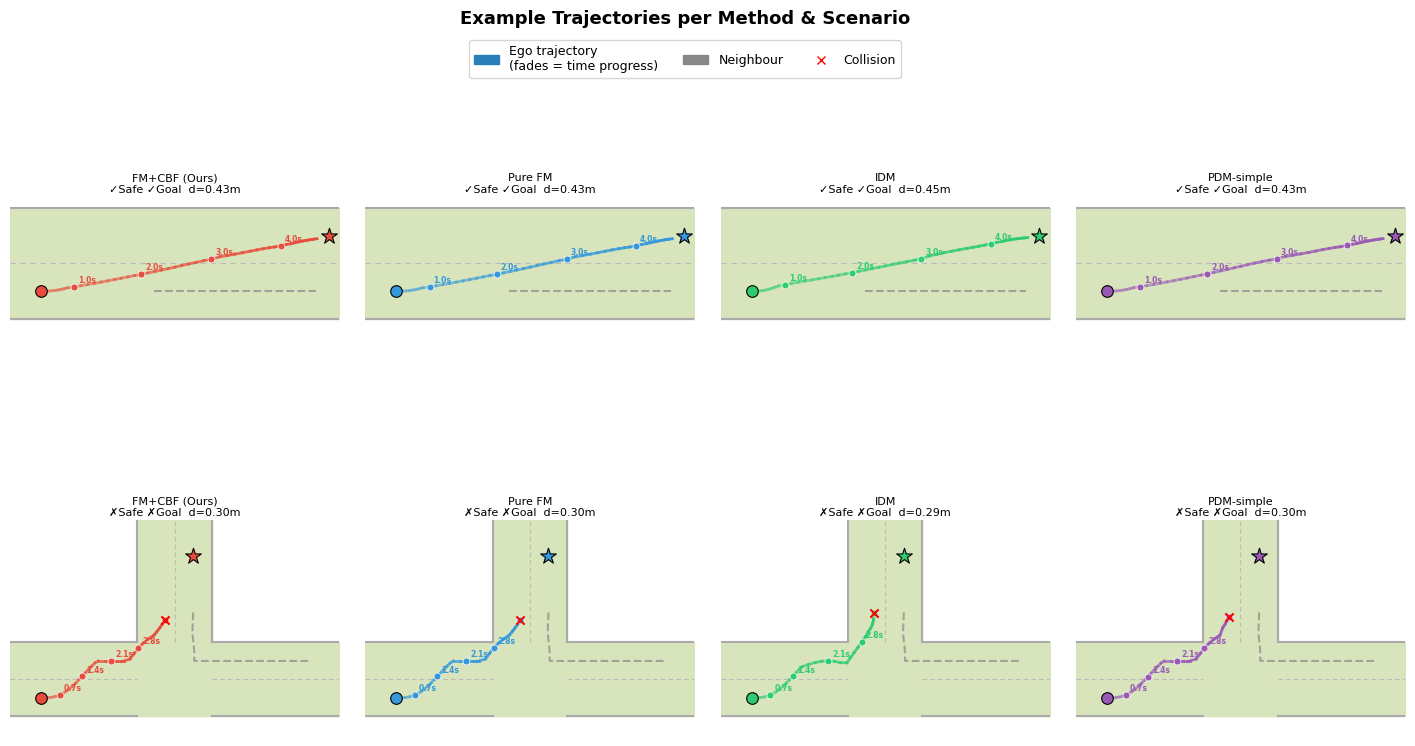

[saved] benchmark_trajectories.png


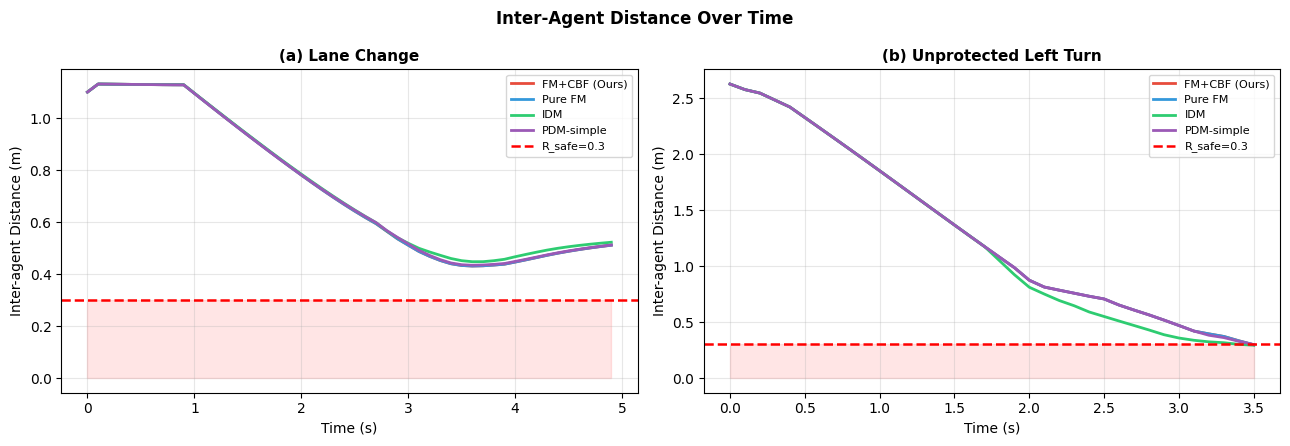

[saved] benchmark_distance.png


C:\Users\ROG\AppData\Local\Temp\ipykernel_27116\2586610345.py:725: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


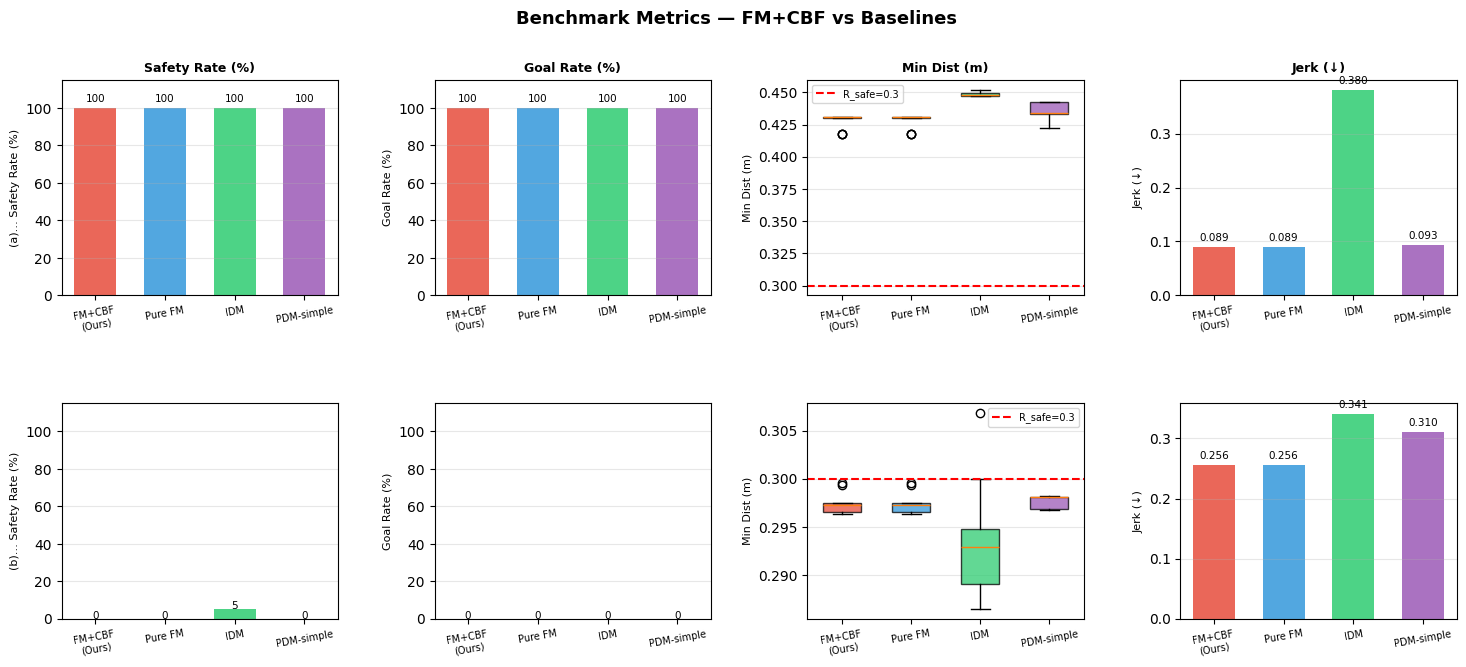

[saved] benchmark_metrics.png

All done! Outputs:
  benchmark_trajectories.png
  benchmark_distance.png
  benchmark_metrics.png


In [6]:
# ============================================================
# benchmark_v1.py
# 对比：FM+CBF | Pure FM | IDM | PDM-simple
# 场景：Lane Change + Unprotected Left Turn
# 道路：v7b 风格（绿色车道 + 灰边线 + 虚线）
# 执行：LQR tracker + kinematic bicycle（与 nuPlan 一致）
# 前提：model_5ch 已在内存
# ============================================================

from __future__ import annotations
import math, sys, time
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import KDTree
from scipy.ndimage import gaussian_filter1d
import torch

# ── sampler ───────────────────────────────────────────────────────────────────
try:
    from dmpc_fm_cbf.sampler_5h import piecewise_sample_fm_5ch_with_cbf
except ImportError:
    import importlib.util
    def _find(name):
        for p in sorted(Path.cwd().rglob(name), key=lambda x: len(str(x))):
            return p
        raise FileNotFoundError(name)
    _sp = _find("sampler_5h.py")
    _spec = importlib.util.spec_from_file_location("sampler_5h", _sp)
    _mod  = importlib.util.module_from_spec(_spec)
    sys.modules["sampler_5h"] = _mod
    _spec.loader.exec_module(_mod)
    piecewise_sample_fm_5ch_with_cbf = _mod.piecewise_sample_fm_5ch_with_cbf

# ── model ─────────────────────────────────────────────────────────────────────
import __main__ as _main
model_5ch = getattr(_main,"model_vel",None) or getattr(_main,"model_5ch",None)
assert model_5ch is not None, "model_5ch not found in namespace"
device = next(model_5ch.parameters()).device
model_5ch.eval()
torch.set_grad_enabled(False)
print(f"[OK] model on {device}")

# ============================================================
# 1. Config
# ============================================================
DT          = 0.10
GOAL_TOL    = 0.12
R_SAFE      = 0.30
MAX_STEPS   = 400
N_TRIALS    = 20
K_FM        = 6
T_STEPS     = 40

# Bicycle params
WB          = 0.30
A_MAX       = 1.5
D_MAX       = np.deg2rad(35.)
DR_MAX      = np.deg2rad(90.)
V_FLOOR     = 0.05

# Road geometry (from v7b)
LANE_HW     = 0.18
ROAD_HW     = 0.36
LANE_HW_LC  = 0.27
ROAD_HW_LC  = 0.54

# ============================================================
# 2. Dynamics
# ============================================================
def wrap_pi(th): return float((th+math.pi)%(2*math.pi)-math.pi)

def bicycle_step(s, u, v_max):
    x,y,th,v,delta = s
    a  = float(np.clip(u[0],-A_MAX,A_MAX))
    dr = float(np.clip(u[1],-DR_MAX,DR_MAX))
    v2 = float(np.clip(v+DT*a,0.,v_max))
    if v2<V_FLOOR and a>0.02: v2=V_FLOOR
    d2 = float(np.clip(delta+DT*dr,-D_MAX,D_MAX))
    th2= wrap_pi(th+DT*(v2/WB)*math.tan(d2))
    return np.array([x+DT*v2*math.cos(th2),
                     y+DT*v2*math.sin(th2),
                     th2,v2,d2],np.float32)

def rollout(s0,U,v_max):
    st=np.zeros((len(U)+1,5),np.float32); st[0]=s0
    for i,u in enumerate(U): st[i+1]=bicycle_step(st[i],u,v_max)
    return st

# ============================================================
# 3. LQR tracker  (nuPlan-style two-stage pipeline)
# ============================================================
_Q = np.diag([10.,10.,1.]).astype(np.float64)
_R = np.diag([1.,1.]).astype(np.float64)

def _dare(A,B,Q,R,n=200):
    P=Q.copy()
    for _ in range(n):
        Pn=(A.T@P@A - A.T@P@B@np.linalg.inv(R+B.T@P@B)@B.T@P@A + Q)
        if np.max(np.abs(Pn-P))<1e-8: break
        P=Pn
    return P

def _lqr_gain(v_ref):
    v=max(v_ref,0.1)
    Ac=np.array([[0,v,0],[0,0,0],[0,0,0]],np.float64)
    Bc=np.array([[0,0],[0,v/WB],[1,0]],np.float64)
    Ad=np.eye(3)+DT*Ac; Bd=DT*Bc
    P=_dare(Ad,Bd,_Q,_R)
    return np.linalg.inv(_R+Bd.T@P@Bd)@Bd.T@P@Ad  # (2,3)

_LQR = {v:_lqr_gain(v) for v in [0.1,0.3,0.5,0.7,1.0]}
def _get_K(v):
    ks=sorted(_LQR); return _LQR[ks[int(np.argmin([abs(v-k) for k in ks]))]]

def lqr_control(state, ref_path, goal_xy, v_max):
    x,y,th,v,delta=state
    pos=np.array([x,y],np.float32)
    goal=np.asarray(goal_xy,np.float32)
    d_goal=float(np.linalg.norm(pos-goal))

    # lookahead
    Ld=float(np.clip(0.4+0.5*v,0.2,0.9)); Ld=min(Ld,d_goal*0.9)
    dists=np.linalg.norm(ref_path-pos,axis=1); near=int(np.argmin(dists))
    target=ref_path[-1]
    for i in range(near,len(ref_path)):
        if np.linalg.norm(ref_path[i]-pos)>=Ld: target=ref_path[i]; break

    # reference speed
    if d_goal<0.4: v_ref=0.
    elif d_goal<0.9: v_ref=v_max*(d_goal/0.9)*0.5
    else: v_ref=v_max

    # errors
    dx,dy=float(target[0]-x),float(target[1]-y)
    th_ref=math.atan2(dy,dx); e_heading=wrap_pi(th_ref-th)
    if len(ref_path)>1:
        seg=ref_path[min(near+1,len(ref_path)-1)]-ref_path[near]
        sl=float(np.linalg.norm(seg)+1e-9)
        n_hat=np.array([-seg[1],seg[0]],np.float32)/sl
        e_lat=float(np.dot(pos-ref_path[near],n_hat))
    else: e_lat=0.
    e_v=v_ref-v
    err=np.array([e_lat,e_heading,e_v],np.float64)

    K=_get_K(max(v,0.1)); u=K@err
    dist_t=max(1e-3,float(np.linalg.norm(target-pos)))
    kappa=2.*math.sin(e_heading)/dist_t
    d_ref=float(np.clip(math.atan(WB*kappa),-D_MAX,D_MAX))
    dr_ref=float(np.clip((d_ref-delta)/DT,-DR_MAX,DR_MAX))

    a_out =float(np.clip(u[0],-A_MAX,A_MAX))
    dr_out=float(np.clip(u[1]+0.5*dr_ref,-DR_MAX,DR_MAX))
    return np.array([a_out,dr_out],np.float32)

# ============================================================
# 4. Road geometry  (from v7b)
# ============================================================
def _cosine_interp(y0,y1,n):
    t=(1-np.cos(np.linspace(0,math.pi,n)))/2
    return y0+(y1-y0)*t

def _arc_pts(cx,cy,r,th0,th1,n=25):
    th=np.linspace(th0,th1,n)
    return cx+r*np.cos(th),cy+r*np.sin(th)

def _lane_change_cls():
    x0,x1=0.20,1.10
    xs1=np.linspace(-1.40,x0,50); ys1=np.full(50,-LANE_HW_LC)
    xs2=np.linspace(x0,x1,40);   ys2=_cosine_interp(-LANE_HW_LC,+LANE_HW_LC,40)
    xs3=np.linspace(x1,1.60,15); ys3=np.full(15,+LANE_HW_LC)
    ego_cl=np.column_stack([np.concatenate([xs1,xs2,xs3]),
                             np.concatenate([ys1,ys2,ys3])]).astype(np.float32)
    nbr_cl=np.column_stack([np.linspace(-0.30,1.60,60),
                             np.full(60,-LANE_HW_LC)]).astype(np.float32)
    return ego_cl,nbr_cl

def _left_turn_cls():
    hw=LANE_HW
    xs_h=np.linspace(-1.40,-hw,40); ys_h=np.full(40,-hw)
    xs_a,ys_a=_arc_pts(hw,-hw,2*hw,math.pi,math.pi/2,n=35)
    ys_n=np.linspace(hw,1.40,35);   xs_n=np.full(35,hw)
    ego_cl=np.column_stack([np.concatenate([xs_h,xs_a,xs_n]),
                             np.concatenate([ys_h,ys_a,ys_n])]).astype(np.float32)
    xs_hn=np.linspace(1.40,hw,40);  ys_hn=np.full(40,hw)
    n_arc=25; xs_an=np.full(n_arc,hw)
    ys_an=hw+hw*(1-np.cos(np.linspace(0,math.pi/2,n_arc)))
    ys_nn=np.linspace(float(ys_an[-1]),1.40,30); xs_nn=np.full(30,hw)
    nbr_cl=np.column_stack([np.concatenate([xs_hn,xs_an,xs_nn]),
                             np.concatenate([ys_hn,ys_an,ys_nn])]).astype(np.float32)
    return ego_cl,nbr_cl

def _scenario_cfg(sc):
    if sc=="lane_change":
        ego_cl,nbr_cl=_lane_change_cls()
        sA0=np.array([-1.30,-LANE_HW_LC,0.,0.,0.],np.float32)
        sB0=np.array([-0.20,-LANE_HW_LC,0.,0.,0.],np.float32)
        gA=np.array([1.50,LANE_HW_LC],np.float32)
        gB=np.array([1.60,-LANE_HW_LC],np.float32)
        vA,vB=0.80,0.30
    else:
        ego_cl,nbr_cl=_left_turn_cls()
        sA0=np.array([-1.30,-LANE_HW,0.,0.,0.],np.float32)
        sB0=np.array([1.30,LANE_HW,math.pi,0.,0.],np.float32)
        gA=np.array([LANE_HW,1.20],np.float32)
        gB=np.array([LANE_HW,0.80],np.float32)
        vA,vB=0.65,0.50
    return ego_cl,nbr_cl,sA0,sB0,gA,gB,vA,vB

# ============================================================
# 5. Corridor utilities  (from v7b)
# ============================================================
def _cl_arclen(cl):
    s=np.linalg.norm(np.diff(cl,axis=0),axis=1)
    return np.concatenate([[0.],np.cumsum(s)]).astype(np.float32)

def _project_xy(xy,cl,hw):
    kdt=KDTree(cl); _,i=kdt.query(xy)
    i0=max(i-1,0); i1=min(i+1,len(cl)-1)
    tang=cl[i1]-cl[i0]; tl=float(np.linalg.norm(tang)+1e-9)
    t_hat=(tang/tl).astype(np.float32)
    n_hat=np.array([-t_hat[1],t_hat[0]],np.float32)
    lat=float(np.clip(np.dot(xy-cl[i],n_hat),-hw,hw))
    return (cl[i]+lat*n_hat).astype(np.float32)

def _correct_heading(s,cl):
    kdt=KDTree(cl); _,ni=kdt.query(s[:2])
    tang=cl[min(ni+1,len(cl)-1)]-cl[max(ni-1,0)]
    ta=math.atan2(tang[1],tang[0])
    if abs(wrap_pi(float(s[2])-ta))>math.radians(70):
        s=s.copy(); s[2]=ta
    return s

def reparametrize(xy,cl,hw=None,sigma=2.5):
    if hw is None: hw=ROAD_HW
    T=len(xy); arc=_cl_arclen(cl); kdt=KDTree(cl)
    _,i0=kdt.query(xy[0]); s_start=float(arc[i0])
    s_v=np.zeros(T,np.float32); lat_r=np.zeros(T,np.float32)
    for k in range(T):
        _,i=kdt.query(xy[k])
        i0_=max(i-1,0); i1_=min(i+1,len(cl)-1)
        tang=cl[i1_]-cl[i0_]; tl=float(np.linalg.norm(tang)+1e-9)
        t_hat=(tang/tl).astype(np.float32)
        n_hat=np.array([-t_hat[1],t_hat[0]],np.float32)
        d=xy[k]-cl[i]
        s_v[k]=float(arc[i])+float(np.dot(d,t_hat))
        lat_r[k]=float(np.dot(d,n_hat))
    s_v[0]=s_start
    for k in range(1,T): s_v[k]=max(s_v[k],s_v[k-1]+1e-4)
    s_v=np.clip(s_v,0.,float(arc[-1]))
    lat_sm=gaussian_filter1d(lat_r.astype(float),sigma=sigma)
    lat_sm[0]=lat_r[0]; lat_cl=np.clip(lat_sm,-hw,hw).astype(np.float32)
    out=np.zeros((T,2),np.float32)
    for k in range(T):
        sq=float(np.clip(s_v[k],0.,arc[-1]))
        i=int(np.clip(int(np.searchsorted(arc,sq,"right"))-1,0,len(cl)-2))
        fr=(sq-arc[i])/max(arc[min(i+1,len(arc)-1)]-arc[i],1e-9)
        base=cl[i]+fr*(cl[min(i+1,len(cl)-1)]-cl[i])
        tang=cl[min(i+1,len(cl)-1)]-cl[max(i-1,0)]
        tl=float(np.linalg.norm(tang)+1e-9)
        t_hat=(tang/tl).astype(np.float32)
        n_hat=np.array([-t_hat[1],t_hat[0]],np.float32)
        out[k]=base+lat_cl[k]*n_hat
    xs=gaussian_filter1d(out[:,0].astype(float),sigma=max(sigma*0.4,1.))
    ys=gaussian_filter1d(out[:,1].astype(float),sigma=max(sigma*0.4,1.))
    xs[0]=out[0,0]; ys[0]=out[0,1]
    out[:,0]=xs.astype(np.float32); out[:,1]=ys.astype(np.float32)
    return out

def _nbr_rollout(sB0,gB,nbr_cl,n_steps,vB):
    """Neighbour follows its corridor at constant speed."""
    states=[sB0.copy()]; s=sB0.copy()
    kdt=KDTree(nbr_cl)
    for _ in range(n_steps):
        pos=s[:2]; th=float(s[2]); v=float(s[3]); d=float(s[4])
        d_g=float(np.linalg.norm(pos-gB))
        if d_g<GOAL_TOL: states.append(s.copy()); continue
        ld=max(0.10,v*DT*1.5); _,ni=kdt.query(pos)
        li=ni
        for j in range(ni,len(nbr_cl)):
            if np.linalg.norm(nbr_cl[j]-pos)>=ld: li=j; break
        tgt=nbr_cl[min(li,len(nbr_cl)-1)]
        ang=math.atan2(tgt[1]-pos[1],tgt[0]-pos[0])
        alpha=wrap_pi(ang-th)
        dt_=max(1e-3,float(np.linalg.norm(tgt-pos)))
        kappa=2.*math.sin(alpha)/dt_
        dd=float(np.clip(math.atan(WB*kappa),-D_MAX,D_MAX))
        dr=float(np.clip(4.*(dd-d),-DR_MAX,DR_MAX))
        v_des=vB*float(np.clip(d_g/0.5,0.4,1.0))
        a=float(np.clip(5.*(v_des-v),-A_MAX,A_MAX))
        s=bicycle_step(s,np.array([a,dr],np.float32),vB)
        xy_p=_project_xy(s[:2],nbr_cl,LANE_HW if "left" in "" else LANE_HW_LC)
        s[0],s[1]=float(xy_p[0]),float(xy_p[1])
        s=_correct_heading(s,nbr_cl)
        states.append(s.copy())
    return np.array(states,np.float32)

def _predict_nbr(nbr_states,nbr_cl,n=50):
    if len(nbr_states)==0: return np.zeros((0,2),np.float32)
    last=nbr_states[-1]; v=max(float(last[3]),0.10)
    kdt=KDTree(nbr_cl); _,i0=kdt.query(last[:2])
    fut=[]; pos=last[:2].copy(); ci=i0
    for _ in range(n):
        step=v*DT; walked=0.
        while walked<step and ci<len(nbr_cl)-1:
            seg=nbr_cl[ci+1]-nbr_cl[ci]; sl=float(np.linalg.norm(seg)+1e-9)
            if walked+sl<=step: walked+=sl; ci+=1; pos=nbr_cl[ci].copy()
            else: pos=nbr_cl[ci]+((step-walked)/sl)*seg; walked=step
        fut.append(pos.copy())
    return np.array(fut,np.float32)

# ============================================================
# 6. Canonical frame + FM sampling
# ============================================================
def _tf(start,goal):
    s=np.asarray(start,np.float32); g=np.asarray(goal,np.float32)
    d=g-s; dist=float(np.linalg.norm(d)+1e-9)
    c,sv=d[0]/dist,d[1]/dist
    R=np.array([[c,sv],[-sv,c]],np.float32)
    ga=math.atan2(float(sv),float(c))
    def w2c(xy): return (np.asarray(xy,np.float32).reshape(-1,2)-s)@R.T
    def c2w(xy): return np.asarray(xy,np.float32).reshape(-1,2)@R+s
    return dict(w2c=w2c,c2w=c2w,
                w2c_angle=lambda th_w:wrap_pi(th_w-ga),
                start_can=np.zeros(2,np.float32),
                goal_can=np.array([dist,0.],np.float32),dist=dist)

CBF_KW=dict(passes=6,extra_margin=0.20,alpha=20.,max_corr_norm=3.)

def _sample_fm(sA,gA,nbr_states,nbr_cl,seed,use_cbf):
    tf=_tf(sA[:2],gA)
    th_can=tf["w2c_angle"](float(sA[2]))
    cond=np.array([tf["dist"],float(sA[3]),
                   math.cos(th_can),math.sin(th_can),
                   float(sA[4])],np.float32)
    ellipses=[]
    if use_cbf:
        fut=_predict_nbr(nbr_states,nbr_cl,60)
        if len(fut)>0:
            idxs=np.linspace(0,len(fut)-1,min(10,len(fut))).astype(int)
            ellipses=[{"center":tf["w2c"](fut[i:i+1])[0].copy(),"radius":0.40}
                      for i in idxs]
    g=torch.Generator(device=device).manual_seed(int(seed))
    x0=torch.randn((1,5,T_STEPS),device=device,generator=g)*0.08
    x0[:,:,0]=0.
    x_fm,_,_=piecewise_sample_fm_5ch_with_cbf(
        model_5ch=model_5ch,T_steps=T_STEPS,device=str(device),
        total_time=1.,num_segments=5,ode_method="euler",
        atol=1e-4,rtol=1e-4,noise_scale=0.08,x0_noise=x0,cond=cond,
        start_xy_norm=tf["start_can"],goal_xy_norm=tf["goal_can"],
        start_guidance_weight=0.55,goal_guidance_weight=0.95,
        goal_guidance_mode="tail",lock_start=True,
        use_cbf=bool(use_cbf and len(ellipses)>0),scaler=None,
        ellipses=ellipses,cbf_kwargs=CBF_KW if ellipses else None,
    )
    return tf["c2w"](x_fm[0:2,:].T.astype(np.float32))

def _fm_plan(sA,gA,nbr_states,nbr_cl,ego_cl,seed,use_cbf,road_hw):
    nbr=_predict_nbr(nbr_states,nbr_cl)
    best=None; best_cost=float("inf")
    for k in range(K_FM):
        try:
            path=_sample_fm(sA,gA,nbr_states,nbr_cl,int(seed+137*k+7919),use_cbf)
            path=reparametrize(path,ego_cl,road_hw)
        except Exception: continue
        d_end=float(np.linalg.norm(path[-1]-np.asarray(gA,np.float32)))
        d_mean=float(np.mean(np.linalg.norm(path-np.asarray(gA,np.float32),axis=1)))
        coll=0.
        if len(nbr)>0:
            M=min(len(path),len(nbr))
            viol=max(0.,R_SAFE-float(np.linalg.norm(path[:M]-nbr[:M],axis=1).min()))
            coll=viol**2*450.
        cost=18.*d_end+1.5*d_mean+coll
        if cost<best_cost: best_cost=cost; best=path
    if best is None:
        best=reparametrize(np.linspace(sA[:2],gA,T_STEPS).astype(np.float32),
                           ego_cl,road_hw)
    return best

# ============================================================
# 7. IDM planner
# ============================================================
IDM_V0=1.0; IDM_T=1.5; IDM_A=1.0; IDM_B=1.5; IDM_S0=0.3

def _idm_a(v,v_lead,gap):
    s_star=IDM_S0+max(0.,v*IDM_T+v*(v-v_lead)/(2.*math.sqrt(IDM_A*IDM_B)+1e-6))
    return float(np.clip(IDM_A*(1.-(v/max(IDM_V0,1e-3))**4-(s_star/max(gap,1e-3))**2),-IDM_B*2,IDM_A))

def _idm_plan(sA,gA,nbr_states,ego_cl,road_hw,v_max,n=T_STEPS):
    pos=sA[:2].copy(); ang=float(math.atan2(gA[1]-pos[1],gA[0]-pos[0]))
    cur_v=float(sA[3])
    gap=999.; v_lead=IDM_V0
    if len(nbr_states)>0:
        o_pos=nbr_states[-1,:2]; rel=o_pos-pos
        ahead=float(np.dot(rel,[math.cos(ang),math.sin(ang)]))
        if ahead>0:
            gap=max(0.,float(np.linalg.norm(rel))-R_SAFE*2)
            v_lead=float(nbr_states[-1,3])
    path=[]
    cur=pos.copy()
    for _ in range(n):
        a=_idm_a(cur_v,v_lead,gap)
        cur_v=float(np.clip(cur_v+DT*a,0.,v_max))
        cur=cur+DT*cur_v*np.array([math.cos(ang),math.sin(ang)],np.float32)
        path.append(cur.copy())
        gap=max(0.,gap-DT*cur_v)
    path=np.array(path,np.float32)
    return reparametrize(path,ego_cl,road_hw,sigma=1.5)

# ============================================================
# 8. PDM-simple planner
# ============================================================
def _pdm_plan(sA,gA,nbr_states,ego_cl,road_hw,v_max,n=T_STEPS):
    pos=sA[:2].copy()
    ang=float(math.atan2(gA[1]-pos[1],gA[0]-pos[0]))
    path=[]
    cur=pos.copy()
    for _ in range(n):
        v_des=v_max
        if len(nbr_states)>0:
            d_obs=float(np.linalg.norm(cur-nbr_states[-1,:2]))
            if d_obs<1.5:
                v_des=v_max*max(0.,(d_obs-R_SAFE)/(1.5-R_SAFE))
        d_g=float(np.linalg.norm(cur-np.asarray(gA,np.float32)))
        if d_g<0.8: v_des=min(v_des,v_max*d_g/0.8)
        cur=cur+DT*v_des*np.array([math.cos(ang),math.sin(ang)],np.float32)
        path.append(cur.copy())
    path=np.array(path,np.float32)
    return reparametrize(path,ego_cl,road_hw,sigma=1.5)

# ============================================================
# 9. Simulation runner
# ============================================================
METHODS={"FM+CBF\n(Ours)":"fm_cbf","Pure FM":"pure_fm",
         "IDM":"idm","PDM-simple":"pdm"}
METHOD_COLORS={"FM+CBF\n(Ours)":"#e74c3c","Pure FM":"#3498db",
               "IDM":"#2ecc71","PDM-simple":"#9b59b6"}

def run_trial(sc,method_key,seed,return_traj=False):
    ego_cl,nbr_cl,sA0,sB0,gA,gB,vA,vB=_scenario_cfg(sc)
    road_hw=ROAD_HW_LC if sc=="lane_change" else ROAD_HW

    rng=np.random.default_rng(seed)
    sA=sA0.copy(); sA[3]=float(rng.uniform(0.,0.08))
    sB=sB0.copy(); sB[3]=float(rng.uniform(0.,0.08))

    # pre-compute neighbour full trajectory
    nbr_full=_nbr_rollout(sB,gB,nbr_cl,MAX_STEPS,vB)

    traj_A=[sA[:2].copy()]; traj_B=[sB[:2].copy()]
    U_log=[]; path_cache=None
    t0=time.time()

    for step in range(MAX_STEPS):
        dA=float(np.linalg.norm(sA[:2]-gA))
        if dA<GOAL_TOL: break

        nbr_step=min(step,len(nbr_full)-1)
        nbr_hist=nbr_full[:nbr_step+1]

        # ── plan ──────────────────────────────────────────────
        try:
            if method_key=="fm_cbf":
                path_cache=_fm_plan(sA,gA,nbr_hist,nbr_cl,ego_cl,
                                    1000+step*31+seed,True,road_hw)
            elif method_key=="pure_fm":
                path_cache=_fm_plan(sA,gA,nbr_hist,nbr_cl,ego_cl,
                                    1000+step*31+seed,False,road_hw)
            elif method_key=="idm":
                path_cache=_idm_plan(sA,gA,nbr_hist,ego_cl,road_hw,vA)
            elif method_key=="pdm":
                path_cache=_pdm_plan(sA,gA,nbr_hist,ego_cl,road_hw,vA)
        except Exception as e:
            pass  # keep old path_cache

        # ── LQR → bicycle_step ────────────────────────────────
        if path_cache is not None and len(path_cache)>1:
            u=lqr_control(sA,path_cache,gA,vA)
        else:
            u=np.zeros(2,np.float32)
        U_log.append(u.copy())

        sA=bicycle_step(sA,u,vA)
        xy_p=_project_xy(sA[:2],ego_cl,road_hw)
        sA[0],sA[1]=float(xy_p[0]),float(xy_p[1])
        sA=_correct_heading(sA,ego_cl)

        # neighbour step
        sB_now=nbr_full[min(step+1,len(nbr_full)-1)]
        traj_A.append(sA[:2].copy())
        traj_B.append(sB_now[:2].copy())

        if float(np.linalg.norm(sA[:2]-nbr_full[min(step,len(nbr_full)-1),:2]))<R_SAFE:
            break  # collision

    elapsed=time.time()-t0
    trajA=np.array(traj_A,np.float32)
    trajB=np.array(traj_B,np.float32)
    dist_AB=np.linalg.norm(trajA-trajB[:len(trajA)],axis=1)
    success=bool(np.linalg.norm(trajA[-1]-gA)<GOAL_TOL)
    collision=bool(dist_AB.min()<R_SAFE)
    min_d=float(dist_AB.min())
    U_arr=np.array(U_log,np.float32) if U_log else np.zeros((1,2),np.float32)
    jerk=float(np.mean(np.linalg.norm(np.diff(U_arr,axis=0),axis=1))) if len(U_arr)>1 else 0.

    res=dict(success=success,collision=collision,min_dist=min_d,
             time=elapsed,jerk=jerk,steps=len(trajA))
    if return_traj:
        res.update(trajA=trajA,trajB=trajB,dist_AB=dist_AB,
                   gA=gA,gB=gB,sA0=sA0,sB0=sB0,
                   ego_cl=ego_cl,nbr_cl=nbr_cl,sc=sc)
    return res

# ============================================================
# 10. Run all experiments
# ============================================================
SCENARIOS=["lane_change","left_turn"]
SC_LABELS={"lane_change":"(a) Lane Change",
           "left_turn":"(b) Unprotected Left Turn"}
M_KEYS=list(METHODS.keys())

print("="*65+"\nRunning benchmark...\n"+"="*65)
results=defaultdict(list)
examples={}

for sc in SCENARIOS:
    for name,key in METHODS.items():
        label=name.replace("\n"," ")
        print(f"  [{label:<15}] {SC_LABELS[sc]}",end=" ",flush=True)
        for trial in range(N_TRIALS):
            ret=(trial==0)
            r=run_trial(sc,key,seed=1000+trial*97,return_traj=ret)
            results[(name,sc)].append(r)
            if ret: examples[(name,sc)]=r
            if (trial+1)%5==0: print(".",end="",flush=True)
        n=len(results[(name,sc)])
        cr=np.mean([r["collision"] for r in results[(name,sc)]])
        gr=np.mean([r["success"]   for r in results[(name,sc)]])
        print(f"  coll={cr:.0%} goal={gr:.0%}")

# ============================================================
# 11. Print metrics table
# ============================================================
print("\n"+"="*78)
print(f"{'Method':<16}{'Scenario':<28}{'Safety%':>8}{'Goal%':>8}"
      f"{'MinDist':>9}{'Jerk':>8}{'Steps':>7}")
print("-"*78)
for sc in SCENARIOS:
    for name in M_KEYS:
        rs=results[(name,sc)]; n=len(rs)
        label=name.replace("\n"," ")
        print(f"  {label:<14} {SC_LABELS[sc]:<26} "
              f"{sum(1 for r in rs if not r['collision'])/n*100:>7.1f}% "
              f"{sum(1 for r in rs if r['success'])/n*100:>7.1f}% "
              f"{np.mean([r['min_dist'] for r in rs]):>8.3f} "
              f"{np.mean([r['jerk']     for r in rs]):>7.4f} "
              f"{np.mean([r['steps']    for r in rs]):>6.1f}")
    print()

# ============================================================
# 12. Figure 1 — Trajectory plots  (v7b road style)
# ============================================================
CLANE="#d8e4bc"; CROAD="#aaaaaa"; CDASH="#bbbbbb"

def _draw_road(ax,sc):
    hw=ROAD_HW_LC if sc=="lane_change" else ROAD_HW
    if sc=="lane_change":
        ax.fill_between([-1.6,1.6],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        for y in [-hw,hw]: ax.plot([-1.6,1.6],[y,y],color=CROAD,lw=1.5,zorder=1)
        ax.plot([-1.6,1.6],[0,0],color=CDASH,lw=0.8,ls="--",dashes=(5,4),zorder=1)
        ax.set_xlim(-1.6,1.6); ax.set_ylim(-0.65,0.65)
    else:
        ax.fill_between([-1.6,1.6],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        ax.fill_betweenx([-hw,1.55],[-hw,-hw],[hw,hw],color=CLANE,zorder=0)
        for y in [-hw,hw]:
            ax.plot([-1.6,-hw],[y,y],color=CROAD,lw=1.5,zorder=2)
            ax.plot([hw,1.6],[y,y],color=CROAD,lw=1.5,zorder=2)
        for x in [-hw,hw]: ax.plot([x,x],[hw,1.55],color=CROAD,lw=1.5,zorder=2)
        ax.plot([-1.6,-hw],[0,0],color=CDASH,lw=0.8,ls="--",dashes=(4,3),zorder=2)
        ax.plot([hw,1.6],[0,0],color=CDASH,lw=0.8,ls="--",dashes=(4,3),zorder=2)
        ax.plot([0,0],[hw,1.55],color=CDASH,lw=0.8,ls="--",dashes=(4,3),zorder=2)
        ax.set_xlim(-1.6,1.6); ax.set_ylim(-0.55,1.55)
    ax.set_aspect("equal"); ax.axis("off")

fig1,axes1=plt.subplots(2,4,figsize=(18,8),
                         gridspec_kw=dict(hspace=0.45,wspace=0.08))
for row,sc in enumerate(SCENARIOS):
    for col,name in enumerate(M_KEYS):
        ax=axes1[row,col]; _draw_road(ax,sc)
        if (name,sc) not in examples: continue
        data=examples[(name,sc)]
        trajA=data["trajA"]; trajB=data["trajB"]
        color=METHOD_COLORS[name]

        # ── time-colored trajectory ───────────────────────────
        T=len(trajA)
        for i in range(T-1):
            alpha=0.4+0.6*(i/(T-1))
            ax.plot(trajA[i:i+2,0],trajA[i:i+2,1],
                    color=color,lw=2.0,alpha=alpha,zorder=3)

        ax.plot(trajB[:,0],trajB[:,1],color="#888888",lw=1.5,
                alpha=0.7,ls="--",zorder=2,label="Neighbour")

        # time markers every 10 steps
        for ti in range(0,T,max(1,T//5)):
            t_sec=ti*DT
            ax.scatter(trajA[ti,0],trajA[ti,1],
                       s=25,color=color,zorder=5,
                       edgecolors="white",linewidths=0.5)
            if ti>0 and ti<T-5:
                ax.text(trajA[ti,0]+0.04,trajA[ti,1]+0.04,
                        f"{t_sec:.1f}s",fontsize=5.5,color=color,
                        zorder=6,fontweight="bold")

        # collision markers
        coll_idx=np.where(data["dist_AB"]<R_SAFE)[0]
        if len(coll_idx):
            ax.scatter(trajA[coll_idx,0],trajA[coll_idx,1],
                       c="red",s=35,marker="x",zorder=6)

        ax.scatter(*data["sA0"][:2],c=color,s=70,marker="o",
                   zorder=5,edgecolors="k",lw=0.8)
        ax.scatter(*data["gA"],c=color,s=140,marker="*",
                   zorder=5,edgecolors="k",lw=0.8)

        safe_sym="✓" if not data["collision"] else "✗"
        goal_sym="✓" if data["success"] else "✗"
        ax.set_title(f"{name.replace(chr(10),' ')}\n"
                     f"{safe_sym}Safe {goal_sym}Goal  d={data['min_dist']:.2f}m",
                     fontsize=8,pad=3)

    axes1[row,0].set_ylabel(SC_LABELS[sc],fontsize=9,labelpad=4)

fig1.legend(handles=[
    mpatches.Patch(color="#2980b9",label="Ego trajectory\n(fades = time progress)"),
    mpatches.Patch(color="#888888",label="Neighbour"),
    plt.Line2D([],[],color="red",marker="x",ls="",label="Collision"),
],loc="upper center",ncol=3,bbox_to_anchor=(0.5,1.01),fontsize=9)
plt.suptitle("Example Trajectories per Method & Scenario",
             fontsize=13,fontweight="bold",y=1.04)
plt.savefig("benchmark_trajectories.png",dpi=150,bbox_inches="tight")
plt.show(); print("[saved] benchmark_trajectories.png")

# ============================================================
# 13. Figure 2 — Distance over time
# ============================================================
fig2,axes2=plt.subplots(1,2,figsize=(13,4.5))
for col,sc in enumerate(SCENARIOS):
    ax=axes2[col]
    for name in M_KEYS:
        if (name,sc) not in examples: continue
        d_arr=examples[(name,sc)]["dist_AB"]
        t_arr=np.arange(len(d_arr))*DT
        ax.plot(t_arr,d_arr,lw=2,color=METHOD_COLORS[name],
                label=name.replace("\n"," "))
    if len(t_arr)>0:
        ax.axhline(R_SAFE,color="red",ls="--",lw=1.8,
                   label=f"R_safe={R_SAFE}")
        ax.fill_between([0,float(t_arr[-1])],0,R_SAFE,
                        alpha=0.10,color="red")
    ax.set_xlabel("Time (s)",fontsize=10)
    ax.set_ylabel("Inter-agent Distance (m)",fontsize=10)
    ax.set_title(SC_LABELS[sc],fontsize=11,fontweight="bold")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Inter-Agent Distance Over Time",
             fontsize=12,fontweight="bold")
plt.tight_layout()
plt.savefig("benchmark_distance.png",dpi=150,bbox_inches="tight")
plt.show(); print("[saved] benchmark_distance.png")

# ============================================================
# 14. Figure 3 — Metric bar charts
# ============================================================
fig3,axes3=plt.subplots(2,4,figsize=(18,7),
                         gridspec_kw=dict(hspace=0.5,wspace=0.35))
metric_keys  =["safety","goal","min_dist","jerk"]
metric_labels=["Safety Rate (%)","Goal Rate (%)","Min Dist (m)","Jerk (↓)"]

for row,sc in enumerate(SCENARIOS):
    summary={}
    for name in M_KEYS:
        rs=results[(name,sc)]; n=len(rs)
        summary[name]={
            "safety":  sum(1 for r in rs if not r["collision"])/n*100,
            "goal":    sum(1 for r in rs if r["success"])/n*100,
            "min_dist":np.mean([r["min_dist"] for r in rs]),
            "min_dist_all":[r["min_dist"] for r in rs],
            "jerk":    np.mean([r["jerk"] for r in rs]),
        }
    labels_s=[n.replace("\n","\n") for n in M_KEYS]
    colors=[METHOD_COLORS[n] for n in M_KEYS]

    for col,(mk,ml) in enumerate(zip(metric_keys,metric_labels)):
        ax=axes3[row,col]
        if mk=="min_dist":
            bp=ax.boxplot([summary[n]["min_dist_all"] for n in M_KEYS],
                          patch_artist=True,widths=0.55)
            for patch,c in zip(bp["boxes"],colors):
                patch.set_facecolor(c); patch.set_alpha(0.75)
            ax.axhline(R_SAFE,color="red",ls="--",lw=1.5,
                       label=f"R_safe={R_SAFE}")
            ax.legend(fontsize=7)
            ax.set_xticks(range(1,len(M_KEYS)+1))
            ax.set_xticklabels(labels_s,fontsize=7,rotation=10)
        else:
            vals=[summary[n][mk] for n in M_KEYS]
            bars=ax.bar(labels_s,vals,color=colors,width=0.6,alpha=0.85)
            if mk in("safety","goal"): ax.set_ylim(0,115)
            for bar,v in zip(bars,vals):
                fmt=f"{v:.0f}" if mk in("safety","goal") else f"{v:.3f}"
                ax.text(bar.get_x()+bar.get_width()/2,
                        v+max(vals)*0.03+1e-9,fmt,
                        ha="center",fontsize=7.5)
            ax.tick_params(axis="x",labelsize=7,rotation=10)
        if row==0: ax.set_title(ml,fontsize=9,fontweight="bold")
        ax.set_ylabel(f"{SC_LABELS[sc][:3]}… {ml}" if col==0 else ml,
                      fontsize=8)
        ax.grid(axis="y",alpha=0.3)

plt.suptitle("Benchmark Metrics — FM+CBF vs Baselines",
             fontsize=13,fontweight="bold")
plt.tight_layout()
plt.savefig("benchmark_metrics.png",dpi=150,bbox_inches="tight")
plt.show(); print("[saved] benchmark_metrics.png")

print("\nAll done! Outputs:")
print("  benchmark_trajectories.png")
print("  benchmark_distance.png")
print("  benchmark_metrics.png")